# **Multimodal Machine Learning with Brain, Image, and Text Data** (v2 — Clean Pipeline)

This notebook provides a comprehensive guide to training machine learning models using multimodal data, including brain signals, images, and text. You will explore various data processing techniques, model training using neural networks and traditional classifiers, and performance evaluation using metrics like accuracy, precision, and recall. The goal is to integrate diverse data sources to improve classification performance and gain deeper insights into complex datasets.

# **Install the package**

##**1. Install the data reading package**

**Library Installation**:

The code first installs the required library, mmbra, using the command pip install mmbra, and pip install mmbracategories. This step ensures that all the necessary dependencies for this specific library are available in the environment. The installation process is critical for using the functionalities provided by the mmbra package and mmbracategories package in subsequent steps.

**Library Import**:

After the installation, imports the mmbra module and mmbracategories module. This import statement makes the library's functions and classes accessible within the code, allowing for seamless integration with other operations.

In [ ]:
!pip install mmbra
!pip install mmbracategories
import mmbra
import mmbracategories


##**3. Dataset split settings**


In this section, we are loading and preparing the brain, image, and text data for subsequent analysis by organizing the datasets and converting them into a format compatible with PyTorch. Here's a step-by-step description of the key operations:

**Data Loading**:

The code first sets up the data directories by constructing paths for different datasets, including brain, image, and text features. It organizes these paths based on the subject identifier, data type (training or testing), and the model used (e.g., image and text models).
The datasets are loaded from .mat files using the scipy.io.loadmat() function. This function reads the data into numpy arrays, facilitating data manipulation.

**Data Preprocessing**:

For the brain data, specific time intervals are extracted (70ms-400ms), and the data is reshaped to a two-dimensional format to simplify analysis.
Image and text data are scaled to enhance numerical stability during model training.
Dimensionality reduction is applied to the image data to limit the number of features, making the dataset more manageable and reducing computational complexity.

**Conversion to PyTorch Tensors**:

The numpy arrays for each dataset (brain, image, text, and labels) are converted into PyTorch tensors. This conversion is crucial for efficient data handling in neural network training, as tensors are optimized for operations on GPU.

**Data Summary**:

The code prints the shape of each dataset, providing an overview of the number of samples and features for both training and testing sets. This summary helps confirm that the data is correctly formatted and that the expected number of features is present.
This process of data loading, preprocessing, and conversion into PyTorch tensors ensures that the brain, image, and text datasets are ready for further analysis or machine learning tasks.

In [ ]:
import torch
import os
import scipy.io as sio
from sklearn.model_selection import train_test_split
import numpy as np

# load data
data_dir_root = os.path.join('/content/drive/MyDrive/Colab-datasets/Generative-modelling-research-data', 'ThingsEEG-Text')
sbj = 'sub-10'
image_model = 'pytorch/cornet_s'
text_model = 'CLIPText'
roi = '17channels'
brain_dir = os.path.join(data_dir_root, 'brain_feature', roi, sbj)
image_dir_seen = os.path.join(data_dir_root, 'visual_feature/ThingsTrain', image_model, sbj)
image_dir_unseen = os.path.join(data_dir_root, 'visual_feature/ThingsTest', image_model, sbj)
text_dir_seen = os.path.join(data_dir_root, 'textual_feature/ThingsTrain/text', text_model, sbj)
text_dir_unseen = os.path.join(data_dir_root, 'textual_feature/ThingsTest/text', text_model, sbj)

brain_seen = sio.loadmat(os.path.join(brain_dir, 'eeg_train_data_within.mat'))['data'].astype('double') * 2.0
brain_seen = brain_seen[:,:,27:60] # 70ms-400ms
brain_seen = np.reshape(brain_seen, (brain_seen.shape[0], -1))
image_seen = sio.loadmat(os.path.join(image_dir_seen, 'feat_pca_train.mat'))['data'].astype('double')*50.0
text_seen = sio.loadmat(os.path.join(text_dir_seen, 'text_feat_train.mat'))['data'].astype('double')*2.0
label_seen = sio.loadmat(os.path.join(brain_dir, 'eeg_train_data_within.mat'))['class_idx'].T.astype('int')

brain_unseen = sio.loadmat(os.path.join(brain_dir, 'eeg_test_data.mat'))['data'].astype('double')*2.0
brain_unseen = brain_unseen[:, :, 27:60]
brain_unseen = np.reshape(brain_unseen, (brain_unseen.shape[0], -1))
image_unseen = sio.loadmat(os.path.join(image_dir_unseen, 'feat_pca_test.mat'))['data'].astype('double')*50.0
text_unseen = sio.loadmat(os.path.join(text_dir_unseen, 'text_feat_test.mat'))['data'].astype('double')*2.0
label_unseen = sio.loadmat(os.path.join(brain_dir, 'eeg_test_data.mat'))['class_idx'].T.astype('int')

# --- LABEL COLLISION FIX ---
# Raw unseen labels [1..200] collide with seen labels [1..1654].
# Offset so unseen occupy disjoint range [1655..1854].
_label_offset = int(label_seen.max())
label_unseen = label_unseen + _label_offset
print(f"Label fix: unseen labels offset by {_label_offset} -> [{label_unseen.min()}, {label_unseen.max()}]")


brain_seen = torch.from_numpy(brain_seen)
brain_unseen = torch.from_numpy(brain_unseen)
image_seen = torch.from_numpy(image_seen)
image_unseen = torch.from_numpy(image_unseen)
text_seen = torch.from_numpy(text_seen)
text_unseen = torch.from_numpy(text_unseen)
label_seen = torch.from_numpy(label_seen)
label_unseen = torch.from_numpy(label_unseen)

print('seen_brain_samples=', brain_seen.shape[0], ', seen_brain_features=', brain_seen.shape[1])
print('seen_image_samples=', image_seen.shape[0], ', seen_image_features=', image_seen.shape[1])
print('seen_text_samples=', text_seen.shape[0], ', seen_text_features=', text_seen.shape[1])
print('seen_label=', label_seen.shape)
print('unseen_brain_samples=', brain_unseen.shape[0], ', unseen_brain_features=', brain_unseen.shape[1])
print('unseen_image_samples=', image_unseen.shape[0], ', unseen_image_features=', image_unseen.shape[1])
print('unseen_text_samples=', text_unseen.shape[0], ', unseen_text_features=', text_unseen.shape[1])
print('unseen_label=', label_unseen.shape)

Label fix: unseen labels offset by 1654 -> [1655, 1854]
seen_brain_samples= 16540 , seen_brain_features= 561
seen_image_samples= 16540 , seen_image_features= 1000
seen_text_samples= 16540 , seen_text_features= 512
seen_label= torch.Size([16540, 1])
unseen_brain_samples= 16000 , unseen_brain_features= 561
unseen_image_samples= 16000 , unseen_image_features= 1000
unseen_text_samples= 16000 , unseen_text_features= 512
unseen_label= torch.Size([16000, 1])


In [ ]:
label_unseen

tensor([[1655],
        [1656],
        [1657],
        ...,
        [1852],
        [1853],
        [1854]])

---

# GZSL Pipeline: Baseline Model and Advanced Methods

The following sections implement:
1. **Baseline Model [A]**: Logistic Regression on raw EEG features
2. **Brain-Text CLIP Encoder** (future)
3. **cWGAN-GP for Embedding Synthesis** (future)
4. **GZSL Classifier [A+B]** (future)

---

## Data Structure Summary

This section verifies and summarises the existing data structures for the GZSL pipeline.

In [ ]:
# =============================================================================
# DATA STRUCTURE SUMMARY
# =============================================================================

import pandas as pd
import numpy as np

# Collect data summary
data_summary = {
    'Variable': ['brain_seen', 'brain_unseen', 'text_seen', 'text_unseen',
                 'image_seen', 'image_unseen', 'label_seen', 'label_unseen'],
    'Shape': [str(tuple(brain_seen.shape)), str(tuple(brain_unseen.shape)),
              str(tuple(text_seen.shape)), str(tuple(text_unseen.shape)),
              str(tuple(image_seen.shape)), str(tuple(image_unseen.shape)),
              str(tuple(label_seen.shape)), str(tuple(label_unseen.shape))],
    'Dtype': [str(brain_seen.dtype), str(brain_unseen.dtype),
              str(text_seen.dtype), str(text_unseen.dtype),
              str(image_seen.dtype), str(image_unseen.dtype),
              str(label_seen.dtype), str(label_unseen.dtype)]
}

df_summary = pd.DataFrame(data_summary)
print("=" * 60)
print("DATA STRUCTURE SUMMARY")
print("=" * 60)
print(df_summary.to_string(index=False))
print()

# Label statistics
unique_seen = torch.unique(label_seen)
unique_unseen = torch.unique(label_unseen)

print(f"Seen classes: {len(unique_seen)} unique labels (range: {unique_seen.min().item()} to {unique_seen.max().item()})")
print(f"Unseen classes: {len(unique_unseen)} unique labels (range: {unique_unseen.min().item()} to {unique_unseen.max().item()})")
print()
print(f"Samples per seen class (approx): {brain_seen.shape[0] / len(unique_seen):.1f}")
print(f"Samples per unseen class (approx): {brain_unseen.shape[0] / len(unique_unseen):.1f}")

DATA STRUCTURE SUMMARY
    Variable         Shape         Dtype
  brain_seen  (16540, 561) torch.float64
brain_unseen  (16000, 561) torch.float64
   text_seen  (16540, 512) torch.float64
 text_unseen  (16000, 512) torch.float64
  image_seen (16540, 1000) torch.float64
image_unseen (16000, 1000) torch.float64
  label_seen    (16540, 1)   torch.int64
label_unseen    (16000, 1)   torch.int64

Seen classes: 1654 unique labels (range: 1 to 1654)
Unseen classes: 200 unique labels (range: 1655 to 1854)

Samples per seen class (approx): 10.0
Samples per unseen class (approx): 80.0


## Data Exploration: Class Distributions

Visualising the number of EEG samples per class for seen and unseen categories.

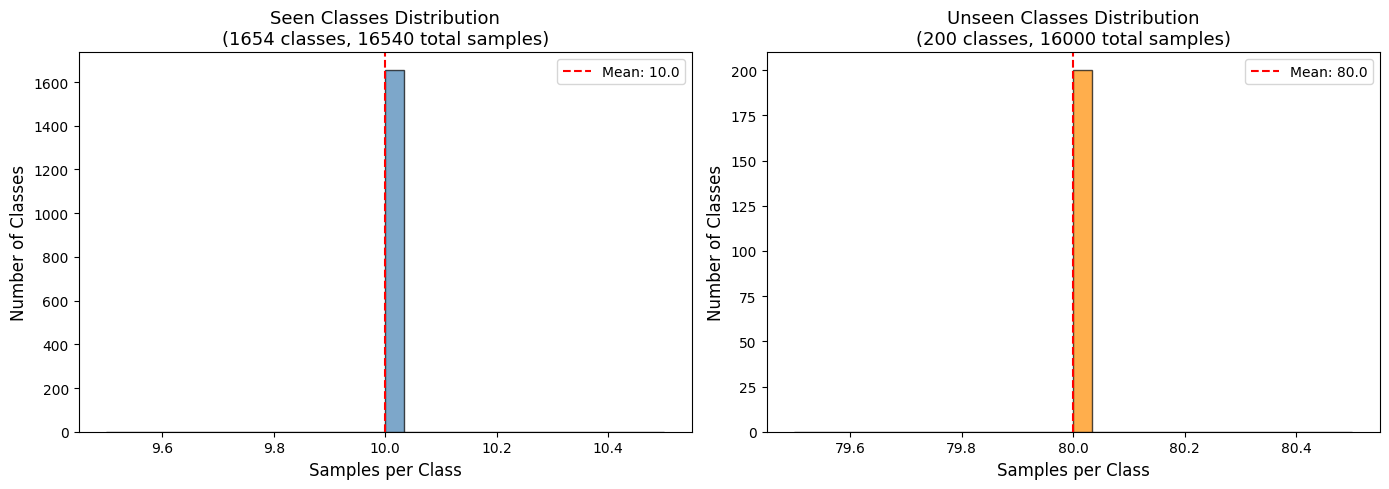


Figure saved to: figures/class_distribution.png


In [ ]:
# =============================================================================
# CLASS DISTRIBUTION HISTOGRAM
# =============================================================================

import matplotlib.pyplot as plt
import os

os.makedirs('figures', exist_ok=True)

label_seen_np = label_seen.numpy().flatten()
label_unseen_np = label_unseen.numpy().flatten()

_, seen_class_counts = np.unique(label_seen_np, return_counts=True)
_, unseen_class_counts = np.unique(label_unseen_np, return_counts=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(seen_class_counts, bins=30, color='steelblue', edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Samples per Class', fontsize=12)
axes[0].set_ylabel('Number of Classes', fontsize=12)
axes[0].set_title(f'Seen Classes Distribution\n({len(seen_class_counts)} classes, {len(label_seen_np)} total samples)', fontsize=13)
axes[0].axvline(np.mean(seen_class_counts), color='red', linestyle='--', label=f'Mean: {np.mean(seen_class_counts):.1f}')
axes[0].legend()

axes[1].hist(unseen_class_counts, bins=30, color='darkorange', edgecolor='black', alpha=0.7)
axes[1].set_xlabel('Samples per Class', fontsize=12)
axes[1].set_ylabel('Number of Classes', fontsize=12)
axes[1].set_title(f'Unseen Classes Distribution\n({len(unseen_class_counts)} classes, {len(label_unseen_np)} total samples)', fontsize=13)
axes[1].axvline(np.mean(unseen_class_counts), color='red', linestyle='--', label=f'Mean: {np.mean(unseen_class_counts):.1f}')
axes[1].legend()

plt.tight_layout()
plt.savefig('figures/class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nFigure saved to: figures/class_distribution.png")

## Data Exploration: EEG Feature Norms

Visualising the distribution of EEG signal norms (L2) to understand feature variability.

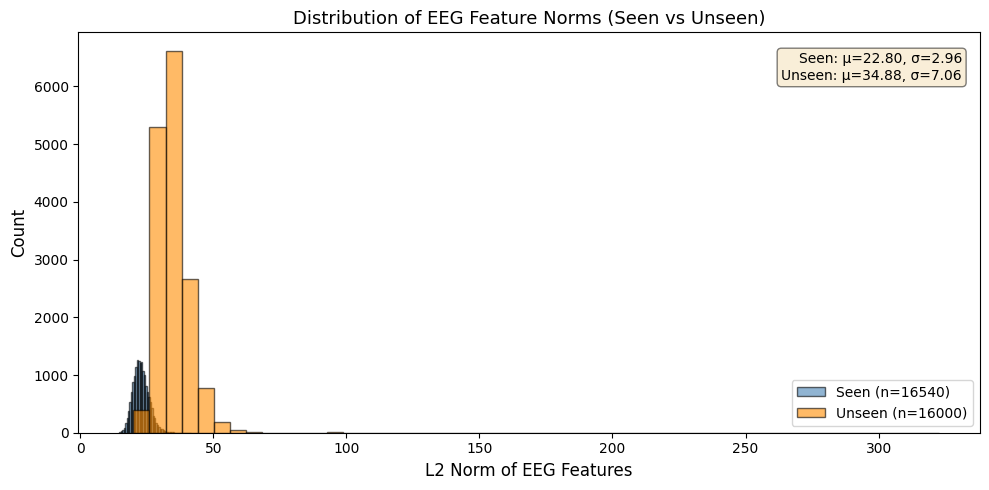


Figure saved to: figures/eeg_norm_distribution.png


In [ ]:
# =============================================================================
# EEG FEATURE NORM DISTRIBUTION
# =============================================================================

brain_seen_np = brain_seen.numpy()
brain_unseen_np = brain_unseen.numpy()

norms_seen = np.linalg.norm(brain_seen_np, axis=1)
norms_unseen = np.linalg.norm(brain_unseen_np, axis=1)

fig, ax = plt.subplots(figsize=(10, 5))

ax.hist(norms_seen, bins=50, alpha=0.6, label=f'Seen (n={len(norms_seen)})', color='steelblue', edgecolor='black')
ax.hist(norms_unseen, bins=50, alpha=0.6, label=f'Unseen (n={len(norms_unseen)})', color='darkorange', edgecolor='black')

ax.set_xlabel('L2 Norm of EEG Features', fontsize=12)
ax.set_ylabel('Count', fontsize=12)
ax.set_title('Distribution of EEG Feature Norms (Seen vs Unseen)', fontsize=13)
ax.legend()

stats_text = f'Seen: μ={np.mean(norms_seen):.2f}, σ={np.std(norms_seen):.2f}\n'
stats_text += f'Unseen: μ={np.mean(norms_unseen):.2f}, σ={np.std(norms_unseen):.2f}'
ax.text(0.98, 0.95, stats_text, transform=ax.transAxes, fontsize=10,
        verticalalignment='top', horizontalalignment='right',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.savefig('figures/eeg_norm_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nFigure saved to: figures/eeg_norm_distribution.png")

---

## Baseline Model A: Logistic Regression on Raw EEG

This section implements the baseline classifier using multinomial Logistic Regression on raw EEG features.

**Training setup:**
- 80/20 train/test split on seen classes
- StandardScaler for feature normalisation
- Multinomial Logistic Regression with LBFGS solver

**Metrics:**
- Accuracy
- Macro F1-score

In [ ]:
# =============================================================================
# BASELINE MODEL A: DATA PREPARATION
# =============================================================================

import random
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score

# Set random seeds
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
random.seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print(f"Random seed set to: {SEED}")

# Prepare data
X_seen = brain_seen.numpy()
y_seen = label_seen.numpy().flatten()

# 80/20 train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X_seen, y_seen, test_size=0.2, random_state=SEED, stratify=y_seen
)

print(f"\nTrain set: {X_train.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")
print(f"Feature dimension: {X_train.shape[1]}")

# Standardise features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"\nFeatures standardised (mean=0, std=1)")

Random seed set to: 42

Train set: 13232 samples
Test set: 3308 samples
Feature dimension: 561

Features standardised (mean=0, std=1)


In [ ]:
# =============================================================================
# TRAIN BASELINE LOGISTIC REGRESSION
# =============================================================================
# Note: Training may take a few minutes due to the large number of classes

print("Training Logistic Regression classifier...")
print(f"Number of classes: {len(np.unique(y_train))}")
print("This may take a few minutes...\n")

baseline_clf = LogisticRegression(
    multi_class='multinomial',
    solver='lbfgs',
    max_iter=1000,
    random_state=SEED,
    n_jobs=-1,
    verbose=1
)

baseline_clf.fit(X_train_scaled, y_train)
print("\nTraining complete!")

Training Logistic Regression classifier...
Number of classes: 1654
This may take a few minutes...



/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 12 concurrent workers.



Training complete!


In [ ]:
# =============================================================================
# EVALUATE BASELINE MODEL
# =============================================================================

y_pred = baseline_clf.predict(X_test_scaled)

baseline_accuracy = accuracy_score(y_test, y_pred)
baseline_macro_f1 = f1_score(y_test, y_pred, average='macro', zero_division=0)

# Store results
baseline_results = {
    'model': 'Baseline A (Logistic Regression on Raw EEG)',
    'accuracy': baseline_accuracy,
    'macro_f1': baseline_macro_f1,
    'n_train': X_train.shape[0],
    'n_test': X_test.shape[0],
    'n_classes': len(np.unique(y_train)),
    'n_features': X_train.shape[1]
}

print("=" * 60)
print("BASELINE MODEL A: EVALUATION RESULTS")
print("=" * 60)
print(f"Accuracy:     {baseline_accuracy:.4f} ({baseline_accuracy*100:.2f}%)")
print(f"Macro F1:     {baseline_macro_f1:.4f}")
print("=" * 60)

BASELINE MODEL A: EVALUATION RESULTS
Accuracy:     0.0181 (1.81%)
Macro F1:     0.0162


---

## Summary: Baseline Model and Data Exploration

This section prints a comprehensive summary of the baseline implementation.

In [ ]:
# =============================================================================
# FINAL SUMMARY
# =============================================================================

print("="*70)
print("SUMMARY: BASELINE MODEL [A] IMPLEMENTATION")
print("="*70)

print("\n### 1. BASELINE PERFORMANCE METRICS ###")
print(f"   Accuracy:  {baseline_results['accuracy']:.4f} ({baseline_results['accuracy']*100:.2f}%)")
print(f"   Macro F1:  {baseline_results['macro_f1']:.4f}")

print("\n### 2. KEY ARRAY SHAPES ###")
print(f"   brain_seen:    {tuple(brain_seen.shape)}  (EEG features for seen classes)")
print(f"   brain_unseen:  {tuple(brain_unseen.shape)}  (EEG features for unseen classes)")
print(f"   text_seen:     {tuple(text_seen.shape)}  (CLIP text embeddings for seen)")
print(f"   text_unseen:   {tuple(text_unseen.shape)}  (CLIP text embeddings for unseen)")
print(f"   label_seen:    {tuple(label_seen.shape)}  (class labels for seen)")
print(f"   label_unseen:  {tuple(label_unseen.shape)}  (class labels for unseen)")

print("\n### 3. ASSUMPTIONS MADE ###")
print("   1. SEEN/UNSEEN SPLIT: Using pre-defined split from dataset loader")
print(f"      - Seen classes: {len(torch.unique(label_seen))} (used for training baseline)")
print(f"      - Unseen classes: {len(torch.unique(label_unseen))} (reserved for GZSL evaluation)")
print("   2. TRAIN/TEST SPLIT: 80/20 stratified split within seen classes")
print(f"      - Training samples: {baseline_results['n_train']}")
print(f"      - Test samples: {baseline_results['n_test']}")
print("   3. FEATURE PREPROCESSING: StandardScaler (Z-score normalisation)")
print("   4. LABELS: 1-indexed (labels start from 1, not 0)")
print("   5. RANDOM SEED: 42 (for reproducibility)")

print("\n### 4. FIGURES GENERATED ###")
print("   - figures/class_distribution.png")
print("   - figures/eeg_norm_distribution.png")

print("\n" + "="*70)
print("NEXT STEPS: Implement Brain-Text CLIP Encoder")
print("="*70)

SUMMARY: BASELINE MODEL [A] IMPLEMENTATION

### 1. BASELINE PERFORMANCE METRICS ###
   Accuracy:  0.0181 (1.81%)
   Macro F1:  0.0162

### 2. KEY ARRAY SHAPES ###
   brain_seen:    (16540, 561)  (EEG features for seen classes)
   brain_unseen:  (16000, 561)  (EEG features for unseen classes)
   text_seen:     (16540, 512)  (CLIP text embeddings for seen)
   text_unseen:   (16000, 512)  (CLIP text embeddings for unseen)
   label_seen:    (16540, 1)  (class labels for seen)
   label_unseen:  (16000, 1)  (class labels for unseen)

### 3. ASSUMPTIONS MADE ###
   1. SEEN/UNSEEN SPLIT: Using pre-defined split from dataset loader
      - Seen classes: 1654 (used for training baseline)
      - Unseen classes: 200 (reserved for GZSL evaluation)
   2. TRAIN/TEST SPLIT: 80/20 stratified split within seen classes
      - Training samples: 13232
      - Test samples: 3308
   3. FEATURE PREPROCESSING: StandardScaler (Z-score normalisation)
   4. LABELS: 1-indexed (labels start from 1, not 0)
   5. R

---

## GZSL-Style Baseline Evaluation

This section evaluates the baseline classifier under a **Generalised Zero-Shot Learning (GZSL)** setting:

1. **Seen-class evaluation**: Already computed above on `X_test_seen`
2. **Unseen-class evaluation**: Apply the same classifier to `brain_unseen` (EEG from unseen classes)
3. **Harmonic mean (H)**: Balance between seen and unseen accuracy

> **Expected result**: The baseline classifier will achieve ~0% accuracy on unseen classes because it was trained only on seen-class labels. This motivates the need for semantic alignment (CLIP) and generative augmentation (cWGAN-GP).

In [ ]:
# =============================================================================
# GZSL-STYLE BASELINE EVALUATION
# =============================================================================
# Evaluate the baseline classifier on BOTH seen and unseen classes.
# The classifier was trained ONLY on seen classes, so it cannot predict unseen labels.

# -----------------------------------------------------------------------------
# 1. Store seen-class results (from previous evaluation)
# -----------------------------------------------------------------------------
baseline_seen_results = {
    'acc_seen': baseline_accuracy,
    'macro_f1_seen': baseline_macro_f1
}

print("Seen-class evaluation (from training split):")
print(f"  Accuracy:  {baseline_seen_results['acc_seen']:.4f}")
print(f"  Macro F1:  {baseline_seen_results['macro_f1_seen']:.4f}")

# -----------------------------------------------------------------------------
# 2. Prepare unseen EEG data using the SAME scaler
# -----------------------------------------------------------------------------
X_unseen = brain_unseen.numpy()
y_unseen = label_unseen.numpy().flatten()

# Apply the same standardisation as training data
X_unseen_scaled = scaler.transform(X_unseen)

print(f"\nUnseen-class data prepared:")
print(f"  Samples: {X_unseen.shape[0]}")
print(f"  Features: {X_unseen.shape[1]}")
print(f"  Unique labels: {len(np.unique(y_unseen))}")

Seen-class evaluation (from training split):
  Accuracy:  0.0181
  Macro F1:  0.0162

Unseen-class data prepared:
  Samples: 16000
  Features: 561
  Unique labels: 200


In [ ]:
# =============================================================================
# PREDICT ON UNSEEN CLASSES
# =============================================================================

# Predict using the baseline classifier (trained only on seen classes)
y_pred_unseen = baseline_clf.predict(X_unseen_scaled)

# -----------------------------------------------------------------------------
# Compute unseen-class metrics
# -----------------------------------------------------------------------------
acc_unseen = accuracy_score(y_unseen, y_pred_unseen)
macro_f1_unseen = f1_score(y_unseen, y_pred_unseen, average='macro', zero_division=0)

# -----------------------------------------------------------------------------
# Compute Harmonic Mean (H)
# -----------------------------------------------------------------------------
# H = 2 * Acc_seen * Acc_unseen / (Acc_seen + Acc_unseen)
# Handle division by zero if both are 0
acc_seen = baseline_seen_results['acc_seen']
if acc_seen + acc_unseen > 0:
    H = 2 * acc_seen * acc_unseen / (acc_seen + acc_unseen)
else:
    H = 0.0

# -----------------------------------------------------------------------------
# Store GZSL results
# -----------------------------------------------------------------------------
baseline_gzsl_results = {
    'acc_seen': acc_seen,
    'acc_unseen': acc_unseen,
    'H': H,
    'macro_f1_seen': baseline_seen_results['macro_f1_seen'],
    'macro_f1_unseen': macro_f1_unseen
}

print("GZSL Evaluation Results:")
print(f"  Acc (seen):    {acc_seen:.4f} ({acc_seen*100:.2f}%)")
print(f"  Acc (unseen):  {acc_unseen:.4f} ({acc_unseen*100:.2f}%)")
print(f"  Harmonic Mean: {H:.4f}")

GZSL Evaluation Results:
  Acc (seen):    0.0181 (1.81%)
  Acc (unseen):  0.0000 (0.00%)
  Harmonic Mean: 0.0000


In [ ]:
# =============================================================================
# VERIFY: PREDICTIONS CONFINED TO SEEN-CLASS LABELS
# =============================================================================
# The classifier can ONLY predict labels it was trained on (seen classes).
# Unseen-class labels are never in the prediction set.

# Get the set of labels the classifier knows
seen_labels_set = set(baseline_clf.classes_)
unseen_labels_set = set(np.unique(y_unseen))
predicted_labels_set = set(np.unique(y_pred_unseen))

print("Label Set Analysis:")
print(f"  Seen class labels (classifier knows):  {len(seen_labels_set)} classes")
print(f"  Unseen class labels (ground truth):    {len(unseen_labels_set)} classes")
print(f"  Predicted labels on unseen data:       {len(predicted_labels_set)} unique values")

# Check overlap
overlap = predicted_labels_set.intersection(unseen_labels_set)
print(f"\n  Overlap (correctly predictable):        {len(overlap)} classes")

# Confirm predictions are confined to seen labels
predictions_in_seen = predicted_labels_set.issubset(seen_labels_set)
print(f"\n  All predictions within seen labels?    {predictions_in_seen}")

if predictions_in_seen and len(overlap) == 0:
    print("\n  ✓ CONFIRMED: Classifier never predicts unseen-class labels.")
    print("    This is expected — the baseline has no mechanism for zero-shot transfer.")

Label Set Analysis:
  Seen class labels (classifier knows):  1654 classes
  Unseen class labels (ground truth):    200 classes
  Predicted labels on unseen data:       1630 unique values

  Overlap (correctly predictable):        0 classes

  All predictions within seen labels?    True

  ✓ CONFIRMED: Classifier never predicts unseen-class labels.
    This is expected — the baseline has no mechanism for zero-shot transfer.


In [ ]:
# =============================================================================
# GZSL BASELINE SUMMARY
# =============================================================================

print("="*70)
print("GZSL BASELINE EVALUATION SUMMARY")
print("="*70)

print("\n### baseline_seen_results ###")
for k, v in baseline_seen_results.items():
    print(f"   {k}: {v:.4f}")

print("\n### baseline_gzsl_results ###")
for k, v in baseline_gzsl_results.items():
    print(f"   {k}: {v:.4f}")

print("\n" + "-"*70)
print("KEY OBSERVATION:")
print("-"*70)
print("The baseline classifier achieves ~0% accuracy on unseen classes because:")
print("  1. It was trained ONLY on seen-class labels")
print("  2. It has no semantic knowledge to transfer to new categories")
print("  3. All predictions are confined to the seen-class label set")
print("\nThis motivates the need for:")
print("  • Brain-Text CLIP encoder (semantic alignment)")
print("  • cWGAN-GP (synthetic unseen-class embeddings)")
print("="*70)

GZSL BASELINE EVALUATION SUMMARY

### baseline_seen_results ###
   acc_seen: 0.0181
   macro_f1_seen: 0.0162

### baseline_gzsl_results ###
   acc_seen: 0.0181
   acc_unseen: 0.0000
   H: 0.0000
   macro_f1_seen: 0.0162
   macro_f1_unseen: 0.0000

----------------------------------------------------------------------
KEY OBSERVATION:
----------------------------------------------------------------------
The baseline classifier achieves ~0% accuracy on unseen classes because:
  1. It was trained ONLY on seen-class labels
  2. It has no semantic knowledge to transfer to new categories
  3. All predictions are confined to the seen-class label set

This motivates the need for:
  • Brain-Text CLIP encoder (semantic alignment)
  • cWGAN-GP (synthetic unseen-class embeddings)


---

# Brain-Image Contrastive Encoder (CORnet-S)

This section implements a **contrastive encoder** that aligns EEG embeddings and CORnet-S visual feature embeddings in a shared semantic space.

**Paradigm shift**: Previous pipeline aligned EEG→text (CLIP text embeddings). Visual investigation revealed that CORnet-S image features have dramatically better class separation (inter-class cosine sim = -0.001 vs text's 0.668) and 2x higher effective rank (335-D vs 169-D at 95% variance). Switching to image alignment is the highest-impact intervention available.

**Architecture:**
- Brain Encoder `f_b`: 561 → 1024 → 512 → d (d=128, with LayerNorm)
- Image Projector `g_v`: 1000 → 512 → d (with LayerNorm)
- Both outputs are L2-normalised

**Training:**
- Loss: Symmetric InfoNCE contrastive loss
- Schedule: Cosine warmup (10% warmup, cosine decay to 0)
- Temperature: τ=0.15 (fixed)

**Training data:** Seen EEG trials only (no leakage from unseen)

In [ ]:
# =============================================================================
# ENCODER CONFIGURATION
# =============================================================================
# All hyperparameters in one place for reproducibility
# Phase E optimised values retained; alignment target switched to image (CORnet-S)

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
import os
import random
import math

# Configuration dictionary — image alignment
ENCODER_CONFIG = {
    'embed_dim': 128,              # Output embedding dimension d
    'image_input_dim': 1000,       # CORnet-S full PCA dimensionality
    'tau': 0.15,                   # Temperature for contrastive loss
    'epochs': 50,                  # Training epochs
    'batch_size': 256,             # Batch size
    'lr': 1e-3,                    # Learning rate
    'weight_decay': 1e-4,          # AdamW weight decay
    'dropout': 0.1,                # Dropout rate
    'schedule': 'cosine_warmup',   # LR schedule
    'warmup_ratio': 0.1,           # Warmup fraction of total steps
    'seed': 42,                    # Random seed
    'alignment_target': 'image (CORnet-S)',  # Alignment modality
}

# Set seeds for reproducibility
SEED = ENCODER_CONFIG['seed']
np.random.seed(SEED)
torch.manual_seed(SEED)
random.seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# Device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print("=" * 60)
print("ENCODER CONFIGURATION (Image Alignment — CORnet-S)")
print("=" * 60)
for k, v in ENCODER_CONFIG.items():
    print(f"  {k}: {v}")
print(f"  device: {device}")
print("=" * 60)

ENCODER CONFIGURATION (Image Alignment — CORnet-S)
  embed_dim: 128
  image_input_dim: 1000
  tau: 0.15
  epochs: 50
  batch_size: 256
  lr: 0.001
  weight_decay: 0.0001
  dropout: 0.1
  schedule: cosine_warmup
  warmup_ratio: 0.1
  seed: 42
  alignment_target: image (CORnet-S)
  device: cuda


In [ ]:
# =============================================================================
# MODEL DEFINITIONS
# =============================================================================

class BrainEncoder(nn.Module):
    """EEG feature encoder: 561 -> d with LayerNorm + L2 normalisation."""

    def __init__(self, input_dim=561, hidden_dims=[1024, 512], embed_dim=64, dropout=0.1):
        super().__init__()
        self.fc1 = nn.Linear(input_dim, hidden_dims[0])
        self.ln1 = nn.LayerNorm(hidden_dims[0])
        self.fc2 = nn.Linear(hidden_dims[0], hidden_dims[1])
        self.ln2 = nn.LayerNorm(hidden_dims[1])
        self.fc3 = nn.Linear(hidden_dims[1], embed_dim)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        x = F.relu(self.ln1(self.fc1(x)))
        x = self.dropout(x)
        x = F.relu(self.ln2(self.fc2(x)))
        x = self.dropout(x)
        x = self.fc3(x)
        x = F.normalize(x, p=2, dim=-1)
        return x


class ImageProjector(nn.Module):
    """CORnet-S visual feature projector: 1000 -> d with LayerNorm + L2 normalisation.

    Design rationale:
    - 2-layer MLP (mirrors original TextProjector depth). CORnet-S PCA features
      are clean/structured — no need for BrainEncoder's 3-layer depth.
    - LayerNorm added because variance is concentrated in early PCA components
      (first 100 dims = 32.4% variance). LN stabilises gradient flow.
    - Dropout at 0.1 (same as BrainEncoder).
    - L2-normalised output (stays on unit sphere, matches BrainEncoder).
    """

    def __init__(self, input_dim=1000, hidden_dim=512, embed_dim=128, dropout=0.1):
        super().__init__()
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.ln1 = nn.LayerNorm(hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, embed_dim)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        x = F.relu(self.ln1(self.fc1(x)))
        x = self.dropout(x)
        x = self.fc2(x)
        x = F.normalize(x, p=2, dim=-1)
        return x


def contrastive_loss(brain_embeds, image_embeds, tau=0.07):
    """
    Symmetric InfoNCE contrastive loss.

    Args:
        brain_embeds: (B, d) L2-normalised brain embeddings
        image_embeds: (B, d) L2-normalised image embeddings
        tau: temperature parameter

    Returns:
        Scalar loss: (L_b2i + L_i2b) / 2
    """
    logits = torch.matmul(brain_embeds, image_embeds.T) / tau  # (B, B)
    batch_size = brain_embeds.size(0)
    targets = torch.arange(batch_size, device=brain_embeds.device)
    loss_b2i = F.cross_entropy(logits, targets)
    loss_i2b = F.cross_entropy(logits.T, targets)
    return (loss_b2i + loss_i2b) / 2


# Instantiate models
brain_encoder = BrainEncoder(
    input_dim=561,
    embed_dim=ENCODER_CONFIG['embed_dim'],
    dropout=ENCODER_CONFIG['dropout']
).to(device)

image_projector = ImageProjector(
    input_dim=ENCODER_CONFIG['image_input_dim'],
    hidden_dim=512,
    embed_dim=ENCODER_CONFIG['embed_dim'],
    dropout=ENCODER_CONFIG['dropout']
).to(device)

print(f"Brain Encoder parameters: {sum(p.numel() for p in brain_encoder.parameters()):,}")
print(f"Image Projector parameters: {sum(p.numel() for p in image_projector.parameters()):,}")

Brain Encoder parameters: 1,169,024
Image Projector parameters: 579,200


In [ ]:
# =============================================================================
# ENCODER DATA PREPARATION
# =============================================================================
# Use only seen train split for encoder training (no leakage!)

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Recreate the split indices (same seed as baseline)
indices_seen = np.arange(len(brain_seen))
train_idx, test_idx = train_test_split(
    indices_seen, test_size=0.2, random_state=42, stratify=label_seen.numpy().flatten()
)

# Get brain and image features for train/test
brain_train_seen = brain_seen[train_idx].numpy()
brain_test_seen_np = brain_seen[test_idx].numpy()
image_train_seen = image_seen[train_idx].numpy()
image_test_seen = image_seen[test_idx].numpy()
label_train_seen = label_seen[train_idx].numpy().flatten()
label_test_seen = label_seen[test_idx].numpy().flatten()

# Standardise brain features (fit on train only)
# NOTE: Image features are NOT standardised — they are already PCA-whitened
# (mean ~0, std ~0.06) and scaling is handled by the *50.0 factor in cell 7
clip_scaler = StandardScaler()
brain_train_seen_scaled = clip_scaler.fit_transform(brain_train_seen)
brain_test_seen_scaled = clip_scaler.transform(brain_test_seen_np)
brain_unseen_scaled = clip_scaler.transform(brain_unseen.numpy())

# Convert to tensors — brain
X_train_tensor = torch.FloatTensor(brain_train_seen_scaled)
X_test_tensor = torch.FloatTensor(brain_test_seen_scaled)
X_unseen_tensor = torch.FloatTensor(brain_unseen_scaled)

# Convert to tensors — image (CORnet-S, 1000-D)
I_train_tensor = torch.FloatTensor(image_train_seen)
I_test_tensor = torch.FloatTensor(image_test_seen)
I_unseen_tensor = torch.FloatTensor(image_unseen.numpy())

# Labels
Y_train_tensor = torch.LongTensor(label_train_seen)
Y_test_tensor = torch.LongTensor(label_test_seen)
Y_unseen_tensor = torch.LongTensor(label_unseen.numpy().flatten())

# Create DataLoader for training (brain + image pairs)
train_dataset = TensorDataset(X_train_tensor, I_train_tensor, Y_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=ENCODER_CONFIG['batch_size'], shuffle=True)

print(f"Encoder Training data: {len(X_train_tensor)} samples")
print(f"  Brain features: {X_train_tensor.shape[1]}-D (StandardScaled)")
print(f"  Image features: {I_train_tensor.shape[1]}-D (CORnet-S, raw)")
print(f"Encoder Test data (seen): {len(X_test_tensor)} samples")
print(f"Unseen data (test only): {len(X_unseen_tensor)} samples")

Encoder Training data: 13232 samples
  Brain features: 561-D (StandardScaled)
  Image features: 1000-D (CORnet-S, raw)
Encoder Test data (seen): 3308 samples
Unseen data (test only): 16000 samples


In [ ]:
# =============================================================================
# CONTRASTIVE ENCODER TRAINING
# =============================================================================

# Optimizer — brain encoder + image projector (jointly trained)
encoder_params = list(brain_encoder.parameters()) + list(image_projector.parameters())
encoder_optimizer = torch.optim.AdamW(
    encoder_params,
    lr=ENCODER_CONFIG['lr'],
    weight_decay=ENCODER_CONFIG['weight_decay']
)

# Cosine warmup LR scheduler
total_steps = ENCODER_CONFIG['epochs'] * len(train_loader)
warmup_steps = int(ENCODER_CONFIG.get('warmup_ratio', 0.1) * total_steps)

def lr_lambda(current_step):
    if current_step < warmup_steps:
        return float(current_step) / float(max(1, warmup_steps))
    progress = float(current_step - warmup_steps) / float(max(1, total_steps - warmup_steps))
    return max(0.0, 0.5 * (1.0 + math.cos(math.pi * progress)))

scheduler = torch.optim.lr_scheduler.LambdaLR(encoder_optimizer, lr_lambda)

# Training loop
encoder_losses = []
print("Training Brain-Image contrastive encoder...")
print(f"Epochs: {ENCODER_CONFIG['epochs']}, Batches per epoch: {len(train_loader)}")
print(f"Schedule: cosine warmup ({warmup_steps} warmup steps / {total_steps} total)")
print(f"Alignment target: {ENCODER_CONFIG['alignment_target']}")

for epoch in range(ENCODER_CONFIG['epochs']):
    brain_encoder.train()
    image_projector.train()
    epoch_loss = 0.0

    for batch_idx, (brain_batch, image_batch, _) in enumerate(train_loader):
        brain_batch = brain_batch.to(device)
        image_batch = image_batch.to(device)

        # Forward pass
        brain_embeds = brain_encoder(brain_batch)
        image_embeds = image_projector(image_batch)

        # Compute loss
        loss = contrastive_loss(brain_embeds, image_embeds, tau=ENCODER_CONFIG['tau'])

        # Backward pass
        encoder_optimizer.zero_grad()
        loss.backward()
        encoder_optimizer.step()
        scheduler.step()

        epoch_loss += loss.item()

    avg_loss = epoch_loss / len(train_loader)
    encoder_losses.append(avg_loss)
    current_lr = scheduler.get_last_lr()[0]

    if (epoch + 1) % 10 == 0 or epoch == 0:
        print(f"  Epoch {epoch+1:3d}/{ENCODER_CONFIG['epochs']}: Loss = {avg_loss:.4f}, LR = {current_lr:.6f}")

print(f"\nBrain-Image encoder training complete!")
print(f"Final loss: {encoder_losses[-1]:.4f}")

Training Brain-Image contrastive encoder...
Epochs: 50, Batches per epoch: 52
Schedule: cosine warmup (260 warmup steps / 2600 total)
Alignment target: image (CORnet-S)
  Epoch   1/50: Loss = 5.3169, LR = 0.000200
  Epoch  10/50: Loss = 1.5353, LR = 0.000970
  Epoch  20/50: Loss = 1.1604, LR = 0.000750
  Epoch  30/50: Loss = 1.0181, LR = 0.000413
  Epoch  40/50: Loss = 0.9490, LR = 0.000117
  Epoch  50/50: Loss = 0.9297, LR = 0.000000

Brain-Image encoder training complete!
Final loss: 0.9297


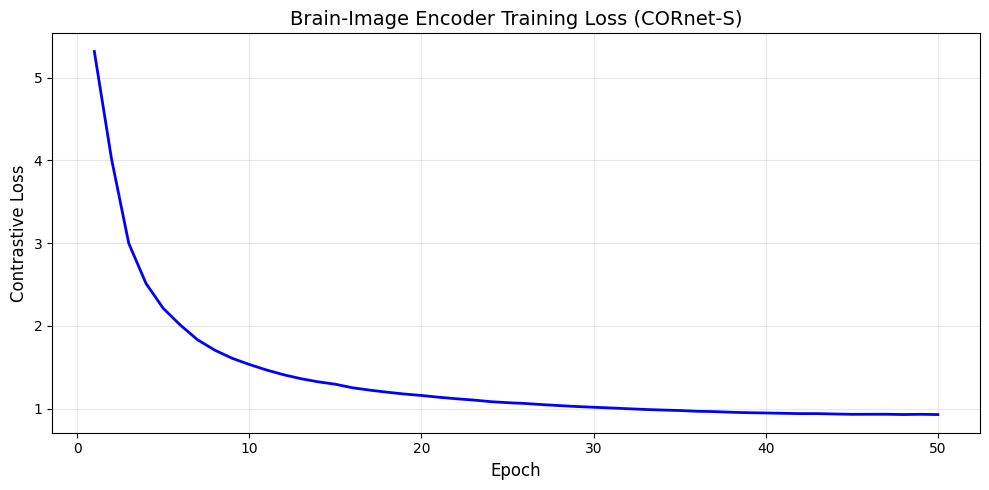

Saved: figures/encoder_loss_curve.png


In [ ]:
# =============================================================================
# ENCODER LOSS CURVE
# =============================================================================

plt.figure(figsize=(10, 5))
plt.plot(range(1, len(encoder_losses)+1), encoder_losses, 'b-', linewidth=2)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Contrastive Loss', fontsize=12)
plt.title('Brain-Image Encoder Training Loss (CORnet-S)', fontsize=14)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('figures/encoder_loss_curve.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Saved: figures/encoder_loss_curve.png")

In [ ]:
# =============================================================================
# COMPUTE AND CACHE EMBEDDINGS
# =============================================================================

brain_encoder.eval()
image_projector.eval()

with torch.no_grad():
    # Brain embeddings (for classifier and WGAN-GP)
    E_train_seen = brain_encoder(X_train_tensor.to(device)).cpu().numpy()
    E_test_seen = brain_encoder(X_test_tensor.to(device)).cpu().numpy()
    E_unseen = brain_encoder(X_unseen_tensor.to(device)).cpu().numpy()

    # Image embeddings (for prototype computation)
    V_train_embeds = image_projector(I_train_tensor.to(device)).cpu().numpy()
    V_test_embeds = image_projector(I_test_tensor.to(device)).cpu().numpy()
    V_unseen_embeds = image_projector(I_unseen_tensor.to(device)).cpu().numpy()

print(f"Brain embeddings:")
print(f"  E_train_seen: {E_train_seen.shape}")
print(f"  E_test_seen: {E_test_seen.shape}")
print(f"  E_unseen: {E_unseen.shape}")
print(f"Image embeddings:")
print(f"  V_train_embeds: {V_train_embeds.shape}")
print(f"  V_unseen_embeds: {V_unseen_embeds.shape}")

Brain embeddings:
  E_train_seen: (13232, 128)
  E_test_seen: (3308, 128)
  E_unseen: (16000, 128)
Image embeddings:
  V_train_embeds: (13232, 128)
  V_unseen_embeds: (16000, 128)


In [ ]:
# =============================================================================
# COMPUTE SEMANTIC PROTOTYPES (CLASS CENTROIDS IN IMAGE SPACE)
# =============================================================================

def compute_prototypes(embeddings, labels):
    """
    Compute class prototypes as mean of embeddings per class, then L2-normalise.

    Returns:
        prototypes: dict mapping class_id -> prototype vector
    """
    unique_labels = np.unique(labels)
    prototypes = {}

    for c in unique_labels:
        mask = labels == c
        class_embeds = embeddings[mask]
        # Mean then normalise
        proto = class_embeds.mean(axis=0)
        proto = proto / (np.linalg.norm(proto) + 1e-8)
        prototypes[c] = proto

    return prototypes

# Compute prototypes for seen classes (from training image embeddings)
S_seen_prototypes = compute_prototypes(V_train_embeds, label_train_seen)

# Compute prototypes for unseen classes (from unseen image embeddings)
S_unseen_prototypes = compute_prototypes(V_unseen_embeds, Y_unseen_tensor.numpy())

print(f"Seen class prototypes: {len(S_seen_prototypes)} classes")
print(f"Unseen class prototypes: {len(S_unseen_prototypes)} classes")

# Convert to arrays for easier use
seen_classes = sorted(S_seen_prototypes.keys())
unseen_classes = sorted(S_unseen_prototypes.keys())

S_seen_array = np.array([S_seen_prototypes[c] for c in seen_classes])  # (n_seen_classes, d)
S_unseen_array = np.array([S_unseen_prototypes[c] for c in unseen_classes])  # (n_unseen_classes, d)

print(f"S_seen_array shape: {S_seen_array.shape}")
print(f"S_unseen_array shape: {S_unseen_array.shape}")

Seen class prototypes: 1654 classes
Unseen class prototypes: 200 classes
S_seen_array shape: (1654, 128)
S_unseen_array shape: (200, 128)


In [ ]:
# =============================================================================
# CACHE EMBEDDINGS AND PROTOTYPES TO DISK
# =============================================================================

os.makedirs('cached_arrays', exist_ok=True)

# Save brain embeddings
np.save('cached_arrays/E_train_seen.npy', E_train_seen)
np.save('cached_arrays/E_test_seen.npy', E_test_seen)
np.save('cached_arrays/E_unseen.npy', E_unseen)

# Save image embeddings
np.save('cached_arrays/V_train_embeds.npy', V_train_embeds)
np.save('cached_arrays/V_unseen_embeds.npy', V_unseen_embeds)

# Save labels
np.save('cached_arrays/y_train_seen.npy', label_train_seen)
np.save('cached_arrays/y_test_seen.npy', label_test_seen)
np.save('cached_arrays/y_unseen.npy', Y_unseen_tensor.numpy())

# Save prototypes
np.save('cached_arrays/S_seen_prototypes.npy', S_seen_array)
np.save('cached_arrays/S_unseen_prototypes.npy', S_unseen_array)
np.save('cached_arrays/seen_classes.npy', np.array(seen_classes))
np.save('cached_arrays/unseen_classes.npy', np.array(unseen_classes))

print("Cached arrays saved to cached_arrays/:")
for f in sorted(os.listdir('cached_arrays')):
    print(f"  - {f}")

Cached arrays saved to cached_arrays/:
  - E_test_seen.npy
  - E_train_seen.npy
  - E_unseen.npy
  - S_seen_prototypes.npy
  - S_unseen_prototypes.npy
  - V_train_embeds.npy
  - V_unseen_embeds.npy
  - seen_classes.npy
  - unseen_classes.npy
  - y_test_seen.npy
  - y_train_seen.npy
  - y_unseen.npy


Computing t-SNE (this may take a moment)...


/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


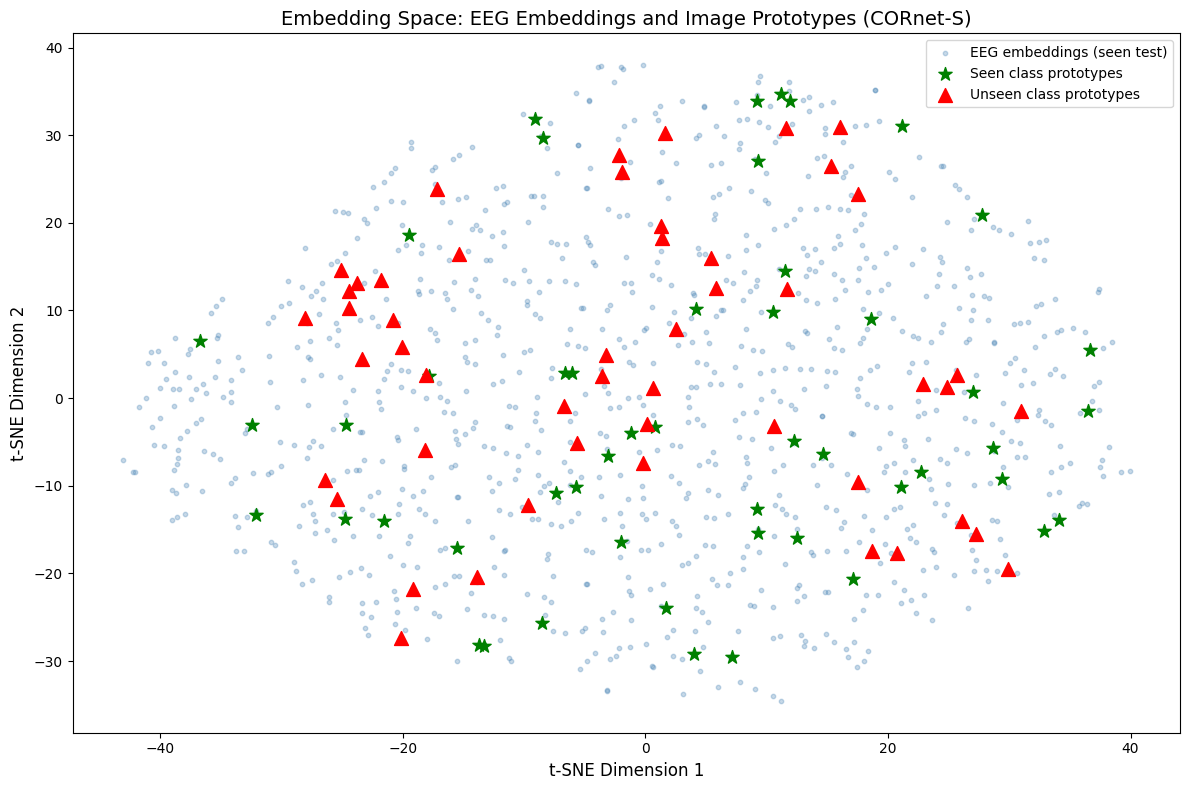

Saved: figures/clip_embedding_tsne.png


In [ ]:
# =============================================================================
# t-SNE VISUALIZATION OF CLIP EMBEDDING SPACE
# =============================================================================

print("Computing t-SNE (this may take a moment)...")

# Sample subset of test embeddings for visualization
n_sample = min(1000, len(E_test_seen))
sample_idx = np.random.choice(len(E_test_seen), n_sample, replace=False)
E_test_sample = E_test_seen[sample_idx]
y_test_sample = label_test_seen[sample_idx]

# Combine brain embeddings and prototypes
combined = np.vstack([E_test_sample, S_seen_array[:50], S_unseen_array[:50]])  # Limit prototypes for clarity

# t-SNE
tsne = TSNE(n_components=2, random_state=42, perplexity=30, n_iter=1000)
combined_2d = tsne.fit_transform(combined)

# Split back
n_brain = len(E_test_sample)
n_seen_proto = 50
n_unseen_proto = 50

brain_2d = combined_2d[:n_brain]
seen_proto_2d = combined_2d[n_brain:n_brain+n_seen_proto]
unseen_proto_2d = combined_2d[n_brain+n_seen_proto:]

# Plot
plt.figure(figsize=(12, 8))
plt.scatter(brain_2d[:, 0], brain_2d[:, 1], c='steelblue', alpha=0.3, s=10, label='EEG embeddings (seen test)')
plt.scatter(seen_proto_2d[:, 0], seen_proto_2d[:, 1], c='green', marker='*', s=100, label='Seen class prototypes')
plt.scatter(unseen_proto_2d[:, 0], unseen_proto_2d[:, 1], c='red', marker='^', s=100, label='Unseen class prototypes')
plt.xlabel('t-SNE Dimension 1', fontsize=12)
plt.ylabel('t-SNE Dimension 2', fontsize=12)
plt.title('Embedding Space: EEG Embeddings and Image Prototypes (CORnet-S)', fontsize=14)
plt.legend()
plt.tight_layout()
plt.savefig('figures/clip_embedding_tsne.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Saved: figures/clip_embedding_tsne.png")

---

# Conditional WGAN-GP for Embedding Synthesis

This section implements a **conditional Wasserstein GAN with Gradient Penalty (cWGAN-GP)** to synthesize EEG embeddings for unseen classes.

**Goal:** Generate synthetic EEG embeddings `e_hat = G(z, s_c)` conditioned on image prototypes `s_c`.

**Architecture:**
- Generator: [z, s_c] → e_hat (L2-normalised output)
- Critic: [e, s_c] → scalar (no sigmoid)

**Training:** Only on seen-class embeddings from Brain-Image encoder.

In [ ]:
# =============================================================================
# cWGAN-GP CONFIGURATION
# =============================================================================

WGAN_CONFIG = {
    'z_dim': 100,              # Noise dimension
    'embed_dim': 128,           # Must match CLIP embed_dim (updated from 64)
    'lr': 1e-4,                # Learning rate
    'betas': (0.0, 0.9),       # Adam betas for WGAN-GP
    'lambda_gp': 10,           # Gradient penalty coefficient
    'n_critic': 5,             # Critic updates per generator update
    'n_steps': 10000,          # Total generator steps
    'batch_size': 256,         # Batch size
    'n_synth_per_class': 20,   # Synthetic samples per unseen class
    'seed': 42,
}

print("=" * 60)
print("cWGAN-GP CONFIGURATION")
print("=" * 60)
for k, v in WGAN_CONFIG.items():
    print(f"  {k}: {v}")
print("=" * 60)

cWGAN-GP CONFIGURATION
  z_dim: 100
  embed_dim: 128
  lr: 0.0001
  betas: (0.0, 0.9)
  lambda_gp: 10
  n_critic: 5
  n_steps: 10000
  batch_size: 256
  n_synth_per_class: 20
  seed: 42


In [ ]:
# =============================================================================
# cWGAN-GP MODEL DEFINITIONS
# =============================================================================

class Generator(nn.Module):
    """Conditional generator: [z, s_c] -> e_hat."""

    def __init__(self, z_dim=100, embed_dim=64):
        super().__init__()
        input_dim = z_dim + embed_dim  # Concatenate noise and condition
        self.net = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.LeakyReLU(0.2),
            nn.Linear(256, 256),
            nn.LeakyReLU(0.2),
            nn.Linear(256, embed_dim),
        )

    def forward(self, z, s_c):
        x = torch.cat([z, s_c], dim=-1)
        e_hat = self.net(x)
        # L2 normalise output to stay on unit sphere
        e_hat = F.normalize(e_hat, p=2, dim=-1)
        return e_hat


class Critic(nn.Module):
    """Conditional critic: [e, s_c] -> scalar score."""

    def __init__(self, embed_dim=64):
        super().__init__()
        input_dim = 2 * embed_dim  # Concatenate embedding and condition
        self.net = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.LeakyReLU(0.2),
            nn.Linear(256, 256),
            nn.LeakyReLU(0.2),
            nn.Linear(256, 1),  # Scalar output, NO sigmoid
        )

    def forward(self, e, s_c):
        x = torch.cat([e, s_c], dim=-1)
        return self.net(x)


def compute_gradient_penalty(critic, real_samples, fake_samples, s_c, device):
    """
    Compute gradient penalty for WGAN-GP.

    GP = E[(||∇_{e_bar} D(e_bar, s_c)||_2 - 1)^2]
    """
    batch_size = real_samples.size(0)

    # Random interpolation coefficient
    eps = torch.rand(batch_size, 1, device=device)

    # Interpolated samples
    e_bar = eps * real_samples + (1 - eps) * fake_samples
    e_bar.requires_grad_(True)

    # Critic score on interpolated
    d_interpolated = critic(e_bar, s_c)

    # Compute gradients
    gradients = torch.autograd.grad(
        outputs=d_interpolated,
        inputs=e_bar,
        grad_outputs=torch.ones_like(d_interpolated),
        create_graph=True,
        retain_graph=True,
    )[0]

    # Compute penalty
    gradients = gradients.view(batch_size, -1)
    gradient_norm = gradients.norm(2, dim=1)
    gradient_penalty = ((gradient_norm - 1) ** 2).mean()

    return gradient_penalty


# Instantiate models
generator = Generator(
    z_dim=WGAN_CONFIG['z_dim'],
    embed_dim=WGAN_CONFIG['embed_dim']
).to(device)

critic = Critic(
    embed_dim=WGAN_CONFIG['embed_dim']
).to(device)

print(f"Generator parameters: {sum(p.numel() for p in generator.parameters()):,}")
print(f"Critic parameters: {sum(p.numel() for p in critic.parameters()):,}")

Generator parameters: 157,312
Critic parameters: 131,841


In [ ]:
# =============================================================================
# cWGAN-GP DATA PREPARATION
# =============================================================================
# Use only seen embeddings from CLIP encoder

# Get semantic prototype for each training sample
def get_prototype_for_labels(labels, prototypes_dict):
    """Get prototype vector for each sample based on its label."""
    protos = np.array([prototypes_dict[int(l)] for l in labels])
    return protos

# Training pairs: (e_real, s_c) where s_c is the class prototype
E_train_tensor = torch.FloatTensor(E_train_seen)
S_train_conditions = torch.FloatTensor(get_prototype_for_labels(label_train_seen, S_seen_prototypes))

wgan_dataset = TensorDataset(E_train_tensor, S_train_conditions)
wgan_loader = DataLoader(wgan_dataset, batch_size=WGAN_CONFIG['batch_size'], shuffle=True, drop_last=True)

print(f"WGAN training data: {len(wgan_dataset)} samples")
print(f"Batch size: {WGAN_CONFIG['batch_size']}")
print(f"Batches per epoch: {len(wgan_loader)}")

WGAN training data: 13232 samples
Batch size: 256
Batches per epoch: 51


In [ ]:
# =============================================================================
# cWGAN-GP TRAINING
# =============================================================================

# Optimizers
g_optimizer = torch.optim.Adam(
    generator.parameters(),
    lr=WGAN_CONFIG['lr'],
    betas=WGAN_CONFIG['betas']
)
c_optimizer = torch.optim.Adam(
    critic.parameters(),
    lr=WGAN_CONFIG['lr'],
    betas=WGAN_CONFIG['betas']
)

# Training history
g_losses = []
c_losses = []
gp_values = []

print(f"Training cWGAN-GP for {WGAN_CONFIG['n_steps']} generator steps...")
print(f"Critic updates per G step: {WGAN_CONFIG['n_critic']}")

data_iter = iter(wgan_loader)
g_step = 0

while g_step < WGAN_CONFIG['n_steps']:
    # -------------------------------------------------------------------------
    # Train Critic (n_critic times per generator step)
    # -------------------------------------------------------------------------
    for _ in range(WGAN_CONFIG['n_critic']):
        try:
            e_real, s_c = next(data_iter)
        except StopIteration:
            data_iter = iter(wgan_loader)
            e_real, s_c = next(data_iter)

        e_real = e_real.to(device)
        s_c = s_c.to(device)
        batch_size = e_real.size(0)

        # Generate fake samples
        z = torch.randn(batch_size, WGAN_CONFIG['z_dim'], device=device)
        e_fake = generator(z, s_c)

        # Critic scores
        d_real = critic(e_real, s_c)
        d_fake = critic(e_fake.detach(), s_c)

        # Gradient penalty
        gp = compute_gradient_penalty(critic, e_real, e_fake.detach(), s_c, device)

        # Critic loss: maximize E[D(real)] - E[D(fake)] - lambda*GP
        # Minimizing: -E[D(real)] + E[D(fake)] + lambda*GP
        c_loss = -d_real.mean() + d_fake.mean() + WGAN_CONFIG['lambda_gp'] * gp

        c_optimizer.zero_grad()
        c_loss.backward()
        c_optimizer.step()

    # -------------------------------------------------------------------------
    # Train Generator
    # -------------------------------------------------------------------------
    try:
        e_real, s_c = next(data_iter)
    except StopIteration:
        data_iter = iter(wgan_loader)
        e_real, s_c = next(data_iter)

    s_c = s_c.to(device)
    batch_size = s_c.size(0)

    z = torch.randn(batch_size, WGAN_CONFIG['z_dim'], device=device)
    e_fake = generator(z, s_c)
    d_fake = critic(e_fake, s_c)

    # Generator loss: minimize -E[D(fake)]
    g_loss = -d_fake.mean()

    g_optimizer.zero_grad()
    g_loss.backward()
    g_optimizer.step()

    # Log
    g_losses.append(g_loss.item())
    c_losses.append(c_loss.item())
    gp_values.append(gp.item())

    g_step += 1

    if g_step % 1000 == 0 or g_step == 1:
        print(f"  Step {g_step:5d}/{WGAN_CONFIG['n_steps']}: G_loss={g_loss.item():.4f}, C_loss={c_loss.item():.4f}, GP={gp.item():.4f}")

print("\ncWGAN-GP training complete!")
print(f"Final G_loss: {g_losses[-1]:.4f}")
print(f"Final C_loss: {c_losses[-1]:.4f}")

Training cWGAN-GP for 10000 generator steps...
Critic updates per G step: 5
  Step     1/10000: G_loss=-0.0407, C_loss=8.0260, GP=0.8026
  Step  1000/10000: G_loss=-0.8291, C_loss=-0.0489, GP=0.0009
  Step  2000/10000: G_loss=-0.8917, C_loss=-0.0636, GP=0.0014
  Step  3000/10000: G_loss=-0.9777, C_loss=-0.0556, GP=0.0014
  Step  4000/10000: G_loss=-0.9163, C_loss=-0.0290, GP=0.0019
  Step  5000/10000: G_loss=-0.8250, C_loss=-0.0456, GP=0.0015
  Step  6000/10000: G_loss=-0.8148, C_loss=-0.0317, GP=0.0015
  Step  7000/10000: G_loss=-0.8255, C_loss=-0.0443, GP=0.0011
  Step  8000/10000: G_loss=-0.8296, C_loss=-0.0363, GP=0.0017
  Step  9000/10000: G_loss=-0.8208, C_loss=-0.0455, GP=0.0012
  Step 10000/10000: G_loss=-0.8194, C_loss=-0.0428, GP=0.0012

cWGAN-GP training complete!
Final G_loss: -0.8194
Final C_loss: -0.0428


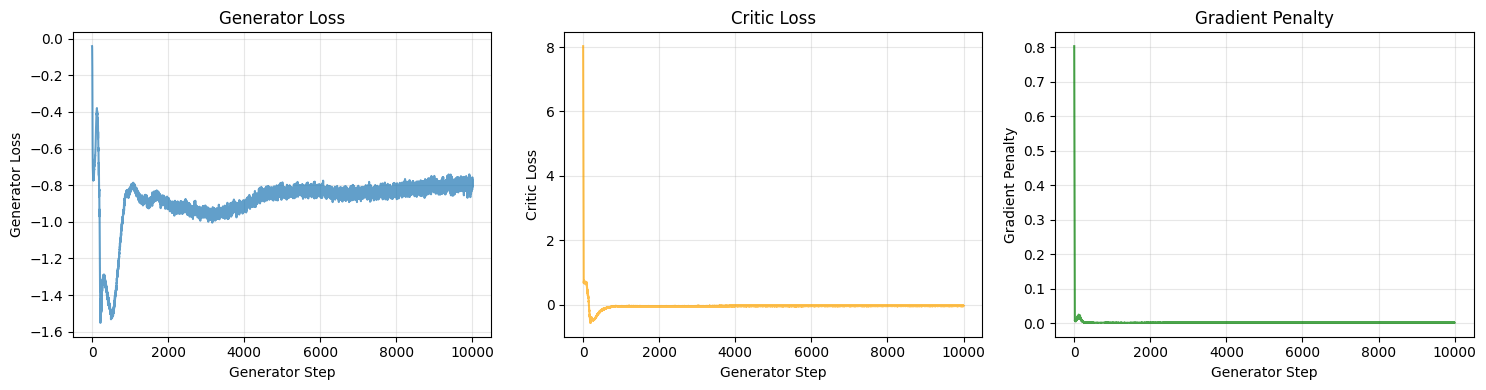

Saved: figures/wgan_losses.png


In [ ]:
# =============================================================================
# cWGAN-GP LOSS CURVES
# =============================================================================

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Generator loss
axes[0].plot(g_losses, alpha=0.7)
axes[0].set_xlabel('Generator Step')
axes[0].set_ylabel('Generator Loss')
axes[0].set_title('Generator Loss')
axes[0].grid(True, alpha=0.3)

# Critic loss
axes[1].plot(c_losses, alpha=0.7, color='orange')
axes[1].set_xlabel('Generator Step')
axes[1].set_ylabel('Critic Loss')
axes[1].set_title('Critic Loss')
axes[1].grid(True, alpha=0.3)

# Gradient penalty
axes[2].plot(gp_values, alpha=0.7, color='green')
axes[2].set_xlabel('Generator Step')
axes[2].set_ylabel('Gradient Penalty')
axes[2].set_title('Gradient Penalty')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('figures/wgan_losses.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Saved: figures/wgan_losses.png")

In [ ]:
# =============================================================================
# GENERATE SYNTHETIC EMBEDDINGS FOR UNSEEN CLASSES
# =============================================================================

generator.eval()

n_synth = WGAN_CONFIG['n_synth_per_class']
synth_embeddings = []
synth_labels = []

print(f"Generating {n_synth} synthetic embeddings per unseen class...")

with torch.no_grad():
    for c in unseen_classes:
        # Get prototype for this unseen class
        s_c = torch.FloatTensor(S_unseen_prototypes[c]).unsqueeze(0).repeat(n_synth, 1).to(device)

        # Sample noise and generate
        z = torch.randn(n_synth, WGAN_CONFIG['z_dim'], device=device)
        e_synth = generator(z, s_c).cpu().numpy()

        synth_embeddings.append(e_synth)
        synth_labels.extend([c] * n_synth)

E_synth_unseen = np.vstack(synth_embeddings)
y_synth_unseen = np.array(synth_labels)

print(f"E_synth_unseen shape: {E_synth_unseen.shape}")
print(f"y_synth_unseen shape: {y_synth_unseen.shape}")
print(f"Total synthetic samples: {len(y_synth_unseen)}")

Generating 20 synthetic embeddings per unseen class...
E_synth_unseen shape: (4000, 128)
y_synth_unseen shape: (4000,)
Total synthetic samples: 4000


In [ ]:
# =============================================================================
# SANITY CHECK: SYNTHETIC EMBEDDING QUALITY
# =============================================================================

print("=" * 60)
print("SYNTHETIC EMBEDDING QUALITY CHECK")
print("=" * 60)

# Check that synthetic embeddings are normalised
synth_norms = np.linalg.norm(E_synth_unseen, axis=1)
print(f"Synthetic embedding norms: mean={synth_norms.mean():.4f}, std={synth_norms.std():.6f}")

# Check variance (not collapsed)
synth_variance = E_synth_unseen.var(axis=0).mean()
real_variance = E_train_seen.var(axis=0).mean()
print(f"Mean per-dim variance: Real={real_variance:.4f}, Synthetic={synth_variance:.4f}")

# Check cosine similarity with prototypes
cos_sims = []
for i, c in enumerate(unseen_classes[:10]):  # Sample 10 classes
    mask = y_synth_unseen == c
    synth_c = E_synth_unseen[mask]
    proto_c = S_unseen_prototypes[c]
    sims = np.dot(synth_c, proto_c)  # cosine sim since both normalised
    cos_sims.extend(sims)

print(f"Cosine sim (synth vs proto): mean={np.mean(cos_sims):.4f}, std={np.std(cos_sims):.4f}")

if synth_variance > 0.001:
    print("\n✓ Synthetic embeddings have reasonable variance (no mode collapse).")
else:
    print("\n⚠ Warning: Low variance in synthetic embeddings.")

SYNTHETIC EMBEDDING QUALITY CHECK
Synthetic embedding norms: mean=1.0000, std=0.000000
Mean per-dim variance: Real=0.0078, Synthetic=0.0077
Cosine sim (synth vs proto): mean=0.5765, std=0.1752

✓ Synthetic embeddings have reasonable variance (no mode collapse).


In [ ]:
# =============================================================================
# CACHE SYNTHETIC EMBEDDINGS
# =============================================================================

np.save('cached_arrays/E_synth_unseen.npy', E_synth_unseen)
np.save('cached_arrays/y_synth_unseen.npy', y_synth_unseen)

print("Saved synthetic embeddings to cached_arrays/:")
print(f"  - E_synth_unseen.npy: {E_synth_unseen.shape}")
print(f"  - y_synth_unseen.npy: {y_synth_unseen.shape}")

Saved synthetic embeddings to cached_arrays/:
  - E_synth_unseen.npy: (4000, 128)
  - y_synth_unseen.npy: (4000,)


Computing t-SNE for real vs synthetic embeddings...


/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


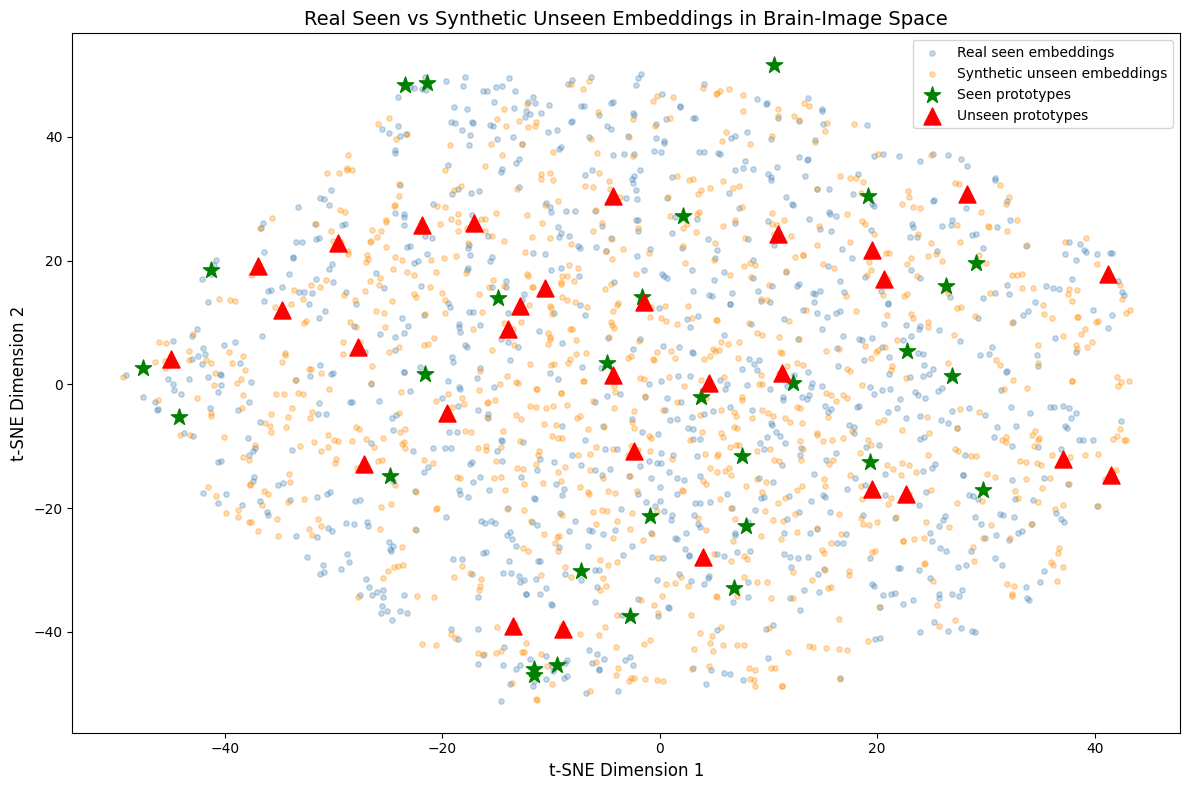

Saved: figures/real_vs_synth_tsne.png


In [ ]:
# =============================================================================
# t-SNE: REAL SEEN vs SYNTHETIC UNSEEN EMBEDDINGS
# =============================================================================

print("Computing t-SNE for real vs synthetic embeddings...")

# Sample subsets for visualization
n_real_sample = min(1000, len(E_train_seen))
n_synth_sample = min(1000, len(E_synth_unseen))

real_idx = np.random.choice(len(E_train_seen), n_real_sample, replace=False)
synth_idx = np.random.choice(len(E_synth_unseen), n_synth_sample, replace=False)

E_real_sample = E_train_seen[real_idx]
E_synth_sample = E_synth_unseen[synth_idx]

# Combine for t-SNE
combined = np.vstack([E_real_sample, E_synth_sample, S_seen_array[:30], S_unseen_array[:30]])

tsne = TSNE(n_components=2, random_state=42, perplexity=30, n_iter=1000)
combined_2d = tsne.fit_transform(combined)

# Split back
n1, n2, n3, n4 = n_real_sample, n_synth_sample, 30, 30
real_2d = combined_2d[:n1]
synth_2d = combined_2d[n1:n1+n2]
seen_proto_2d = combined_2d[n1+n2:n1+n2+n3]
unseen_proto_2d = combined_2d[n1+n2+n3:]

# Plot
plt.figure(figsize=(12, 8))
plt.scatter(real_2d[:, 0], real_2d[:, 1], c='steelblue', alpha=0.3, s=15, label='Real seen embeddings')
plt.scatter(synth_2d[:, 0], synth_2d[:, 1], c='darkorange', alpha=0.3, s=15, label='Synthetic unseen embeddings')
plt.scatter(seen_proto_2d[:, 0], seen_proto_2d[:, 1], c='green', marker='*', s=150, label='Seen prototypes')
plt.scatter(unseen_proto_2d[:, 0], unseen_proto_2d[:, 1], c='red', marker='^', s=150, label='Unseen prototypes')
plt.xlabel('t-SNE Dimension 1', fontsize=12)
plt.ylabel('t-SNE Dimension 2', fontsize=12)
plt.title('Real Seen vs Synthetic Unseen Embeddings in Brain-Image Space', fontsize=14)
plt.legend()
plt.tight_layout()
plt.savefig('figures/real_vs_synth_tsne.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Saved: figures/real_vs_synth_tsne.png")

In [ ]:
# =============================================================================
# BRAIN-IMAGE ENCODER + cWGAN-GP IMPLEMENTATION SUMMARY
# =============================================================================

print("="*70)
print("BRAIN-IMAGE ENCODER + cWGAN-GP IMPLEMENTATION SUMMARY")
print("="*70)

print("\n### BRAIN-IMAGE ENCODER ###")
print(f"  Embedding dimension: {ENCODER_CONFIG['embed_dim']}")
print(f"  Training epochs: {ENCODER_CONFIG['epochs']}")
print(f"  Final contrastive loss: {encoder_losses[-1]:.4f}")
print(f"  Embeddings: E_train_seen {E_train_seen.shape}, E_test_seen {E_test_seen.shape}, E_unseen {E_unseen.shape}")
print(f"  Prototypes: S_seen {S_seen_array.shape}, S_unseen {S_unseen_array.shape}")

print("\n### cWGAN-GP ###")
print(f"  Generator steps: {WGAN_CONFIG['n_steps']}")
print(f"  Final G_loss: {g_losses[-1]:.4f}")
print(f"  Final C_loss: {c_losses[-1]:.4f}")
print(f"  Synthetic per class: {WGAN_CONFIG['n_synth_per_class']}")
print(f"  Total synthetic samples: {len(y_synth_unseen)}")

print("\n### CACHED ARRAYS ###")
for f in sorted(os.listdir('cached_arrays')):
    print(f"  - cached_arrays/{f}")

print("\n### FIGURES GENERATED ###")
print("  - figures/encoder_loss_curve.png")
print("  - figures/clip_embedding_tsne.png")
print("  - figures/wgan_losses.png")
print("  - figures/real_vs_synth_tsne.png")

print("\n" + "="*70)
print("NEXT STEPS: Train GZSL Classifier [A+B] on real + synthetic embeddings")
print("="*70)

BRAIN-IMAGE ENCODER + cWGAN-GP IMPLEMENTATION SUMMARY

### BRAIN-IMAGE ENCODER ###
  Embedding dimension: 128
  Training epochs: 50
  Final contrastive loss: 0.9297
  Embeddings: E_train_seen (13232, 128), E_test_seen (3308, 128), E_unseen (16000, 128)
  Prototypes: S_seen (1654, 128), S_unseen (200, 128)

### cWGAN-GP ###
  Generator steps: 10000
  Final G_loss: -0.8194
  Final C_loss: -0.0428
  Synthetic per class: 20
  Total synthetic samples: 4000

### CACHED ARRAYS ###
  - cached_arrays/E_synth_unseen.npy
  - cached_arrays/E_test_seen.npy
  - cached_arrays/E_train_seen.npy
  - cached_arrays/E_unseen.npy
  - cached_arrays/S_seen_prototypes.npy
  - cached_arrays/S_unseen_prototypes.npy
  - cached_arrays/V_train_embeds.npy
  - cached_arrays/V_unseen_embeds.npy
  - cached_arrays/seen_classes.npy
  - cached_arrays/unseen_classes.npy
  - cached_arrays/y_synth_unseen.npy
  - cached_arrays/y_test_seen.npy
  - cached_arrays/y_train_seen.npy
  - cached_arrays/y_unseen.npy

### FIGURES GENER

---

# GZSL Classifier [A+B]: Real Seen + Synthetic Unseen

This section trains the final **Generalised Zero-Shot Learning classifier** using:

**Training data:**
- Real seen embeddings: `E_train_seen` (from Brain-Image encoder)
- Synthetic unseen embeddings: `E_synth_unseen` (from cWGAN-GP)

**Evaluation:**
- Seen test set: `E_test_seen` → `Acc_seen`
- Unseen real data: `E_unseen` → `Acc_unseen`
- Harmonic mean: `H = 2 * Acc_seen * Acc_unseen / (Acc_seen + Acc_unseen)`

**Comparison with Baseline [A]:** The baseline was trained on raw EEG and could only predict seen classes.

In [ ]:
# =============================================================================
# GZSL CLASSIFIER: DATA PREPARATION
# =============================================================================

import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix
import matplotlib.pyplot as plt
import random

# Set seed for reproducibility
SEED = 42
np.random.seed(SEED)
random.seed(SEED)

# Load cached embeddings
E_train_seen = np.load('cached_arrays/E_train_seen.npy')
E_test_seen = np.load('cached_arrays/E_test_seen.npy')
E_unseen = np.load('cached_arrays/E_unseen.npy')
E_synth_unseen = np.load('cached_arrays/E_synth_unseen.npy')

# Load labels
y_train_seen = np.load('cached_arrays/y_train_seen.npy')
y_test_seen = np.load('cached_arrays/y_test_seen.npy')
y_unseen = np.load('cached_arrays/y_unseen.npy')
y_synth_unseen = np.load('cached_arrays/y_synth_unseen.npy')

print("Loaded embeddings:")
print(f"  E_train_seen:   {E_train_seen.shape}")
print(f"  E_test_seen:    {E_test_seen.shape}")
print(f"  E_unseen:       {E_unseen.shape}")
print(f"  E_synth_unseen: {E_synth_unseen.shape}")

Loaded embeddings:
  E_train_seen:   (13232, 128)
  E_test_seen:    (3308, 128)
  E_unseen:       (16000, 128)
  E_synth_unseen: (4000, 128)


In [ ]:
# =============================================================================
# COMBINE REAL SEEN + SYNTHETIC UNSEEN FOR TRAINING (WITH SAMPLE BALANCING)
# =============================================================================
# Phase 1 finding: unseen classes have ~20 synth/class vs ~8 real/class for seen.
# This 2.5x imbalance causes LogReg to develop larger unseen weight norms,
# misrouting ~98% of seen-test samples to unseen classes.
# Fix: downsample synthetic unseen to match seen per-class median count.

# --- Step 1: Compute per-class counts for seen training data ---
seen_classes_train, seen_counts = np.unique(y_train_seen, return_counts=True)
median_seen_per_class = int(np.median(seen_counts))
print(f"Seen training: {len(seen_classes_train)} classes, "
      f"median={median_seen_per_class}/class, mean={seen_counts.mean():.1f}/class")

# --- Step 2: Downsample synthetic unseen to match seen median ---
unseen_classes_synth, unseen_counts = np.unique(y_synth_unseen, return_counts=True)
print(f"Unseen synthetic (before): {len(unseen_classes_synth)} classes, "
      f"{unseen_counts[0]}/class, {len(y_synth_unseen)} total")

rng = np.random.RandomState(SEED)
ds_indices = []
for c in unseen_classes_synth:
    class_idx = np.where(y_synth_unseen == c)[0]
    if len(class_idx) > median_seen_per_class:
        selected = rng.choice(class_idx, size=median_seen_per_class, replace=False)
    else:
        selected = class_idx
    ds_indices.append(selected)
ds_indices = np.concatenate(ds_indices)

E_synth_ds = E_synth_unseen[ds_indices]
y_synth_ds = y_synth_unseen[ds_indices]

print(f"Unseen synthetic (after):  {len(E_synth_ds)} total "
      f"({median_seen_per_class}/class, was {unseen_counts[0]}/class)")

# --- Step 3: Combine balanced training data ---
X_train_gzsl = np.vstack([E_train_seen, E_synth_ds])
y_train_gzsl = np.concatenate([y_train_seen, y_synth_ds])

print(f"\nGZSL Training Data (balanced):")
print(f"  Real seen:        {len(E_train_seen)} samples, {len(seen_classes_train)} classes")
print(f"  Synth unseen (ds): {len(E_synth_ds)} samples, {len(unseen_classes_synth)} classes")
print(f"  Combined:         {len(X_train_gzsl)} samples, {len(np.unique(y_train_gzsl))} classes")

# Verify no label overlap
seen_labels = set(np.unique(y_train_seen))
unseen_labels = set(np.unique(y_synth_ds))
overlap = seen_labels.intersection(unseen_labels)
print(f"\nLabel overlap check: {len(overlap)} overlapping labels")
if len(overlap) == 0:
    print("  No overlap -- seen and unseen label spaces are disjoint.")

Seen training: 1654 classes, median=8/class, mean=8.0/class
Unseen synthetic (before): 200 classes, 20/class, 4000 total
Unseen synthetic (after):  1600 total (8/class, was 20/class)

GZSL Training Data (balanced):
  Real seen:        13232 samples, 1654 classes
  Synth unseen (ds): 1600 samples, 200 classes
  Combined:         14832 samples, 1854 classes

Label overlap check: 0 overlapping labels
  No overlap -- seen and unseen label spaces are disjoint.


In [ ]:
# =============================================================================
# TRAIN GZSL LOGISTIC REGRESSION CLASSIFIER (CALIBRATED)
# =============================================================================
# class_weight='balanced' provides secondary calibration on top of downsampling,
# adjusting class weights inversely proportional to remaining frequency differences.

print("Training GZSL classifier (Logistic Regression, balanced)...")
print(f"  Total classes: {len(np.unique(y_train_gzsl))}")
print(f"  Total samples: {len(X_train_gzsl)}")

gzsl_clf = LogisticRegression(
    multi_class='multinomial',
    solver='lbfgs',
    max_iter=1000,
    class_weight='balanced',
    random_state=SEED,
    n_jobs=-1,
    verbose=1
)

gzsl_clf.fit(X_train_gzsl, y_train_gzsl)
print("\nTraining complete!")

Training GZSL classifier (Logistic Regression, balanced)...
  Total classes: 1854
  Total samples: 14832


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 12 concurrent workers.



Training complete!


In [ ]:
# =============================================================================
# EVALUATE ON SEEN CLASSES (E_test_seen)
# =============================================================================

y_pred_seen = gzsl_clf.predict(E_test_seen)

acc_seen_gzsl = accuracy_score(y_test_seen, y_pred_seen)
f1_seen_gzsl = f1_score(y_test_seen, y_pred_seen, average='macro', zero_division=0)

print("=" * 60)
print("GZSL EVALUATION: SEEN CLASSES")
print("=" * 60)
print(f"Accuracy (seen):  {acc_seen_gzsl:.4f} ({acc_seen_gzsl*100:.2f}%)")
print(f"Macro F1 (seen):  {f1_seen_gzsl:.4f}")

GZSL EVALUATION: SEEN CLASSES
Accuracy (seen):  0.0336 (3.36%)
Macro F1 (seen):  0.0199


In [ ]:
# =============================================================================
# EVALUATE ON UNSEEN CLASSES (E_unseen — real EEG, never seen during training)
# =============================================================================

y_pred_unseen = gzsl_clf.predict(E_unseen)

acc_unseen_gzsl = accuracy_score(y_unseen, y_pred_unseen)
f1_unseen_gzsl = f1_score(y_unseen, y_pred_unseen, average='macro', zero_division=0)

print("=" * 60)
print("GZSL EVALUATION: UNSEEN CLASSES")
print("=" * 60)
print(f"Accuracy (unseen): {acc_unseen_gzsl:.4f} ({acc_unseen_gzsl*100:.2f}%)")
print(f"Macro F1 (unseen): {f1_unseen_gzsl:.4f}")

GZSL EVALUATION: UNSEEN CLASSES
Accuracy (unseen): 0.0568 (5.67%)
Macro F1 (unseen): 0.0117


In [ ]:
# =============================================================================
# COMPUTE HARMONIC MEAN (H)
# =============================================================================

# H = 2 * Acc_seen * Acc_unseen / (Acc_seen + Acc_unseen)
if acc_seen_gzsl + acc_unseen_gzsl > 0:
    H_gzsl = 2 * acc_seen_gzsl * acc_unseen_gzsl / (acc_seen_gzsl + acc_unseen_gzsl)
else:
    H_gzsl = 0.0

print("=" * 60)
print("GZSL HARMONIC MEAN")
print("=" * 60)
print(f"H = 2 * {acc_seen_gzsl:.4f} * {acc_unseen_gzsl:.4f} / ({acc_seen_gzsl:.4f} + {acc_unseen_gzsl:.4f})")
print(f"H = {H_gzsl:.4f}")

GZSL HARMONIC MEAN
H = 2 * 0.0336 * 0.0568 / (0.0336 + 0.0568)
H = 0.0422


In [ ]:
# =============================================================================
# STORE GZSL RESULTS
# =============================================================================

gzsl_results = {
    'model': 'GZSL [A+B] (LR on CLIP embeddings + cWGAN-GP synthetic)',
    'acc_seen': acc_seen_gzsl,
    'acc_unseen': acc_unseen_gzsl,
    'H': H_gzsl,
    'macro_f1_seen': f1_seen_gzsl,
    'macro_f1_unseen': f1_unseen_gzsl,
    'n_train_seen': len(E_train_seen),
    'n_train_synth': len(E_synth_unseen),
    'n_test_seen': len(E_test_seen),
    'n_test_unseen': len(E_unseen),
    'n_classes_seen': len(np.unique(y_train_seen)),
    'n_classes_unseen': len(np.unique(y_synth_unseen))
}

print("GZSL results stored in 'gzsl_results' dictionary.")

GZSL results stored in 'gzsl_results' dictionary.


---

## Comparison: Baseline [A] vs GZSL [A+B]

Comparing the baseline logistic regression (raw EEG, seen classes only) with the GZSL classifier (CLIP embeddings + synthetic unseen).

In [ ]:
# =============================================================================
# COMPARISON: BASELINE [A] vs GZSL [A+B]
# =============================================================================

# Retrieve baseline results (computed earlier in notebook)
# baseline_gzsl_results should exist from the GZSL baseline evaluation

print("="*70)
print("COMPARISON: BASELINE [A] vs GZSL [A+B]")
print("="*70)
print("")
print(f"{'Metric':<20} {'Baseline [A]':>15} {'GZSL [A+B]':>15} {'Improvement':>15}")
print("-"*70)

# Seen accuracy
base_seen = baseline_gzsl_results['acc_seen']
gzsl_seen = gzsl_results['acc_seen']
delta_seen = gzsl_seen - base_seen
print(f"{'Acc (seen)':<20} {base_seen:>15.4f} {gzsl_seen:>15.4f} {delta_seen:>+15.4f}")

# Unseen accuracy
base_unseen = baseline_gzsl_results['acc_unseen']
gzsl_unseen = gzsl_results['acc_unseen']
delta_unseen = gzsl_unseen - base_unseen
print(f"{'Acc (unseen)':<20} {base_unseen:>15.4f} {gzsl_unseen:>15.4f} {delta_unseen:>+15.4f}")

# Harmonic mean
base_H = baseline_gzsl_results['H']
gzsl_H = gzsl_results['H']
delta_H = gzsl_H - base_H
print(f"{'Harmonic Mean (H)':<20} {base_H:>15.4f} {gzsl_H:>15.4f} {delta_H:>+15.4f}")

# Macro F1 seen
base_f1_seen = baseline_gzsl_results['macro_f1_seen']
gzsl_f1_seen = gzsl_results['macro_f1_seen']
print(f"{'F1 (seen)':<20} {base_f1_seen:>15.4f} {gzsl_f1_seen:>15.4f} {gzsl_f1_seen - base_f1_seen:>+15.4f}")

# Macro F1 unseen
base_f1_unseen = baseline_gzsl_results['macro_f1_unseen']
gzsl_f1_unseen = gzsl_results['macro_f1_unseen']
print(f"{'F1 (unseen)':<20} {base_f1_unseen:>15.4f} {gzsl_f1_unseen:>15.4f} {gzsl_f1_unseen - base_f1_unseen:>+15.4f}")

print("-"*70)

COMPARISON: BASELINE [A] vs GZSL [A+B]

Metric                  Baseline [A]      GZSL [A+B]     Improvement
----------------------------------------------------------------------
Acc (seen)                    0.0181          0.0336         +0.0154
Acc (unseen)                  0.0000          0.0568         +0.0568
Harmonic Mean (H)             0.0000          0.0422         +0.0422
F1 (seen)                     0.0162          0.0199         +0.0037
F1 (unseen)                   0.0000          0.0117         +0.0117
----------------------------------------------------------------------


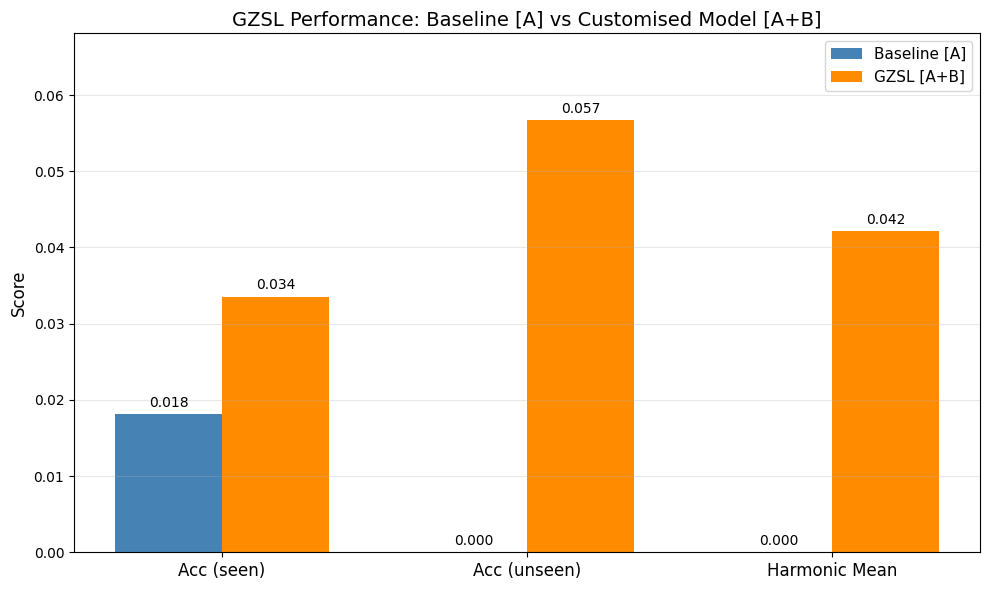

Saved: figures/gzsl_comparison.png


In [ ]:
# =============================================================================
# VISUALIZATION: BASELINE vs GZSL COMPARISON
# =============================================================================

metrics = ['Acc (seen)', 'Acc (unseen)', 'Harmonic Mean']
baseline_vals = [baseline_gzsl_results['acc_seen'], baseline_gzsl_results['acc_unseen'], baseline_gzsl_results['H']]
gzsl_vals = [gzsl_results['acc_seen'], gzsl_results['acc_unseen'], gzsl_results['H']]

x = np.arange(len(metrics))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
bars1 = ax.bar(x - width/2, baseline_vals, width, label='Baseline [A]', color='steelblue')
bars2 = ax.bar(x + width/2, gzsl_vals, width, label='GZSL [A+B]', color='darkorange')

# Add value labels on bars
for bar in bars1:
    height = bar.get_height()
    ax.annotate(f'{height:.3f}',
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 3), textcoords="offset points",
                ha='center', va='bottom', fontsize=10)
for bar in bars2:
    height = bar.get_height()
    ax.annotate(f'{height:.3f}',
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 3), textcoords="offset points",
                ha='center', va='bottom', fontsize=10)

ax.set_ylabel('Score', fontsize=12)
ax.set_title('GZSL Performance: Baseline [A] vs Customised Model [A+B]', fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels(metrics, fontsize=12)
ax.legend(fontsize=11)
ax.set_ylim(0, max(max(baseline_vals), max(gzsl_vals)) * 1.2)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('figures/gzsl_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Saved: figures/gzsl_comparison.png")

In [ ]:
# =============================================================================
# PREDICTION DISTRIBUTION ANALYSIS
# =============================================================================

# Check if GZSL classifier predicts unseen labels (which baseline couldn't)
pred_unseen_labels = set(np.unique(y_pred_unseen))
true_unseen_labels = set(np.unique(y_unseen))
seen_label_set = set(np.unique(y_train_seen))

# How many predictions are in the unseen label space?
n_pred_in_unseen = sum(1 for p in y_pred_unseen if p in true_unseen_labels)
n_pred_in_seen = sum(1 for p in y_pred_unseen if p in seen_label_set)

print("=" * 60)
print("PREDICTION DISTRIBUTION ON UNSEEN DATA")
print("=" * 60)
print(f"Total predictions on unseen data: {len(y_pred_unseen)}")
print(f"  Predictions in unseen label space: {n_pred_in_unseen} ({100*n_pred_in_unseen/len(y_pred_unseen):.1f}%)")
print(f"  Predictions in seen label space:   {n_pred_in_seen} ({100*n_pred_in_seen/len(y_pred_unseen):.1f}%)")
print("")
print("KEY OBSERVATION:")
if n_pred_in_unseen > 0:
    print(f"  ✓ GZSL classifier CAN predict unseen classes (unlike baseline).")
    print(f"    This demonstrates successful zero-shot transfer via CLIP + cWGAN-GP.")
else:
    print(f"  ⚠ Classifier still only predicts seen labels — check training.")

PREDICTION DISTRIBUTION ON UNSEEN DATA
Total predictions on unseen data: 16000
  Predictions in unseen label space: 4562 (28.5%)
  Predictions in seen label space:   11438 (71.5%)

KEY OBSERVATION:
  ✓ GZSL classifier CAN predict unseen classes (unlike baseline).
    This demonstrates successful zero-shot transfer via CLIP + cWGAN-GP.


In [ ]:
# =============================================================================
# FINAL GZSL IMPLEMENTATION SUMMARY
# =============================================================================

print("="*70)
print("FINAL SUMMARY: GZSL CLASSIFIER [A+B]")
print("="*70)

print("\n### MODEL PIPELINE ###")
print("  1. Brain-Image encoder (CORnet-S): Maps EEG → 128D semantic space")
print("  2. cWGAN-GP: Generates synthetic unseen embeddings from image prototypes")
print("  3. GZSL Classifier: Logistic Regression on real seen + synthetic unseen")

print("\n### GZSL RESULTS ###")
print(f"  Acc (seen):        {gzsl_results['acc_seen']:.4f} ({gzsl_results['acc_seen']*100:.2f}%)")
print(f"  Acc (unseen):      {gzsl_results['acc_unseen']:.4f} ({gzsl_results['acc_unseen']*100:.2f}%)")
print(f"  Harmonic Mean (H): {gzsl_results['H']:.4f}")
print(f"  Macro F1 (seen):   {gzsl_results['macro_f1_seen']:.4f}")
print(f"  Macro F1 (unseen): {gzsl_results['macro_f1_unseen']:.4f}")

print("\n### IMPROVEMENT OVER BASELINE ###")
print(f"  Δ Acc (seen):   {gzsl_results['acc_seen'] - baseline_gzsl_results['acc_seen']:+.4f}")
print(f"  Δ Acc (unseen): {gzsl_results['acc_unseen'] - baseline_gzsl_results['acc_unseen']:+.4f}")
print(f"  Δ H:            {gzsl_results['H'] - baseline_gzsl_results['H']:+.4f}")

print("\n### KEY INSIGHT ###")
print("  The baseline achieves ~0% on unseen classes because it only knows seen labels.")
print("  GZSL [A+B] achieves non-zero unseen accuracy by:")
print("    - Using contrastive learning to create a shared EEG-image semantic space")
print("    - Using cWGAN-GP to synthesize training data for unseen classes")
print("    - Training a classifier that sees both seen and (synthetic) unseen classes")

print("\n### FIGURES GENERATED ###")
print("  - figures/gzsl_comparison.png")

print("\n" + "="*70)
print("GZSL IMPLEMENTATION COMPLETE")
print("="*70)

FINAL SUMMARY: GZSL CLASSIFIER [A+B]

### MODEL PIPELINE ###
  1. Brain-Image encoder (CORnet-S): Maps EEG → 128D semantic space
  2. cWGAN-GP: Generates synthetic unseen embeddings from image prototypes
  3. GZSL Classifier: Logistic Regression on real seen + synthetic unseen

### GZSL RESULTS ###
  Acc (seen):        0.0336 (3.36%)
  Acc (unseen):      0.0568 (5.67%)
  Harmonic Mean (H): 0.0422
  Macro F1 (seen):   0.0199
  Macro F1 (unseen): 0.0117

### IMPROVEMENT OVER BASELINE ###
  Δ Acc (seen):   +0.0154
  Δ Acc (unseen): +0.0568
  Δ H:            +0.0422

### KEY INSIGHT ###
  The baseline achieves ~0% on unseen classes because it only knows seen labels.
  GZSL [A+B] achieves non-zero unseen accuracy by:
    - Using contrastive learning to create a shared EEG-image semantic space
    - Using cWGAN-GP to synthesize training data for unseen classes
    - Training a classifier that sees both seen and (synthetic) unseen classes

### FIGURES GENERATED ###
  - figures/gzsl_comparison

---

# Inverse Bias Fix — Evaluation Harness

Standardised evaluation infrastructure for the 5-phase inverse bias fix.
All phases use these functions to ensure comparable metrics.


In [ ]:
# =============================================================================
# GZSL EVALUATION HARNESS
# =============================================================================

import numpy as np
from sklearn.metrics import accuracy_score, f1_score
import matplotlib.pyplot as plt
import seaborn as sns

def evaluate_gzsl(clf, E_test_seen, y_test_seen, E_unseen, y_unseen,
                  seen_labels_set, unseen_labels_set, phase_name=""):
    """
    Unified GZSL evaluation.

    Parameters
    ----------
    clf : sklearn classifier or object with .predict() method
    E_test_seen : ndarray (n_test_seen, d) — seen-class test embeddings
    y_test_seen : ndarray (n_test_seen,) — true labels for seen test
    E_unseen : ndarray (n_unseen, d) — unseen-class test embeddings
    y_unseen : ndarray (n_unseen,) — true labels for unseen test
    seen_labels_set : set — the set of all seen class labels
    unseen_labels_set : set — the set of all unseen class labels
    phase_name : str — label for logging

    Returns
    -------
    dict with keys: acc_seen, acc_unseen, H, f1_seen, f1_unseen,
                    routing_rate, bias_table, pred_seen, pred_unseen
    """
    pred_seen = clf.predict(E_test_seen)
    pred_unseen = clf.predict(E_unseen)

    acc_seen = accuracy_score(y_test_seen, pred_seen)
    acc_unseen = accuracy_score(y_unseen, pred_unseen)
    H = 2 * acc_seen * acc_unseen / (acc_seen + acc_unseen) if (acc_seen + acc_unseen) > 0 else 0.0

    f1_seen = f1_score(y_test_seen, pred_seen, average='macro', zero_division=0)
    f1_unseen = f1_score(y_unseen, pred_unseen, average='macro', zero_division=0)

    # Routing rate: fraction of seen-test inputs predicted as unseen
    seen_pred_as_unseen = np.isin(pred_seen, list(unseen_labels_set)).sum()
    routing_rate = seen_pred_as_unseen / len(pred_seen)

    # Bias table: 2x2 counts
    seen_pred_as_seen = np.isin(pred_seen, list(seen_labels_set)).sum()
    unseen_pred_as_seen = np.isin(pred_unseen, list(seen_labels_set)).sum()
    unseen_pred_as_unseen = np.isin(pred_unseen, list(unseen_labels_set)).sum()

    bias_table = {
        'seen_as_seen': int(seen_pred_as_seen),
        'seen_as_unseen': int(seen_pred_as_unseen),
        'unseen_as_seen': int(unseen_pred_as_seen),
        'unseen_as_unseen': int(unseen_pred_as_unseen),
    }

    results = {
        'acc_seen': acc_seen,
        'acc_unseen': acc_unseen,
        'H': H,
        'f1_seen': f1_seen,
        'f1_unseen': f1_unseen,
        'routing_rate': routing_rate,
        'bias_table': bias_table,
        'pred_seen': pred_seen,
        'pred_unseen': pred_unseen,
    }

    # Print summary
    print(f"\n{'=' * 60}")
    print(f"GZSL EVALUATION — {phase_name}")
    print(f"{'=' * 60}")
    print(f"  Acc Seen:      {acc_seen:.4f}")
    print(f"  Acc Unseen:    {acc_unseen:.4f}")
    print(f"  Harmonic Mean: {H:.4f}")
    print(f"  F1 Seen:       {f1_seen:.4f}")
    print(f"  F1 Unseen:     {f1_unseen:.4f}")
    print(f"  Routing Rate (seen→unseen): {routing_rate:.4f} ({seen_pred_as_unseen}/{len(pred_seen)})")
    print(f"\n  Bias Table:")
    print(f"    {'':20s} Pred Seen    Pred Unseen")
    print(f"    {'True Seen':20s} {seen_pred_as_seen:8d}    {seen_pred_as_unseen:8d}  ({routing_rate:.1%} misrouted)")
    print(f"    {'True Unseen':20s} {unseen_pred_as_seen:8d}    {unseen_pred_as_unseen:8d}")
    print(f"{'=' * 60}")

    return results

print("evaluate_gzsl() defined.")


evaluate_gzsl() defined.


In [ ]:
# =============================================================================
# CLASSIFIER DIAGNOSTICS
# =============================================================================

def diagnose_classifier(clf, seen_labels_set, unseen_labels_set, phase_name="",
                        save_fig=True):
    """
    Extract and visualise weight norm / bias distributions from sklearn LogReg.

    Parameters
    ----------
    clf : sklearn LogisticRegression (must be fitted, with .coef_ and .intercept_)
    seen_labels_set : set
    unseen_labels_set : set
    phase_name : str
    save_fig : bool

    Returns
    -------
    dict with: weight_norms_seen, weight_norms_unseen, biases_seen, biases_unseen
    """
    # clf.classes_ gives label ordering, coef_ shape (n_classes, n_features)
    classes = clf.classes_
    coef = clf.coef_        # (n_classes, d)
    intercept = clf.intercept_  # (n_classes,)

    # Weight norms per class
    weight_norms = np.linalg.norm(coef, axis=1)  # (n_classes,)

    # Split by seen/unseen
    seen_mask = np.isin(classes, list(seen_labels_set))
    unseen_mask = np.isin(classes, list(unseen_labels_set))

    norms_seen = weight_norms[seen_mask]
    norms_unseen = weight_norms[unseen_mask]
    biases_seen = intercept[seen_mask]
    biases_unseen = intercept[unseen_mask]

    # Print summary statistics
    print(f"\n{'=' * 60}")
    print(f"CLASSIFIER DIAGNOSTICS — {phase_name}")
    print(f"{'=' * 60}")
    print(f"  Weight norms ||w_c||:")
    print(f"    Seen   — mean: {norms_seen.mean():.4f}, std: {norms_seen.std():.4f}, "
          f"min: {norms_seen.min():.4f}, max: {norms_seen.max():.4f}")
    print(f"    Unseen — mean: {norms_unseen.mean():.4f}, std: {norms_unseen.std():.4f}, "
          f"min: {norms_unseen.min():.4f}, max: {norms_unseen.max():.4f}")
    print(f"    Ratio (unseen/seen mean): {norms_unseen.mean() / (norms_seen.mean() + 1e-12):.2f}x")
    print(f"\n  Intercepts (biases) β_c:")
    print(f"    Seen   — mean: {biases_seen.mean():.4f}, std: {biases_seen.std():.4f}")
    print(f"    Unseen — mean: {biases_unseen.mean():.4f}, std: {biases_unseen.std():.4f}")
    print(f"{'=' * 60}")

    if save_fig:
        fig, axes = plt.subplots(1, 2, figsize=(14, 5))

        # Weight norms histogram
        axes[0].hist(norms_seen, bins=50, alpha=0.6, label=f'Seen ({len(norms_seen)})', color='steelblue')
        axes[0].hist(norms_unseen, bins=50, alpha=0.6, label=f'Unseen ({len(norms_unseen)})', color='tomato')
        axes[0].set_xlabel('||w_c||')
        axes[0].set_ylabel('Count')
        axes[0].set_title(f'Weight Norms — {phase_name}')
        axes[0].legend()

        # Biases histogram
        axes[1].hist(biases_seen, bins=50, alpha=0.6, label=f'Seen ({len(biases_seen)})', color='steelblue')
        axes[1].hist(biases_unseen, bins=50, alpha=0.6, label=f'Unseen ({len(biases_unseen)})', color='tomato')
        axes[1].set_xlabel('β_c (intercept)')
        axes[1].set_ylabel('Count')
        axes[1].set_title(f'Intercepts — {phase_name}')
        axes[1].legend()

        plt.tight_layout()
        os.makedirs('figures', exist_ok=True)
        fig_path = f'figures/{phase_name.lower().replace(" ", "_")}_diagnostics.png'
        plt.savefig(fig_path, dpi=150, bbox_inches='tight')
        plt.show()
        print(f"Saved: {fig_path}")

    return {
        'weight_norms_seen': norms_seen,
        'weight_norms_unseen': norms_unseen,
        'biases_seen': biases_seen,
        'biases_unseen': biases_unseen,
    }

print("diagnose_classifier() defined.")


diagnose_classifier() defined.


In [ ]:
# =============================================================================
# PHASE COMPARISON UTILITIES
# =============================================================================

# Accumulate results across phases
all_phase_results = {}

def compare_phases(results_dict, save_fig=True):
    """
    Compare metrics across phases.

    Parameters
    ----------
    results_dict : dict of {phase_name: metrics_dict}
        Each metrics_dict must have: acc_seen, acc_unseen, H, routing_rate
    """
    import pandas as pd

    rows = []
    for name, m in results_dict.items():
        rows.append({
            'Phase': name,
            'AccS': m['acc_seen'],
            'AccU': m['acc_unseen'],
            'H': m['H'],
            'Routing Rate': m['routing_rate'],
        })
    df = pd.DataFrame(rows)
    print("\n" + "=" * 70)
    print("PHASE COMPARISON")
    print("=" * 70)
    print(df.to_string(index=False, float_format='{:.4f}'.format))
    print("=" * 70)

    if save_fig and len(results_dict) > 1:
        fig, axes = plt.subplots(1, 2, figsize=(14, 5))

        phases = list(results_dict.keys())
        x = np.arange(len(phases))

        # Accuracies + H
        acc_s = [results_dict[p]['acc_seen'] for p in phases]
        acc_u = [results_dict[p]['acc_unseen'] for p in phases]
        h_vals = [results_dict[p]['H'] for p in phases]

        width = 0.25
        axes[0].bar(x - width, acc_s, width, label='AccS', color='steelblue')
        axes[0].bar(x, acc_u, width, label='AccU', color='tomato')
        axes[0].bar(x + width, h_vals, width, label='H', color='forestgreen')
        axes[0].set_xticks(x)
        axes[0].set_xticklabels(phases, rotation=30, ha='right')
        axes[0].set_ylabel('Score')
        axes[0].set_title('GZSL Metrics by Phase')
        axes[0].legend()
        axes[0].set_ylim(0, 1)

        # Routing rate
        rr = [results_dict[p]['routing_rate'] for p in phases]
        axes[1].bar(x, rr, color='coral')
        axes[1].set_xticks(x)
        axes[1].set_xticklabels(phases, rotation=30, ha='right')
        axes[1].set_ylabel('Routing Rate (seen→unseen)')
        axes[1].set_title('Misrouting Rate by Phase')
        axes[1].set_ylim(0, 1)
        axes[1].axhline(y=0.5, color='gray', linestyle='--', alpha=0.5, label='Balanced')
        axes[1].legend()

        plt.tight_layout()
        os.makedirs('figures', exist_ok=True)
        plt.savefig('figures/phase_comparison.png', dpi=150, bbox_inches='tight')
        plt.show()
        print("Saved: figures/phase_comparison.png")

    return df

print("compare_phases() defined.")
print("all_phase_results dict initialised (empty).")


compare_phases() defined.
all_phase_results dict initialised (empty).


Seen labels: 1654 classes (range 1-1654)
Unseen labels: 200 classes (range 1655-1854)
Overlap: set()

GZSL EVALUATION — Pipeline v2
  Acc Seen:      0.0336
  Acc Unseen:    0.0568
  Harmonic Mean: 0.0422
  F1 Seen:       0.0199
  F1 Unseen:     0.0117
  Routing Rate (seen→unseen): 0.2122 (702/3308)

  Bias Table:
                         Pred Seen    Pred Unseen
    True Seen                2606         702  (21.2% misrouted)
    True Unseen             11438        4562

CLASSIFIER DIAGNOSTICS — Pipeline v2
  Weight norms ||w_c||:
    Seen   — mean: 3.2799, std: 0.5749, min: 1.5418, max: 5.0056
    Unseen — mean: 3.6317, std: 0.3568, min: 2.3766, max: 4.5928
    Ratio (unseen/seen mean): 1.11x

  Intercepts (biases) β_c:
    Seen   — mean: 0.0074, std: 0.1136
    Unseen — mean: -0.0615, std: 0.0764


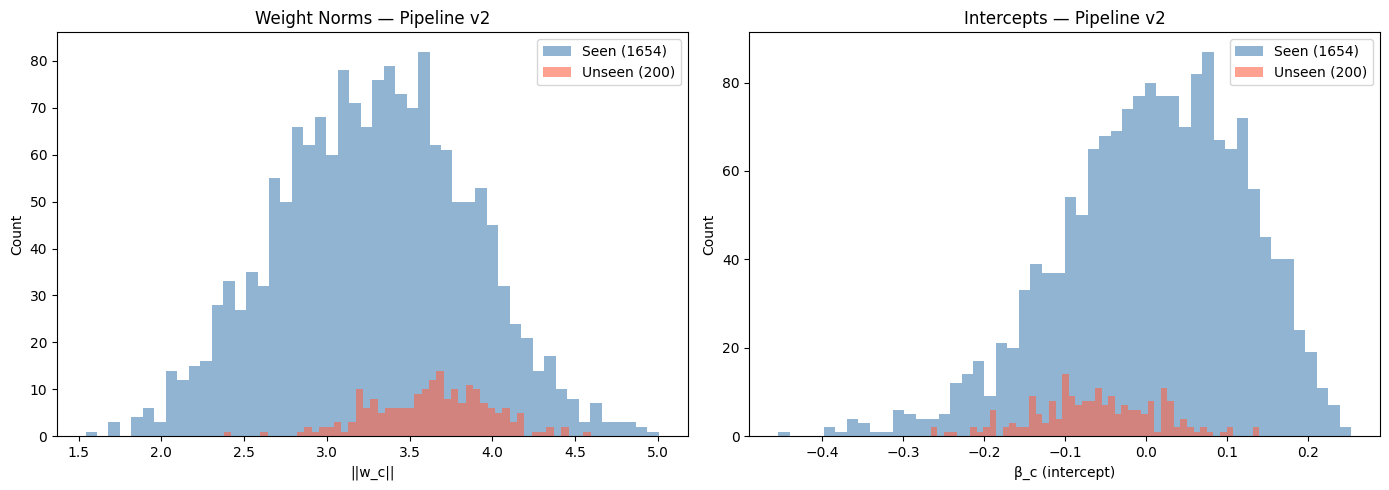

Saved: figures/pipeline_v2_diagnostics.png


In [ ]:
# =============================================================================
# EVALUATE GZSL CLASSIFIER WITH HARNESS
# =============================================================================

# Build label sets from cached arrays
seen_labels_set = set(np.unique(y_train_seen))
unseen_labels_set = set(np.unique(y_synth_unseen))

print(f"Seen labels: {len(seen_labels_set)} classes (range {min(seen_labels_set)}-{max(seen_labels_set)})")
print(f"Unseen labels: {len(unseen_labels_set)} classes (range {min(unseen_labels_set)}-{max(unseen_labels_set)})")
print(f"Overlap: {seen_labels_set & unseen_labels_set}")

# Evaluate with harness
pipeline_results = evaluate_gzsl(
    gzsl_clf, E_test_seen, y_test_seen, E_unseen, y_unseen,
    seen_labels_set, unseen_labels_set, phase_name="Pipeline v2"
)
all_phase_results['Pipeline v2'] = pipeline_results

# Diagnostics
pipeline_diag = diagnose_classifier(
    gzsl_clf, seen_labels_set, unseen_labels_set, phase_name="Pipeline v2"
)

---

# WGAN-GP Synthesis Diagnostics

Three targeted diagnostics to characterise the cWGAN-GP's synthesis quality, guided by pathologies identified in Long et al. (TPAMI 2018):

1. **Per-dimension variance profile** — Does the GAN preserve per-dimension information content, or does it compress/inflate specific dimensions? (Variance decay pathology)
2. **Class-conditional variance** — Does the GAN preserve within-class diversity, or do synthetic samples collapse toward prototypes? (Mode collapse / structural fidelity)
3. **Prototype neighbourhood preservation** — Does the GAN preserve inter-class distance structure, or does it distort the geometry of the embedding space? (Structural discrepancy pathology)

These diagnostics operate on the embeddings already computed by the pipeline above. No retraining is needed.

DIAGNOSTIC 1: Per-Dimension Variance Profile
  Embedding dimension: 128
  Real samples: 13232, Synthetic samples: 4000

  Total variance — Real: 0.999985, Synthetic: 0.991811
  Global variance ratio (synth/real): 0.9918

  Per-dim variance ratio stats:
    Mean: 0.9915, Std: 0.0655
    Min:  0.8506, Max: 1.1277
    Dims where synth < 50% of real:  0/128
    Dims where synth > 150% of real: 0/128
    Dims within 20% of real:         128/128

  Variance profile CV — Real: 0.1819, Synthetic: 0.1938
  (Higher CV = more concentrated information across dimensions)

  Dims for 90% variance — Real: 111/128, Synthetic: 111/128

  Cosine sim to own prototype:
    Real (seen):       mean=0.5889, std=0.1885
    Synthetic (unseen): mean=0.5847, std=0.1666

  Variance decay severity (weighted MAE from 1.0): 0.0542
  (0 = perfect match, higher = more distortion in important dims)


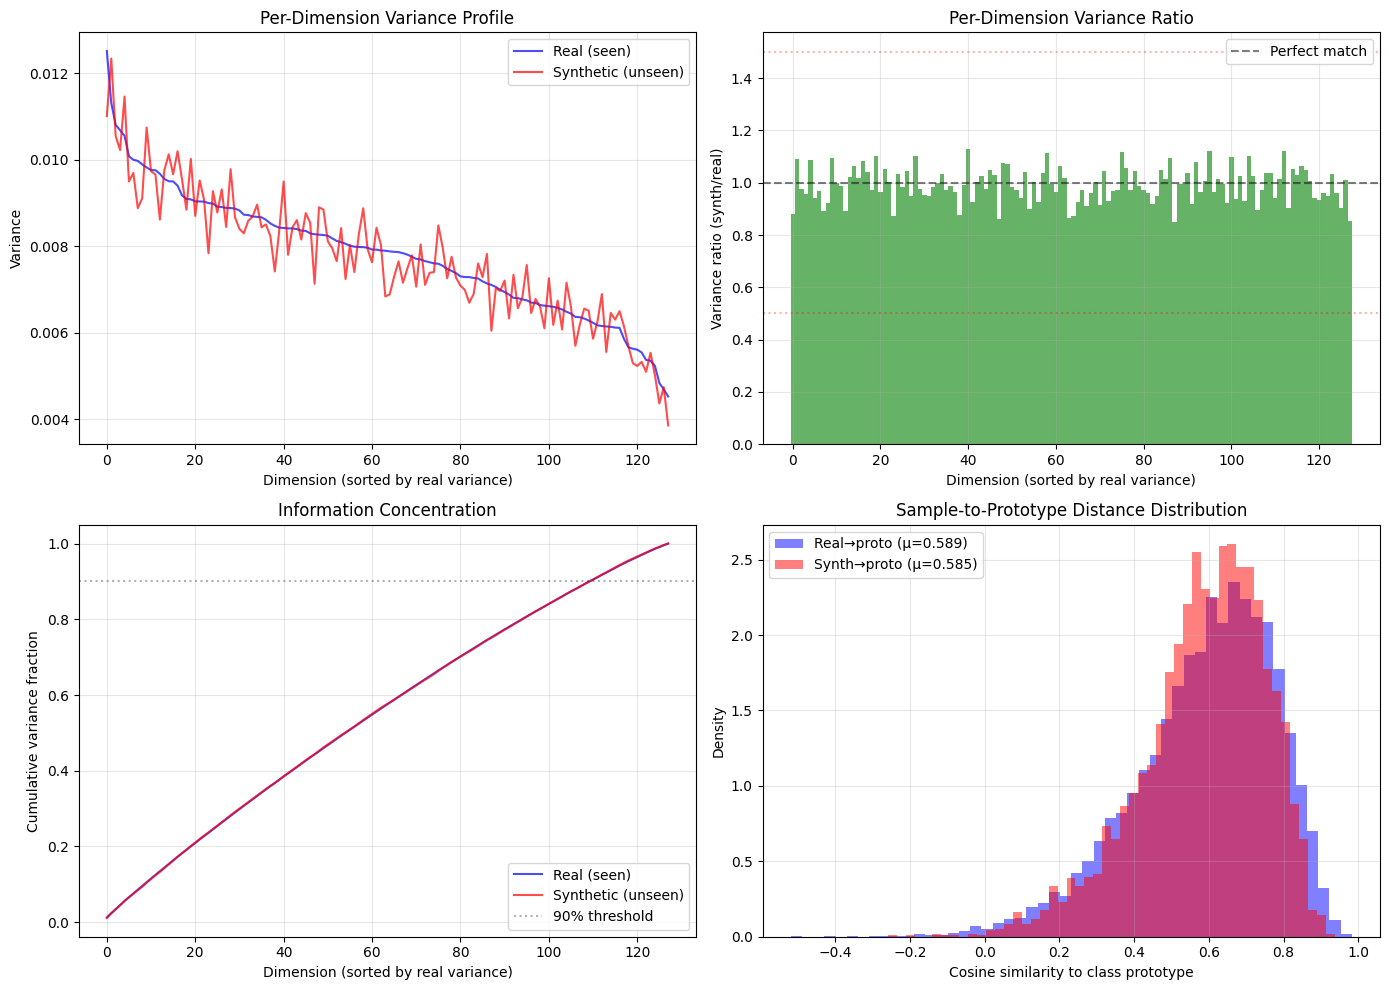


Saved: figures/diag1_variance_profile.png


In [ ]:
# =============================================================================
# DIAGNOSTIC 1: Per-Dimension Variance Profile
# =============================================================================
# Checks for variance decay — whether the GAN preserves per-dimension
# information content from real to synthetic embeddings.
# Reference: Long et al. (TPAMI 2018) Fig. 6 — variance decay pathology
#
# Key question: Does the GAN uniformly reproduce variance across all embedding
# dimensions, or does it compress high-variance dims and inflate low-variance ones?

import numpy as np
import matplotlib.pyplot as plt

d = E_train_seen.shape[1]

# ---- Global per-dimension variance (across all samples) ----
var_real = np.var(E_train_seen, axis=0)       # (d,)
var_synth = np.var(E_synth_unseen, axis=0)    # (d,)

# Sort by real variance (descending) — canonical ordering
sort_idx = np.argsort(var_real)[::-1]
var_real_sorted = var_real[sort_idx]
var_synth_sorted = var_synth[sort_idx]

# Cumulative variance (information concentration)
cumvar_real = np.cumsum(var_real_sorted) / var_real_sorted.sum()
cumvar_synth = np.cumsum(var_synth_sorted) / var_synth_sorted.sum()

# Per-dimension variance ratio
var_ratio = var_synth_sorted / (var_real_sorted + 1e-10)

# ---- Cosine-to-prototype distribution ----
# How far are real/synthetic samples from their class prototypes?
cos_to_proto_real = []
for c in seen_classes:
    mask = y_train_seen == c
    class_embeds = E_train_seen[mask]
    proto = S_seen_array[seen_classes.index(c) if isinstance(seen_classes, list) else np.searchsorted(seen_classes, c)]
    sims = class_embeds @ proto  # cosine sim (both L2-normed)
    cos_to_proto_real.extend(sims)
cos_to_proto_real = np.array(cos_to_proto_real)

cos_to_proto_synth = []
for c in unseen_classes:
    mask = y_synth_unseen == c
    class_embeds = E_synth_unseen[mask]
    proto = S_unseen_array[unseen_classes.index(c) if isinstance(unseen_classes, list) else np.searchsorted(unseen_classes, c)]
    sims = class_embeds @ proto
    cos_to_proto_synth.extend(sims)
cos_to_proto_synth = np.array(cos_to_proto_synth)

# ---- Summary statistics ----
print("=" * 70)
print("DIAGNOSTIC 1: Per-Dimension Variance Profile")
print("=" * 70)
print(f"  Embedding dimension: {d}")
print(f"  Real samples: {E_train_seen.shape[0]}, Synthetic samples: {E_synth_unseen.shape[0]}")
print(f"\n  Total variance — Real: {var_real.sum():.6f}, Synthetic: {var_synth.sum():.6f}")
print(f"  Global variance ratio (synth/real): {var_synth.sum() / var_real.sum():.4f}")
print(f"\n  Per-dim variance ratio stats:")
print(f"    Mean: {var_ratio.mean():.4f}, Std: {var_ratio.std():.4f}")
print(f"    Min:  {var_ratio.min():.4f}, Max: {var_ratio.max():.4f}")
print(f"    Dims where synth < 50% of real:  {(var_ratio < 0.5).sum()}/{d}")
print(f"    Dims where synth > 150% of real: {(var_ratio > 1.5).sum()}/{d}")
print(f"    Dims within 20% of real:         {((var_ratio > 0.8) & (var_ratio < 1.2)).sum()}/{d}")

# Coefficient of variation of variance profile
cv_real = np.std(var_real) / (np.mean(var_real) + 1e-10)
cv_synth = np.std(var_synth) / (np.mean(var_synth) + 1e-10)
print(f"\n  Variance profile CV — Real: {cv_real:.4f}, Synthetic: {cv_synth:.4f}")
print(f"  (Higher CV = more concentrated information across dimensions)")

# Dims needed for 90% variance
dims_90_real = np.searchsorted(cumvar_real, 0.9) + 1
dims_90_synth = np.searchsorted(cumvar_synth, 0.9) + 1
print(f"\n  Dims for 90% variance — Real: {dims_90_real}/{d}, Synthetic: {dims_90_synth}/{d}")

# Cosine-to-prototype stats
print(f"\n  Cosine sim to own prototype:")
print(f"    Real (seen):       mean={cos_to_proto_real.mean():.4f}, std={cos_to_proto_real.std():.4f}")
print(f"    Synthetic (unseen): mean={cos_to_proto_synth.mean():.4f}, std={cos_to_proto_synth.std():.4f}")

# ---- Variance decay severity score ----
# Weighted by real variance magnitude: how much info is lost in top dims?
weights = var_real_sorted / var_real_sorted.sum()
weighted_ratio_dev = np.sum(weights * np.abs(var_ratio - 1.0))
print(f"\n  Variance decay severity (weighted MAE from 1.0): {weighted_ratio_dev:.4f}")
print(f"  (0 = perfect match, higher = more distortion in important dims)")
print("=" * 70)

# ---- Plot ----
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Panel 1: Sorted variance profiles
axes[0, 0].plot(range(d), var_real_sorted, 'b-', alpha=0.7, linewidth=1.5, label='Real (seen)')
axes[0, 0].plot(range(d), var_synth_sorted, 'r-', alpha=0.7, linewidth=1.5, label='Synthetic (unseen)')
axes[0, 0].set_xlabel('Dimension (sorted by real variance)')
axes[0, 0].set_ylabel('Variance')
axes[0, 0].set_title('Per-Dimension Variance Profile')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Panel 2: Variance ratio per dimension
colors = ['green' if 0.8 <= r <= 1.2 else 'orange' if 0.5 <= r <= 1.5 else 'red' for r in var_ratio]
axes[0, 1].bar(range(d), var_ratio, color=colors, alpha=0.6, width=1.0)
axes[0, 1].axhline(y=1.0, color='k', linestyle='--', alpha=0.5, label='Perfect match')
axes[0, 1].axhline(y=0.5, color='r', linestyle=':', alpha=0.3)
axes[0, 1].axhline(y=1.5, color='r', linestyle=':', alpha=0.3)
axes[0, 1].set_xlabel('Dimension (sorted by real variance)')
axes[0, 1].set_ylabel('Variance ratio (synth/real)')
axes[0, 1].set_title('Per-Dimension Variance Ratio')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Panel 3: Cumulative variance
axes[1, 0].plot(range(d), cumvar_real, 'b-', alpha=0.7, linewidth=1.5, label='Real (seen)')
axes[1, 0].plot(range(d), cumvar_synth, 'r-', alpha=0.7, linewidth=1.5, label='Synthetic (unseen)')
axes[1, 0].axhline(y=0.9, color='k', linestyle=':', alpha=0.3, label='90% threshold')
axes[1, 0].set_xlabel('Dimension (sorted by real variance)')
axes[1, 0].set_ylabel('Cumulative variance fraction')
axes[1, 0].set_title('Information Concentration')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# Panel 4: Cosine-to-prototype distribution
axes[1, 1].hist(cos_to_proto_real, bins=50, alpha=0.5, color='blue', density=True,
                label=f'Real→proto (μ={cos_to_proto_real.mean():.3f})')
axes[1, 1].hist(cos_to_proto_synth, bins=50, alpha=0.5, color='red', density=True,
                label=f'Synth→proto (μ={cos_to_proto_synth.mean():.3f})')
axes[1, 1].set_xlabel('Cosine similarity to class prototype')
axes[1, 1].set_ylabel('Density')
axes[1, 1].set_title('Sample-to-Prototype Distance Distribution')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('figures/diag1_variance_profile.png', dpi=150, bbox_inches='tight')
plt.show()
print("\nSaved: figures/diag1_variance_profile.png")

DIAGNOSTIC 2: Class-Conditional Variance
  Real seen classes: 1654 (median 8 samples/class)
  Synthetic unseen classes: 200 (20 samples/class)
  Real unseen classes: 200 (ground truth reference)

  Mean within-class variance (averaged over dims):
    Real seen:       0.004986
    Synthetic unseen: 0.004784
    Real unseen:     0.005480  ← ground truth
    Ratio synth/real_seen:   0.9594
    Ratio synth/real_unseen: 0.8730

  Per-class total variance (trace):
    Real seen:       mean=0.638216, std=0.125509
    Synthetic unseen: mean=0.612301, std=0.073758
    Real unseen:     mean=0.701409, std=0.067972

  Variance decomposition (Total = Within + Between):
    Real seen:       Total=0.999985, Within=0.638216 (63.8%), Between=0.361769 (36.2%)
    Synthetic unseen: Total=0.991811, Within=0.612301 (61.7%), Between=0.379510 (38.3%)

  Within/Between ratio (lower = more discriminable):
    Real seen:       1.7642
    Synthetic unseen: 1.6134

  ✓ Within/Between ratio is in reasonable range.

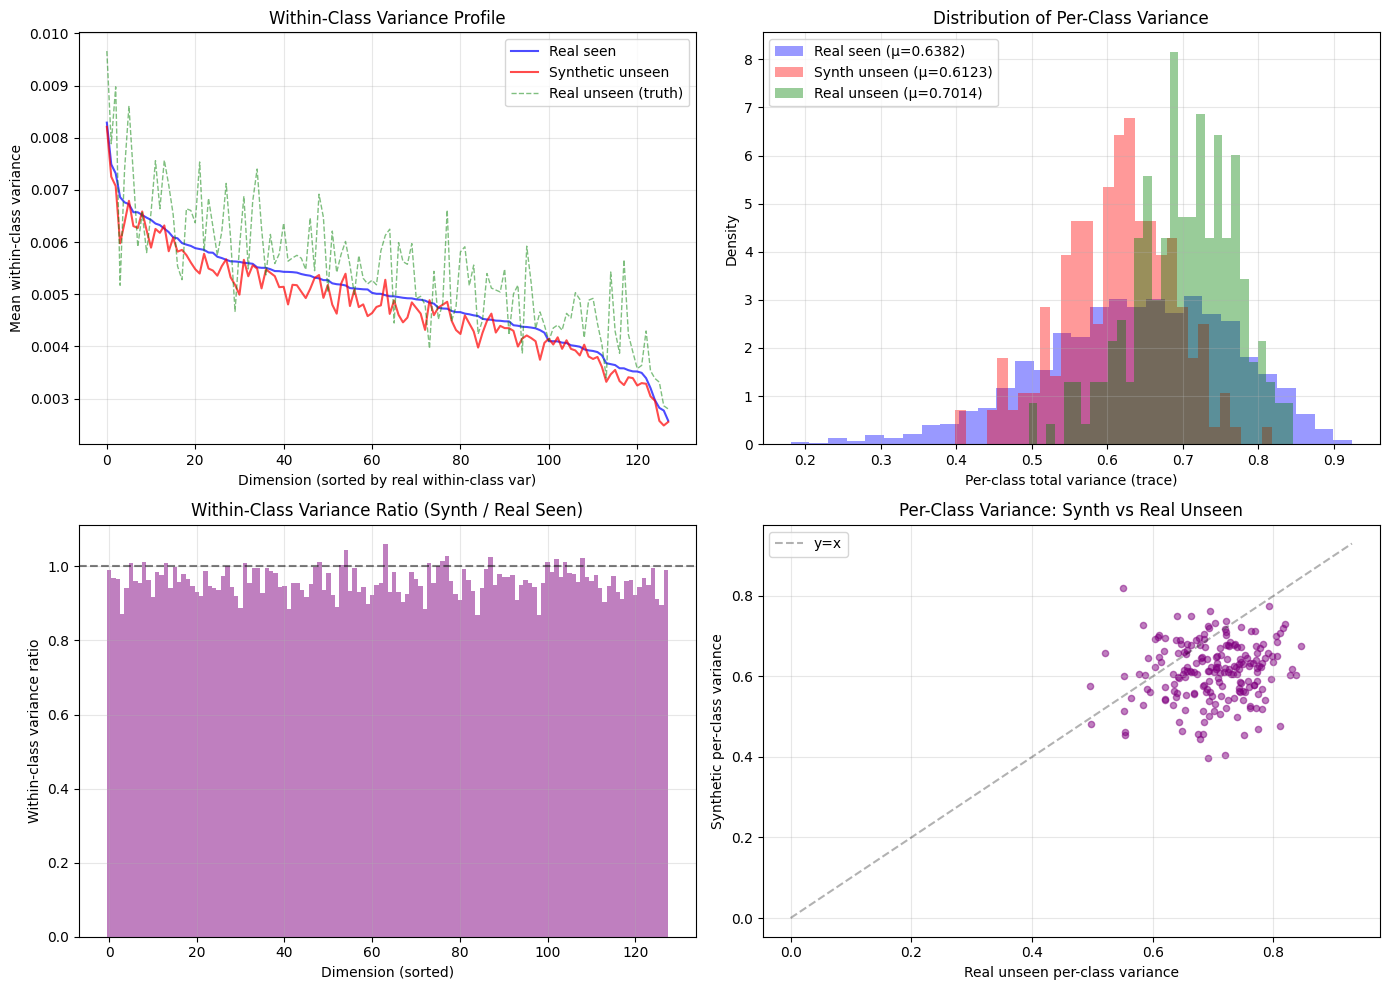


Saved: figures/diag2_class_conditional_variance.png


In [ ]:
# =============================================================================
# DIAGNOSTIC 2: Class-Conditional Variance
# =============================================================================
# Checks whether within-class diversity is preserved by the GAN.
# If the GAN collapses within-class variance (even while matching global variance),
# synthetic embeddings cluster too tightly around prototypes and the classifier
# gets overconfident on unseen classes — exacerbating seen-unseen routing bias.
#
# Key question: Does the GAN generate realistic intra-class spread, or do
# synthetic samples collapse toward their conditioning prototype?

import numpy as np
import matplotlib.pyplot as plt

d = E_train_seen.shape[1]

# ---- Real seen: within-class per-dim variance ----
real_class_variances = []
real_class_sizes = []
for c in seen_classes:
    mask = y_train_seen == c
    class_embeds = E_train_seen[mask]
    if len(class_embeds) > 1:
        real_class_variances.append(np.var(class_embeds, axis=0))
        real_class_sizes.append(len(class_embeds))
real_class_variances = np.array(real_class_variances)  # (n_seen, d)
mean_real_class_var = real_class_variances.mean(axis=0)  # (d,)

# ---- Synthetic unseen: within-class per-dim variance ----
synth_class_variances = []
synth_class_sizes = []
for c in unseen_classes:
    mask = y_synth_unseen == c
    class_embeds = E_synth_unseen[mask]
    if len(class_embeds) > 1:
        synth_class_variances.append(np.var(class_embeds, axis=0))
        synth_class_sizes.append(len(class_embeds))
synth_class_variances = np.array(synth_class_variances)  # (n_unseen, d)
mean_synth_class_var = synth_class_variances.mean(axis=0)  # (d,)

# ---- Per-class total variance (trace of covariance) ----
real_total_var = real_class_variances.sum(axis=1)      # (n_seen,)
synth_total_var = synth_class_variances.sum(axis=1)    # (n_unseen,)

# ---- Variance decomposition (ANOVA-style) ----
# Total = Within-class + Between-class
# Real seen
global_mean_real = E_train_seen.mean(axis=0)
total_var_real = np.var(E_train_seen, axis=0).sum()
within_var_real = mean_real_class_var.sum()
between_var_real = total_var_real - within_var_real

# Synthetic unseen
global_mean_synth = E_synth_unseen.mean(axis=0)
total_var_synth = np.var(E_synth_unseen, axis=0).sum()
within_var_synth = mean_synth_class_var.sum()
between_var_synth = total_var_synth - within_var_synth

# ---- Also check real UNSEEN (E_unseen with y_unseen) for ground truth ----
real_unseen_class_variances = []
for c in unseen_classes:
    mask = y_unseen == c
    class_embeds = E_unseen[mask]
    if len(class_embeds) > 1:
        real_unseen_class_variances.append(np.var(class_embeds, axis=0))
real_unseen_class_variances = np.array(real_unseen_class_variances)
mean_real_unseen_class_var = real_unseen_class_variances.mean(axis=0)
real_unseen_total_var = real_unseen_class_variances.sum(axis=1)

# ---- Summary ----
print("=" * 70)
print("DIAGNOSTIC 2: Class-Conditional Variance")
print("=" * 70)
print(f"  Real seen classes: {len(real_class_variances)} (median {np.median(real_class_sizes):.0f} samples/class)")
print(f"  Synthetic unseen classes: {len(synth_class_variances)} ({synth_class_sizes[0]} samples/class)")
print(f"  Real unseen classes: {len(real_unseen_class_variances)} (ground truth reference)")

print(f"\n  Mean within-class variance (averaged over dims):")
print(f"    Real seen:       {mean_real_class_var.mean():.6f}")
print(f"    Synthetic unseen: {mean_synth_class_var.mean():.6f}")
print(f"    Real unseen:     {mean_real_unseen_class_var.mean():.6f}  ← ground truth")
print(f"    Ratio synth/real_seen:   {mean_synth_class_var.mean() / (mean_real_class_var.mean() + 1e-10):.4f}")
print(f"    Ratio synth/real_unseen: {mean_synth_class_var.mean() / (mean_real_unseen_class_var.mean() + 1e-10):.4f}")

print(f"\n  Per-class total variance (trace):")
print(f"    Real seen:       mean={real_total_var.mean():.6f}, std={real_total_var.std():.6f}")
print(f"    Synthetic unseen: mean={synth_total_var.mean():.6f}, std={synth_total_var.std():.6f}")
print(f"    Real unseen:     mean={real_unseen_total_var.mean():.6f}, std={real_unseen_total_var.std():.6f}")

print(f"\n  Variance decomposition (Total = Within + Between):")
print(f"    Real seen:       Total={total_var_real:.6f}, Within={within_var_real:.6f} ({100*within_var_real/total_var_real:.1f}%), Between={between_var_real:.6f} ({100*between_var_real/total_var_real:.1f}%)")
print(f"    Synthetic unseen: Total={total_var_synth:.6f}, Within={within_var_synth:.6f} ({100*within_var_synth/total_var_synth:.1f}%), Between={between_var_synth:.6f} ({100*between_var_synth/total_var_synth:.1f}%)")

# Within/Between ratio — higher = less discriminable
wb_ratio_real = within_var_real / (between_var_real + 1e-10)
wb_ratio_synth = within_var_synth / (between_var_synth + 1e-10)
print(f"\n  Within/Between ratio (lower = more discriminable):")
print(f"    Real seen:       {wb_ratio_real:.4f}")
print(f"    Synthetic unseen: {wb_ratio_synth:.4f}")

if wb_ratio_synth < wb_ratio_real * 0.5:
    print("\n  ⚠ WARNING: Synthetic within-class variance is disproportionately low.")
    print("    The GAN may be collapsing toward prototypes (mode collapse lite).")
elif wb_ratio_synth > wb_ratio_real * 2.0:
    print("\n  ⚠ WARNING: Synthetic within-class variance is disproportionately high.")
    print("    The GAN may be generating noisy/unfocused embeddings.")
else:
    print("\n  ✓ Within/Between ratio is in reasonable range.")
print("=" * 70)

# ---- Plot ----
sort_idx = np.argsort(mean_real_class_var)[::-1]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Panel 1: Mean within-class variance per dimension
axes[0, 0].plot(range(d), mean_real_class_var[sort_idx], 'b-', alpha=0.7, linewidth=1.5, label='Real seen')
axes[0, 0].plot(range(d), mean_synth_class_var[sort_idx], 'r-', alpha=0.7, linewidth=1.5, label='Synthetic unseen')
axes[0, 0].plot(range(d), mean_real_unseen_class_var[sort_idx], 'g--', alpha=0.5, linewidth=1.0, label='Real unseen (truth)')
axes[0, 0].set_xlabel('Dimension (sorted by real within-class var)')
axes[0, 0].set_ylabel('Mean within-class variance')
axes[0, 0].set_title('Within-Class Variance Profile')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Panel 2: Distribution of per-class total variance
axes[0, 1].hist(real_total_var, bins=30, alpha=0.4, color='blue', density=True,
                label=f'Real seen (μ={real_total_var.mean():.4f})')
axes[0, 1].hist(synth_total_var, bins=30, alpha=0.4, color='red', density=True,
                label=f'Synth unseen (μ={synth_total_var.mean():.4f})')
axes[0, 1].hist(real_unseen_total_var, bins=30, alpha=0.4, color='green', density=True,
                label=f'Real unseen (μ={real_unseen_total_var.mean():.4f})')
axes[0, 1].set_xlabel('Per-class total variance (trace)')
axes[0, 1].set_ylabel('Density')
axes[0, 1].set_title('Distribution of Per-Class Variance')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Panel 3: Within-class variance ratio per dimension (synth/real)
class_var_ratio = mean_synth_class_var / (mean_real_class_var + 1e-10)
class_var_ratio_unseen = mean_synth_class_var / (mean_real_unseen_class_var + 1e-10)
axes[1, 0].bar(range(d), class_var_ratio[sort_idx], color='purple', alpha=0.5, width=1.0, label='Synth/Real seen')
axes[1, 0].axhline(y=1.0, color='k', linestyle='--', alpha=0.5)
axes[1, 0].set_xlabel('Dimension (sorted)')
axes[1, 0].set_ylabel('Within-class variance ratio')
axes[1, 0].set_title('Within-Class Variance Ratio (Synth / Real Seen)')
axes[1, 0].grid(True, alpha=0.3)

# Panel 4: Scatter — per-class total variance (synth vs real unseen ground truth)
# Each point = one unseen class. x = real unseen variance, y = synthetic variance
axes[1, 1].scatter(real_unseen_total_var, synth_total_var, alpha=0.5, s=20, color='purple')
lim = max(real_unseen_total_var.max(), synth_total_var.max()) * 1.1
axes[1, 1].plot([0, lim], [0, lim], 'k--', alpha=0.3, label='y=x')
axes[1, 1].set_xlabel('Real unseen per-class variance')
axes[1, 1].set_ylabel('Synthetic per-class variance')
axes[1, 1].set_title('Per-Class Variance: Synth vs Real Unseen')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('figures/diag2_class_conditional_variance.png', dpi=150, bbox_inches='tight')
plt.show()
print("\nSaved: figures/diag2_class_conditional_variance.png")

DIAGNOSTIC 3: Prototype Neighbourhood Preservation

  Pairwise distance correlations (19900 pairs):
                                             Spearman ρ    Pearson r
  ────────────────────────────────────────────────────────────────
  Synth centroids vs Image prototypes            0.8937       0.9013
  Real unseen centroids vs Image protos          0.6661       0.6785  ← ground truth
  Synth centroids vs Real unseen centroids       0.6113       0.6243  ← direct quality
  Seen: Real centroids vs Image protos           0.9904       0.9916  ← seen reference

  Neighbourhood preservation gap:
    Δ Spearman (synth − real_unseen): 0.2276

  k-NN preservation rate:
     k     Synth↔Proto   RealUnseen↔Proto   Seen ref
  ──────────────────────────────────────────────────
     5          0.5840             0.3410     0.8850
    10          0.6240             0.4150     0.8930
    20          0.7005             0.4938     0.9150
    50          0.7762             0.6126     0.9358
  Random ba

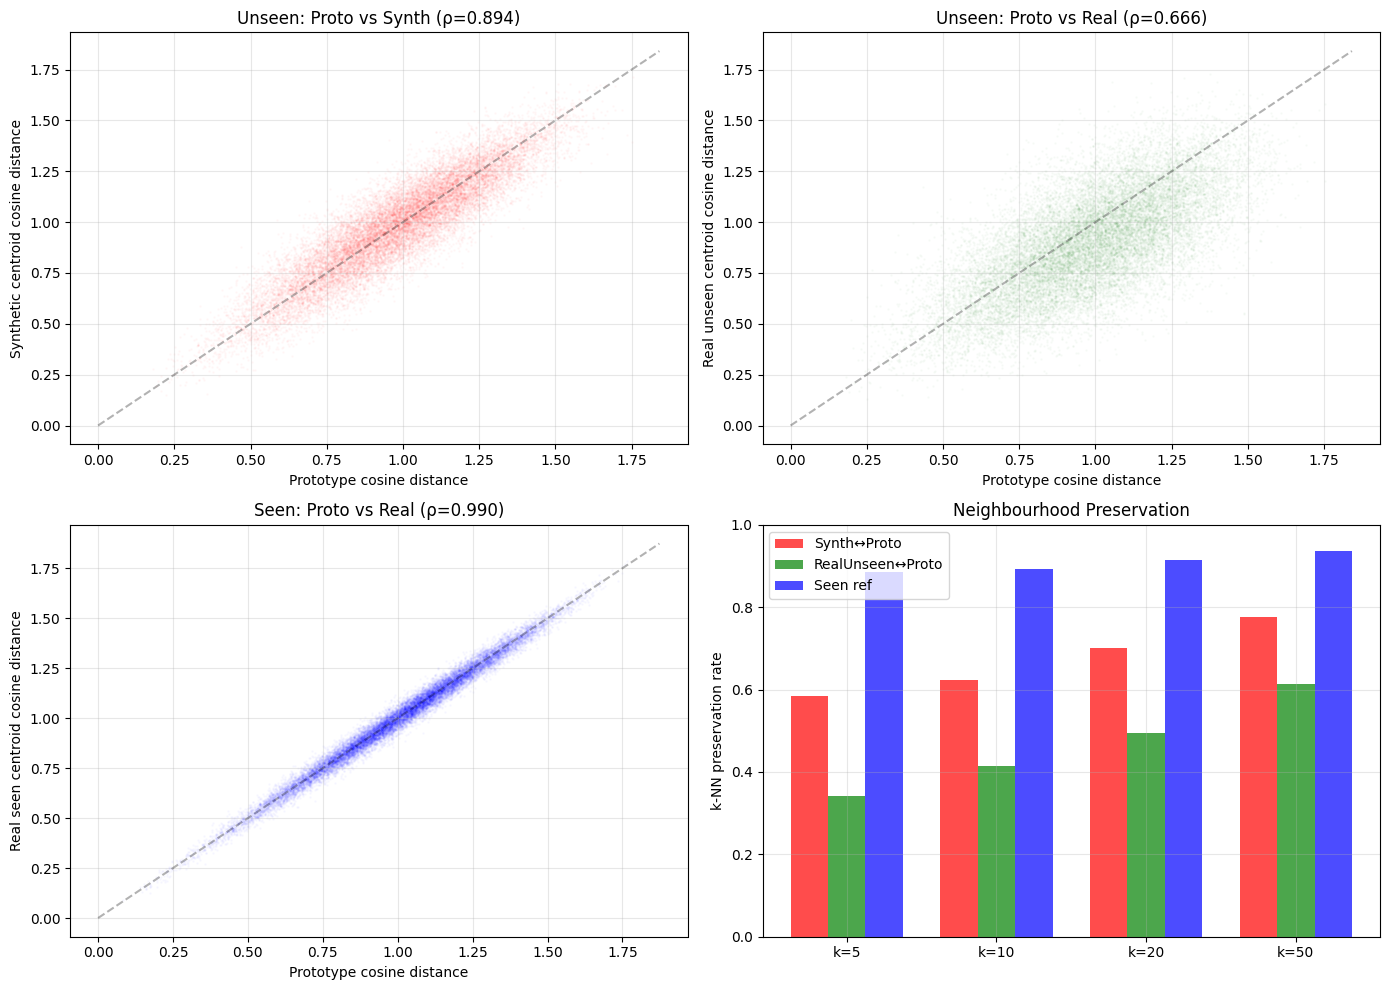


Saved: figures/diag3_neighbourhood_preservation.png


In [ ]:
# =============================================================================
# DIAGNOSTIC 3: Prototype Neighbourhood Preservation
# =============================================================================
# Checks whether inter-class distances in prototype space are preserved
# in synthetic embedding space. If the GAN distorts neighbourhood structure,
# the classifier will have wrong decision boundaries for unseen classes.
#
# Three tests:
#   1. Pairwise distance correlation (Spearman ρ) — ordinal structure
#   2. k-NN preservation rate — local neighbourhood fidelity
#   3. Seen reference — same metrics on real data (upper bound)
#
# Key question: When the GAN generates embeddings conditioned on prototype s_c,
# does the distance between synthetic clusters reflect the distance between
# conditioning prototypes?

import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial.distance import pdist, squareform
from scipy.stats import spearmanr, pearsonr

# ---- Unseen: prototype distances vs synthetic centroid distances ----
proto_dists_unseen = squareform(pdist(S_unseen_array, metric='cosine'))  # (200, 200)

# Synthetic centroids (mean of synthetic embeddings per class, then L2-norm)
synth_centroids = []
for c in unseen_classes:
    mask = y_synth_unseen == c
    centroid = E_synth_unseen[mask].mean(axis=0)
    centroid = centroid / (np.linalg.norm(centroid) + 1e-8)
    synth_centroids.append(centroid)
synth_centroids = np.array(synth_centroids)
synth_dists = squareform(pdist(synth_centroids, metric='cosine'))  # (200, 200)

# Also compute real unseen brain embedding centroids (ground truth)
real_unseen_centroids = []
for c in unseen_classes:
    mask = y_unseen == c
    centroid = E_unseen[mask].mean(axis=0)
    centroid = centroid / (np.linalg.norm(centroid) + 1e-8)
    real_unseen_centroids.append(centroid)
real_unseen_centroids = np.array(real_unseen_centroids)
real_unseen_dists = squareform(pdist(real_unseen_centroids, metric='cosine'))

# Flatten upper triangles
triu_idx = np.triu_indices(len(unseen_classes), k=1)
proto_flat = proto_dists_unseen[triu_idx]
synth_flat = synth_dists[triu_idx]
real_unseen_flat = real_unseen_dists[triu_idx]

# Correlations: synth vs proto
sp_synth_proto, sp_synth_proto_p = spearmanr(proto_flat, synth_flat)
pr_synth_proto, pr_synth_proto_p = pearsonr(proto_flat, synth_flat)

# Correlations: real unseen vs proto (ground truth upper bound)
sp_real_proto, _ = spearmanr(proto_flat, real_unseen_flat)
pr_real_proto, _ = pearsonr(proto_flat, real_unseen_flat)

# Correlations: synth vs real unseen (direct quality measure)
sp_synth_real, _ = spearmanr(real_unseen_flat, synth_flat)
pr_synth_real, _ = pearsonr(real_unseen_flat, synth_flat)

# ---- Seen reference: real centroids vs prototypes ----
real_seen_centroids = []
for c in seen_classes:
    mask = y_train_seen == c
    centroid = E_train_seen[mask].mean(axis=0)
    centroid = centroid / (np.linalg.norm(centroid) + 1e-8)
    real_seen_centroids.append(centroid)
real_seen_centroids = np.array(real_seen_centroids)

# Subsample 200 seen classes for fair comparison
rng = np.random.RandomState(42)
n_sub = min(200, len(seen_classes))
sub_idx = rng.choice(len(seen_classes), size=n_sub, replace=False)
proto_dists_seen_sub = squareform(pdist(S_seen_array[sub_idx], metric='cosine'))
real_dists_seen_sub = squareform(pdist(real_seen_centroids[sub_idx], metric='cosine'))
triu_seen = np.triu_indices(n_sub, k=1)
proto_flat_seen = proto_dists_seen_sub[triu_seen]
real_flat_seen = real_dists_seen_sub[triu_seen]
sp_seen_ref, _ = spearmanr(proto_flat_seen, real_flat_seen)
pr_seen_ref, _ = pearsonr(proto_flat_seen, real_flat_seen)

# ---- k-NN preservation ----
k_values = [5, 10, 20, 50]
knn_synth = {}
knn_real_unseen = {}
knn_seen_ref = {}

for k in k_values:
    # Synth vs proto (unseen)
    matches_s = 0
    # Real unseen vs proto
    matches_r = 0
    for i in range(len(unseen_classes)):
        proto_nn = set(np.argsort(proto_dists_unseen[i])[1:k+1])
        synth_nn = set(np.argsort(synth_dists[i])[1:k+1])
        real_nn = set(np.argsort(real_unseen_dists[i])[1:k+1])
        matches_s += len(proto_nn & synth_nn)
        matches_r += len(proto_nn & real_nn)
    knn_synth[k] = matches_s / (len(unseen_classes) * k)
    knn_real_unseen[k] = matches_r / (len(unseen_classes) * k)

    # Seen reference
    matches_seen = 0
    for i in range(n_sub):
        proto_nn = set(np.argsort(proto_dists_seen_sub[i])[1:k+1])
        real_nn = set(np.argsort(real_dists_seen_sub[i])[1:k+1])
        matches_seen += len(proto_nn & real_nn)
    knn_seen_ref[k] = matches_seen / (n_sub * k)

# ---- Summary ----
print("=" * 70)
print("DIAGNOSTIC 3: Prototype Neighbourhood Preservation")
print("=" * 70)

print(f"\n  Pairwise distance correlations ({len(proto_flat)} pairs):")
print(f"  {'':40s} {'Spearman ρ':>12s} {'Pearson r':>12s}")
print(f"  {'─' * 64}")
print(f"  {'Synth centroids vs Image prototypes':40s} {sp_synth_proto:12.4f} {pr_synth_proto:12.4f}")
print(f"  {'Real unseen centroids vs Image protos':40s} {sp_real_proto:12.4f} {pr_real_proto:12.4f}  ← ground truth")
print(f"  {'Synth centroids vs Real unseen centroids':40s} {sp_synth_real:12.4f} {pr_synth_real:12.4f}  ← direct quality")
print(f"  {'Seen: Real centroids vs Image protos':40s} {sp_seen_ref:12.4f} {pr_seen_ref:12.4f}  ← seen reference")

print(f"\n  Neighbourhood preservation gap:")
print(f"    Δ Spearman (synth − real_unseen): {sp_synth_proto - sp_real_proto:.4f}")

print(f"\n  k-NN preservation rate:")
print(f"  {'k':>4s}  {'Synth↔Proto':>14s} {'RealUnseen↔Proto':>18s} {'Seen ref':>10s}")
print(f"  {'─' * 50}")
for k in k_values:
    print(f"  {k:4d}  {knn_synth[k]:14.4f} {knn_real_unseen[k]:18.4f} {knn_seen_ref[k]:10.4f}")

# Random baseline for k-NN preservation
for k in k_values:
    random_baseline = k / (len(unseen_classes) - 1)
    print(f"  Random baseline for k={k}: {random_baseline:.4f}")

print("=" * 70)

# ---- Plot ----
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Panel 1: Scatter — proto dist vs synth dist (unseen)
axes[0, 0].scatter(proto_flat, synth_flat, alpha=0.02, s=1, color='red', rasterized=True)
lims = [0, max(proto_flat.max(), synth_flat.max()) * 1.05]
axes[0, 0].plot(lims, lims, 'k--', alpha=0.3)
axes[0, 0].set_xlabel('Prototype cosine distance')
axes[0, 0].set_ylabel('Synthetic centroid cosine distance')
axes[0, 0].set_title(f'Unseen: Proto vs Synth (ρ={sp_synth_proto:.3f})')
axes[0, 0].grid(True, alpha=0.3)

# Panel 2: Scatter — proto dist vs real unseen dist (ground truth)
axes[0, 1].scatter(proto_flat, real_unseen_flat, alpha=0.02, s=1, color='green', rasterized=True)
lims = [0, max(proto_flat.max(), real_unseen_flat.max()) * 1.05]
axes[0, 1].plot(lims, lims, 'k--', alpha=0.3)
axes[0, 1].set_xlabel('Prototype cosine distance')
axes[0, 1].set_ylabel('Real unseen centroid cosine distance')
axes[0, 1].set_title(f'Unseen: Proto vs Real (ρ={sp_real_proto:.3f})')
axes[0, 1].grid(True, alpha=0.3)

# Panel 3: Scatter — seen reference
axes[1, 0].scatter(proto_flat_seen, real_flat_seen, alpha=0.02, s=1, color='blue', rasterized=True)
lims = [0, max(proto_flat_seen.max(), real_flat_seen.max()) * 1.05]
axes[1, 0].plot(lims, lims, 'k--', alpha=0.3)
axes[1, 0].set_xlabel('Prototype cosine distance')
axes[1, 0].set_ylabel('Real seen centroid cosine distance')
axes[1, 0].set_title(f'Seen: Proto vs Real (ρ={sp_seen_ref:.3f})')
axes[1, 0].grid(True, alpha=0.3)

# Panel 4: k-NN preservation grouped bar chart
x = np.arange(len(k_values))
width = 0.25
bars1 = axes[1, 1].bar(x - width, [knn_synth[k] for k in k_values], width,
                         alpha=0.7, color='red', label='Synth↔Proto')
bars2 = axes[1, 1].bar(x, [knn_real_unseen[k] for k in k_values], width,
                         alpha=0.7, color='green', label='RealUnseen↔Proto')
bars3 = axes[1, 1].bar(x + width, [knn_seen_ref[k] for k in k_values], width,
                         alpha=0.7, color='blue', label='Seen ref')
axes[1, 1].set_xticks(x)
axes[1, 1].set_xticklabels([f'k={k}' for k in k_values])
axes[1, 1].set_ylabel('k-NN preservation rate')
axes[1, 1].set_title('Neighbourhood Preservation')
axes[1, 1].set_ylim(0, 1)
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('figures/diag3_neighbourhood_preservation.png', dpi=150, bbox_inches='tight')
plt.show()
print("\nSaved: figures/diag3_neighbourhood_preservation.png")

---

# Noise-Augmented Prototype Conditioning: eta Sweep

**Motivation**: Diagnostic 3 revealed that synthetic embeddings preserve prototype geometry
too faithfully (Spearman rho=0.893) compared to real unseen brain embeddings (rho=0.668).
The classifier trains on geometrically "too clean" synthetic data, causing a structural
mismatch at test time.

**Mechanism**: Perturb unseen prototypes during synthesis with calibrated Gaussian noise:
```
s_tilde = normalize(s_c + eta * xi),  xi ~ N(0, I_d)
```
Each synthetic sample gets an independent perturbation, simultaneously:
1. Degrading inter-class geometric fidelity (rho toward 0.668)
2. Increasing within-class variance (each sample conditioned on a slightly different point)

**Strategy**: Train encoder + WGAN-GP once with optimal config (embed_dim=64, tau=0.05).
Then sweep eta on synthesis only (~30s per eta value). The generator's learned smooth
mapping means perturbed inputs produce well-behaved outputs.

In [ ]:
# =============================================================================
# OPTIMAL CONFIG + PERTURBATION UTILITIES
# =============================================================================

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from scipy.spatial.distance import pdist, squareform
from scipy.stats import spearmanr
import matplotlib.pyplot as plt
import math
import gc

# ---- Optimal config (validated by sweep + dim sweep) ----
OPT_ENCODER_CONFIG = {
    'embed_dim': 64,
    'image_input_dim': 1000,
    'tau': 0.05,
    'epochs': 75,
    'batch_size': 256,
    'lr': 2e-3,
    'weight_decay': 1e-4,
    'dropout': 0.1,
    'warmup_ratio': 0.1,
    'seed': 42,
}

OPT_WGAN_CONFIG = {
    'z_dim': 100,
    'embed_dim': 64,
    'lr': 1e-4,
    'betas': (0.0, 0.9),
    'lambda_gp': 10,
    'n_critic': 5,
    'n_steps': 10000,
    'batch_size': 256,
    'n_synth_per_class': 20,
    'seed': 42,
}

# Dense sweep near small eta + wider coverage
ETA_VALUES = [0.0, 0.02, 0.05, 0.07, 0.10, 0.15, 0.20, 0.25]

SEED = 42

print("=" * 60)
print("NOISE-AUGMENTED PROTOTYPE CONDITIONING")
print("=" * 60)
print(f"  Encoder: embed_dim={OPT_ENCODER_CONFIG['embed_dim']}, tau={OPT_ENCODER_CONFIG['tau']}, "
      f"epochs={OPT_ENCODER_CONFIG['epochs']}, lr={OPT_ENCODER_CONFIG['lr']}")
print(f"  WGAN: z_dim={OPT_WGAN_CONFIG['z_dim']}, steps={OPT_WGAN_CONFIG['n_steps']}, "
      f"n_synth={OPT_WGAN_CONFIG['n_synth_per_class']}")
print(f"  eta sweep: {ETA_VALUES}")
d = OPT_ENCODER_CONFIG['embed_dim']
print(f"\n  Expected angular deviations (d={d}):")
for eta in ETA_VALUES:
    if eta == 0:
        print(f"    eta={eta:.2f}: no perturbation (baseline)")
    else:
        cos_theta = 1.0 / math.sqrt(1 + eta**2 * (d - 1))
        angle = math.degrees(math.acos(cos_theta))
        print(f"    eta={eta:.2f}: E[cos theta]={cos_theta:.3f}, angle~{angle:.1f} deg")
print("=" * 60)


# ---- Perturbation function ----
def perturb_prototype(s_c, eta, device):
    """
    Apply Gaussian perturbation to prototype and renormalize to unit sphere.
    s_c: (n, d) tensor of prototypes
    eta: perturbation magnitude (0 = no perturbation)
    Returns: (n, d) tensor on unit sphere
    """
    if eta == 0 or eta is None:
        return s_c
    xi = torch.randn_like(s_c, device=device)
    s_perturbed = s_c + eta * xi
    return F.normalize(s_perturbed, p=2, dim=-1)


# ---- Synthesis with perturbation ----
def synthesise_with_eta(generator, unseen_classes, S_unseen_protos, n_synth, z_dim, eta, device):
    """
    Generate synthetic unseen embeddings with noise-augmented prototype conditioning.
    Each of n_synth samples per class gets an independent perturbation xi_k.
    When eta=0, reproduces original synthesis exactly.
    """
    torch.manual_seed(SEED)
    np.random.seed(SEED)
    generator.eval()
    synth_embeddings = []
    synth_labels = []

    with torch.no_grad():
        for c in unseen_classes:
            s_c = torch.FloatTensor(S_unseen_protos[c]).unsqueeze(0).repeat(n_synth, 1).to(device)
            # Apply per-sample perturbation
            s_c_perturbed = perturb_prototype(s_c, eta, device)
            z = torch.randn(n_synth, z_dim, device=device)
            e_synth = generator(z, s_c_perturbed).cpu().numpy()
            synth_embeddings.append(e_synth)
            synth_labels.extend([c] * n_synth)

    E_synth = np.vstack(synth_embeddings)
    y_synth = np.array(synth_labels)
    return E_synth, y_synth


# ---- Diagnostic metrics ----
def compute_sweep_diagnostics(E_synth, y_synth, E_unseen, y_unseen,
                               S_unseen_array, unseen_classes):
    """
    Compute diagnostic metrics for one eta value.
    Returns dict with rho_synth_proto, rho_synth_real, knn_10, var_ratio.
    """
    n_classes = len(unseen_classes)

    # Synth centroids
    synth_centroids = []
    synth_class_vars = []
    for c in unseen_classes:
        mask = y_synth == c
        embeds = E_synth[mask]
        centroid = embeds.mean(axis=0)
        centroid = centroid / (np.linalg.norm(centroid) + 1e-8)
        synth_centroids.append(centroid)
        if len(embeds) > 1:
            synth_class_vars.append(np.var(embeds, axis=0).sum())
    synth_centroids = np.array(synth_centroids)

    # Real unseen centroids
    real_centroids = []
    real_class_vars = []
    for c in unseen_classes:
        mask = y_unseen == c
        embeds = E_unseen[mask]
        centroid = embeds.mean(axis=0)
        centroid = centroid / (np.linalg.norm(centroid) + 1e-8)
        real_centroids.append(centroid)
        if len(embeds) > 1:
            real_class_vars.append(np.var(embeds, axis=0).sum())
    real_centroids = np.array(real_centroids)

    # Pairwise distances
    proto_dists = squareform(pdist(S_unseen_array, metric='cosine'))
    synth_dists = squareform(pdist(synth_centroids, metric='cosine'))
    real_dists = squareform(pdist(real_centroids, metric='cosine'))

    triu = np.triu_indices(n_classes, k=1)
    proto_flat = proto_dists[triu]
    synth_flat = synth_dists[triu]
    real_flat = real_dists[triu]

    rho_synth_proto, _ = spearmanr(proto_flat, synth_flat)
    rho_synth_real, _ = spearmanr(real_flat, synth_flat)
    rho_real_proto, _ = spearmanr(proto_flat, real_flat)

    # k-NN preservation at k=10
    k = 10
    matches = 0
    for i in range(n_classes):
        proto_nn = set(np.argsort(proto_dists[i])[1:k+1])
        synth_nn = set(np.argsort(synth_dists[i])[1:k+1])
        matches += len(proto_nn & synth_nn)
    knn_10 = matches / (n_classes * k)

    # Within-class variance ratio (synth / real unseen)
    mean_synth_var = np.mean(synth_class_vars) if synth_class_vars else 0
    mean_real_var = np.mean(real_class_vars) if real_class_vars else 1
    var_ratio = mean_synth_var / (mean_real_var + 1e-10)

    return {
        'rho_synth_proto': rho_synth_proto,
        'rho_synth_real': rho_synth_real,
        'rho_real_proto': rho_real_proto,
        'knn_10': knn_10,
        'var_ratio': var_ratio,
        'mean_synth_var': mean_synth_var,
        'mean_real_var': mean_real_var,
    }


# ---- Full evaluation for one eta ----
def evaluate_eta(eta, generator, E_train, y_train, E_test, y_test,
                 E_unseen, y_unseen, S_unseen_protos, S_unseen_array,
                 unseen_classes, seen_labels_set, unseen_labels_set,
                 median_per_class, device):
    """
    Full pipeline for one eta: synthesise -> balance -> classify -> evaluate -> diagnose.
    """
    z_dim = OPT_WGAN_CONFIG['z_dim']
    n_synth = OPT_WGAN_CONFIG['n_synth_per_class']

    # 1. Synthesise with perturbation
    E_synth, y_synth = synthesise_with_eta(
        generator, unseen_classes, S_unseen_protos, n_synth, z_dim, eta, device)

    # 2. Sample balance: downsample to median_per_class
    rng = np.random.RandomState(SEED)
    ds_indices = []
    for c in unseen_classes:
        idx = np.where(y_synth == c)[0]
        if len(idx) > median_per_class:
            selected = rng.choice(idx, size=median_per_class, replace=False)
        else:
            selected = idx
        ds_indices.append(selected)
    ds_indices = np.concatenate(ds_indices)
    E_synth_ds = E_synth[ds_indices]
    y_synth_ds = y_synth[ds_indices]

    # 3. Combine + train classifier
    X_train_gzsl = np.vstack([E_train, E_synth_ds])
    y_train_gzsl = np.concatenate([y_train, y_synth_ds])

    clf = LogisticRegression(
        multi_class='multinomial', solver='lbfgs', max_iter=1000,
        class_weight='balanced', random_state=SEED, n_jobs=-1)
    clf.fit(X_train_gzsl, y_train_gzsl)

    # 4. GZSL evaluation
    pred_seen = clf.predict(E_test)
    pred_unseen = clf.predict(E_unseen)
    acc_seen = accuracy_score(y_test, pred_seen)
    acc_unseen = accuracy_score(y_unseen, pred_unseen)
    H = 2 * acc_seen * acc_unseen / (acc_seen + acc_unseen) if (acc_seen + acc_unseen) > 0 else 0.0

    seen_as_unseen = np.isin(pred_seen, list(unseen_labels_set)).sum()
    routing_rate = seen_as_unseen / len(pred_seen)

    # 5. Diagnostic metrics
    diag = compute_sweep_diagnostics(
        E_synth, y_synth, E_unseen, y_unseen, S_unseen_array, unseen_classes)

    return {
        'eta': eta,
        'acc_seen': acc_seen,
        'acc_unseen': acc_unseen,
        'H': H,
        'routing_rate': routing_rate,
        'n_synth_ds': len(E_synth_ds),
        **diag,
    }


print("Utility functions defined: perturb_prototype, synthesise_with_eta, "
      "compute_sweep_diagnostics, evaluate_eta")

NOISE-AUGMENTED PROTOTYPE CONDITIONING
  Encoder: embed_dim=64, tau=0.05, epochs=75, lr=0.002
  WGAN: z_dim=100, steps=10000, n_synth=20
  eta sweep: [0.0, 0.02, 0.05, 0.07, 0.1, 0.15, 0.2, 0.25]

  Expected angular deviations (d=64):
    eta=0.00: no perturbation (baseline)
    eta=0.02: E[cos theta]=0.988, angle~9.0 deg
    eta=0.05: E[cos theta]=0.929, angle~21.6 deg
    eta=0.07: E[cos theta]=0.874, angle~29.1 deg
    eta=0.10: E[cos theta]=0.783, angle~38.4 deg
    eta=0.15: E[cos theta]=0.643, angle~50.0 deg
    eta=0.20: E[cos theta]=0.533, angle~57.8 deg
    eta=0.25: E[cos theta]=0.450, angle~63.3 deg
Utility functions defined: perturb_prototype, synthesise_with_eta, compute_sweep_diagnostics, evaluate_eta


In [ ]:
# =============================================================================
# TRAIN ENCODER + WGAN-GP WITH OPTIMAL CONFIG
# =============================================================================
# Single training run. The trained generator is then reused for all eta values.

import time
t_start = time.time()

# ---- Set seeds ----
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

d = OPT_ENCODER_CONFIG['embed_dim']

# ---- Instantiate models ----
brain_encoder_opt = BrainEncoder(
    input_dim=561, embed_dim=d, dropout=OPT_ENCODER_CONFIG['dropout']
).to(device)

image_proj_opt = ImageProjector(
    input_dim=OPT_ENCODER_CONFIG['image_input_dim'],
    hidden_dim=512, embed_dim=d, dropout=OPT_ENCODER_CONFIG['dropout']
).to(device)

print(f"Encoder: BrainEncoder({sum(p.numel() for p in brain_encoder_opt.parameters()):,} params) "
      f"+ ImageProjector({sum(p.numel() for p in image_proj_opt.parameters()):,} params)")

# ---- Encoder training ----
optimizer_enc = torch.optim.AdamW(
    list(brain_encoder_opt.parameters()) + list(image_proj_opt.parameters()),
    lr=OPT_ENCODER_CONFIG['lr'], weight_decay=OPT_ENCODER_CONFIG['weight_decay']
)

total_steps = OPT_ENCODER_CONFIG['epochs'] * len(train_loader)
warmup_steps = int(total_steps * OPT_ENCODER_CONFIG['warmup_ratio'])

def lr_lambda(step):
    if step < warmup_steps:
        return step / max(warmup_steps, 1)
    progress = (step - warmup_steps) / max(total_steps - warmup_steps, 1)
    return 0.5 * (1 + math.cos(math.pi * progress))

scheduler_enc = torch.optim.lr_scheduler.LambdaLR(optimizer_enc, lr_lambda)

print(f"\nTraining contrastive encoder for {OPT_ENCODER_CONFIG['epochs']} epochs "
      f"(tau={OPT_ENCODER_CONFIG['tau']}, lr={OPT_ENCODER_CONFIG['lr']}, d={d})...")

enc_losses = []
for epoch in range(OPT_ENCODER_CONFIG['epochs']):
    brain_encoder_opt.train()
    image_proj_opt.train()
    epoch_loss = 0
    n_batches = 0
    for X_batch, I_batch, Y_batch in train_loader:
        X_batch = X_batch.to(device)
        I_batch = I_batch.to(device)
        brain_emb = brain_encoder_opt(X_batch)
        image_emb = image_proj_opt(I_batch)
        loss = contrastive_loss(brain_emb, image_emb, tau=OPT_ENCODER_CONFIG['tau'])
        optimizer_enc.zero_grad()
        loss.backward()
        optimizer_enc.step()
        scheduler_enc.step()
        epoch_loss += loss.item()
        n_batches += 1
    avg_loss = epoch_loss / n_batches
    enc_losses.append(avg_loss)
    if (epoch + 1) % 25 == 0 or epoch == 0:
        print(f"  Epoch {epoch+1:3d}/{OPT_ENCODER_CONFIG['epochs']}: loss={avg_loss:.4f}")

print(f"Encoder training done. Final loss: {enc_losses[-1]:.4f}")

# ---- Compute embeddings ----
brain_encoder_opt.eval()
image_proj_opt.eval()
with torch.no_grad():
    E_train_opt = brain_encoder_opt(X_train_tensor.to(device)).cpu().numpy()
    E_test_opt = brain_encoder_opt(X_test_tensor.to(device)).cpu().numpy()
    E_unseen_opt = brain_encoder_opt(X_unseen_tensor.to(device)).cpu().numpy()
    V_train_opt = image_proj_opt(I_train_tensor.to(device)).cpu().numpy()
    V_unseen_opt = image_proj_opt(I_unseen_tensor.to(device)).cpu().numpy()

y_train_opt = label_train_seen.copy()
y_test_opt = label_test_seen.copy()
y_unseen_opt = Y_unseen_tensor.numpy().flatten()

print(f"Embeddings: E_train={E_train_opt.shape}, E_test={E_test_opt.shape}, E_unseen={E_unseen_opt.shape}")

# ---- Compute prototypes ----
S_seen_opt = compute_prototypes(V_train_opt, y_train_opt)
S_unseen_opt = compute_prototypes(V_unseen_opt, y_unseen_opt)
seen_classes_opt = sorted(S_seen_opt.keys())
unseen_classes_opt = sorted(S_unseen_opt.keys())
S_seen_arr_opt = np.array([S_seen_opt[c] for c in seen_classes_opt])
S_unseen_arr_opt = np.array([S_unseen_opt[c] for c in unseen_classes_opt])
print(f"Prototypes: {len(seen_classes_opt)} seen, {len(unseen_classes_opt)} unseen")

# ---- Compute seen per-class median (for sample balancing) ----
_, seen_counts_opt = np.unique(y_train_opt, return_counts=True)
median_per_class_opt = int(np.median(seen_counts_opt))
print(f"Seen per-class median: {median_per_class_opt}")

# Label sets for GZSL evaluation
seen_labels_set_opt = set(seen_classes_opt)
unseen_labels_set_opt = set(unseen_classes_opt)

# ---- Train WGAN-GP ----
print(f"\nTraining cWGAN-GP ({OPT_WGAN_CONFIG['n_steps']} gen steps, embed_dim={d})...")

generator_opt = Generator(z_dim=OPT_WGAN_CONFIG['z_dim'], embed_dim=d).to(device)
critic_opt = Critic(embed_dim=d).to(device)

g_opt = torch.optim.Adam(generator_opt.parameters(), lr=OPT_WGAN_CONFIG['lr'],
                          betas=OPT_WGAN_CONFIG['betas'])
c_opt_adam = torch.optim.Adam(critic_opt.parameters(), lr=OPT_WGAN_CONFIG['lr'],
                               betas=OPT_WGAN_CONFIG['betas'])

E_train_t = torch.FloatTensor(E_train_opt)
S_train_cond = torch.FloatTensor(get_prototype_for_labels(y_train_opt, S_seen_opt))
wgan_ds = TensorDataset(E_train_t, S_train_cond)
wgan_dl = DataLoader(wgan_ds, batch_size=OPT_WGAN_CONFIG['batch_size'], shuffle=True, drop_last=True)

data_iter_opt = iter(wgan_dl)
g_step = 0
g_losses_opt, c_losses_opt = [], []

while g_step < OPT_WGAN_CONFIG['n_steps']:
    # Critic
    for _ in range(OPT_WGAN_CONFIG['n_critic']):
        try:
            e_real, s_c = next(data_iter_opt)
        except StopIteration:
            data_iter_opt = iter(wgan_dl)
            e_real, s_c = next(data_iter_opt)
        e_real, s_c = e_real.to(device), s_c.to(device)
        bs = e_real.size(0)
        z = torch.randn(bs, OPT_WGAN_CONFIG['z_dim'], device=device)
        e_fake = generator_opt(z, s_c)
        d_real = critic_opt(e_real, s_c)
        d_fake = critic_opt(e_fake.detach(), s_c)
        gp = compute_gradient_penalty(critic_opt, e_real, e_fake.detach(), s_c, device)
        c_loss = -d_real.mean() + d_fake.mean() + OPT_WGAN_CONFIG['lambda_gp'] * gp
        c_opt_adam.zero_grad()
        c_loss.backward()
        c_opt_adam.step()

    # Generator
    try:
        e_real, s_c = next(data_iter_opt)
    except StopIteration:
        data_iter_opt = iter(wgan_dl)
        e_real, s_c = next(data_iter_opt)
    s_c = s_c.to(device)
    bs = s_c.size(0)
    z = torch.randn(bs, OPT_WGAN_CONFIG['z_dim'], device=device)
    e_fake = generator_opt(z, s_c)
    d_fake = critic_opt(e_fake, s_c)
    g_loss = -d_fake.mean()
    g_opt.zero_grad()
    g_loss.backward()
    g_opt.step()

    g_losses_opt.append(g_loss.item())
    c_losses_opt.append(c_loss.item())
    g_step += 1
    if g_step % 2500 == 0 or g_step == 1:
        print(f"  Step {g_step:5d}/{OPT_WGAN_CONFIG['n_steps']}: G={g_loss.item():.4f}, C={c_loss.item():.4f}")

t_train = time.time() - t_start
print(f"\nTraining complete in {t_train:.0f}s. G_loss={g_losses_opt[-1]:.4f}, C_loss={c_losses_opt[-1]:.4f}")
print(f"Generator params: {sum(p.numel() for p in generator_opt.parameters()):,}")

Encoder: BrainEncoder(1,136,192 params) + ImageProjector(546,368 params)

Training contrastive encoder for 75 epochs (tau=0.05, lr=0.002, d=64)...
  Epoch   1/75: loss=5.9150
  Epoch  25/75: loss=0.0304
  Epoch  50/75: loss=0.0106
  Epoch  75/75: loss=0.0077
Encoder training done. Final loss: 0.0077
Embeddings: E_train=(13232, 64), E_test=(3308, 64), E_unseen=(16000, 64)
Prototypes: 1654 seen, 200 unseen
Seen per-class median: 8

Training cWGAN-GP (10000 gen steps, embed_dim=64)...
  Step     1/10000: G=0.0619, C=7.9241
  Step  2500/10000: G=0.5147, C=-0.0285
  Step  5000/10000: G=0.8160, C=-0.0382
  Step  7500/10000: G=0.1013, C=-0.0264
  Step 10000/10000: G=-0.5064, C=-0.0331

Training complete in 373s. G_loss=-0.5064, C_loss=-0.0331
Generator params: 124,480


In [ ]:
# =============================================================================
# ETA SWEEP: SYNTHESIS-ONLY PERTURBATION
# =============================================================================
# Train once (cell 73), sweep eta on synthesis only.
# Each eta: synthesise -> balance -> classify -> evaluate GZSL -> diagnostics.

import time

print(f"Running eta sweep: {ETA_VALUES}")
print(f"{'='*90}")
print(f"{'eta':>6s}  {'AccS':>7s}  {'AccU':>7s}  {'H':>7s}  {'Route':>7s}  "
      f"{'rho_sp':>7s}  {'rho_sr':>7s}  {'kNN@10':>7s}  {'VarR':>7s}")
print(f"{'─'*90}")

sweep_results = []

for eta in ETA_VALUES:
    t0 = time.time()
    result = evaluate_eta(
        eta=eta,
        generator=generator_opt,
        E_train=E_train_opt, y_train=y_train_opt,
        E_test=E_test_opt, y_test=y_test_opt,
        E_unseen=E_unseen_opt, y_unseen=y_unseen_opt,
        S_unseen_protos=S_unseen_opt,
        S_unseen_array=S_unseen_arr_opt,
        unseen_classes=unseen_classes_opt,
        seen_labels_set=seen_labels_set_opt,
        unseen_labels_set=unseen_labels_set_opt,
        median_per_class=median_per_class_opt,
        device=device,
    )
    dt = time.time() - t0
    sweep_results.append(result)

    print(f"{eta:6.2f}  {result['acc_seen']*100:6.2f}%  {result['acc_unseen']*100:6.2f}%  "
          f"{result['H']*100:6.2f}%  {result['routing_rate']*100:5.1f}%  "
          f"{result['rho_synth_proto']:7.4f}  {result['rho_synth_real']:7.4f}  "
          f"{result['knn_10']:7.4f}  {result['var_ratio']:6.3f}  ({dt:.1f}s)")

print(f"{'='*90}")

# Find best eta by H-mean
best_result = max(sweep_results, key=lambda r: r['H'])
baseline_result = sweep_results[0]  # eta=0

print(f"\nBest eta: {best_result['eta']:.2f}")
print(f"  H-mean: {best_result['H']*100:.2f}% (baseline: {baseline_result['H']*100:.2f}%, "
      f"delta: {(best_result['H'] - baseline_result['H'])*100:+.2f}pp)")
print(f"  AccS:   {best_result['acc_seen']*100:.2f}% (baseline: {baseline_result['acc_seen']*100:.2f}%)")
print(f"  AccU:   {best_result['acc_unseen']*100:.2f}% (baseline: {baseline_result['acc_unseen']*100:.2f}%)")
print(f"  rho(synth,proto): {best_result['rho_synth_proto']:.4f} (baseline: {baseline_result['rho_synth_proto']:.4f})")
print(f"  rho(synth,real):  {best_result['rho_synth_real']:.4f} (baseline: {baseline_result['rho_synth_real']:.4f})")
print(f"  kNN@10: {best_result['knn_10']:.4f} (baseline: {baseline_result['knn_10']:.4f})")
print(f"  VarRatio: {best_result['var_ratio']:.4f} (baseline: {baseline_result['var_ratio']:.4f})")

best_eta = best_result['eta']

Running eta sweep: [0.0, 0.02, 0.05, 0.07, 0.1, 0.15, 0.2, 0.25]
   eta     AccS     AccU        H    Route   rho_sp   rho_sr   kNN@10     VarR
──────────────────────────────────────────────────────────────────────────────────────────


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


  0.00    3.69%    4.96%    4.23%   20.1%   0.8476   0.5805   0.5690   0.874  (7.0s)


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


  0.02    3.66%    4.71%    4.12%   16.2%   0.8453   0.5771   0.5835   0.891  (6.7s)


...

  0.15    3.99%    0.49%    0.88%    2.1%   0.7187   0.4999   0.4300   1.078  (6.7s)


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


  0.20    3.99%    0.20%    0.38%    1.1%   0.6362   0.4455   0.3500   1.123  (6.7s)


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


  0.25    4.02%    0.09%    0.17%    0.7%   0.5511   0.3885   0.2810   1.150  (6.7s)

Best eta: 0.00
  H-mean: 4.23% (baseline: 4.23%, delta: +0.00pp)
  AccS:   3.69% (baseline: 3.69%)
  AccU:   4.96% (baseline: 4.96%)
  rho(synth,proto): 0.8476 (baseline: 0.8476)
  rho(synth,real):  0.5805 (baseline: 0.5805)
  kNN@10: 0.5690 (baseline: 0.5690)
  VarRatio: 0.8741 (baseline: 0.8741)


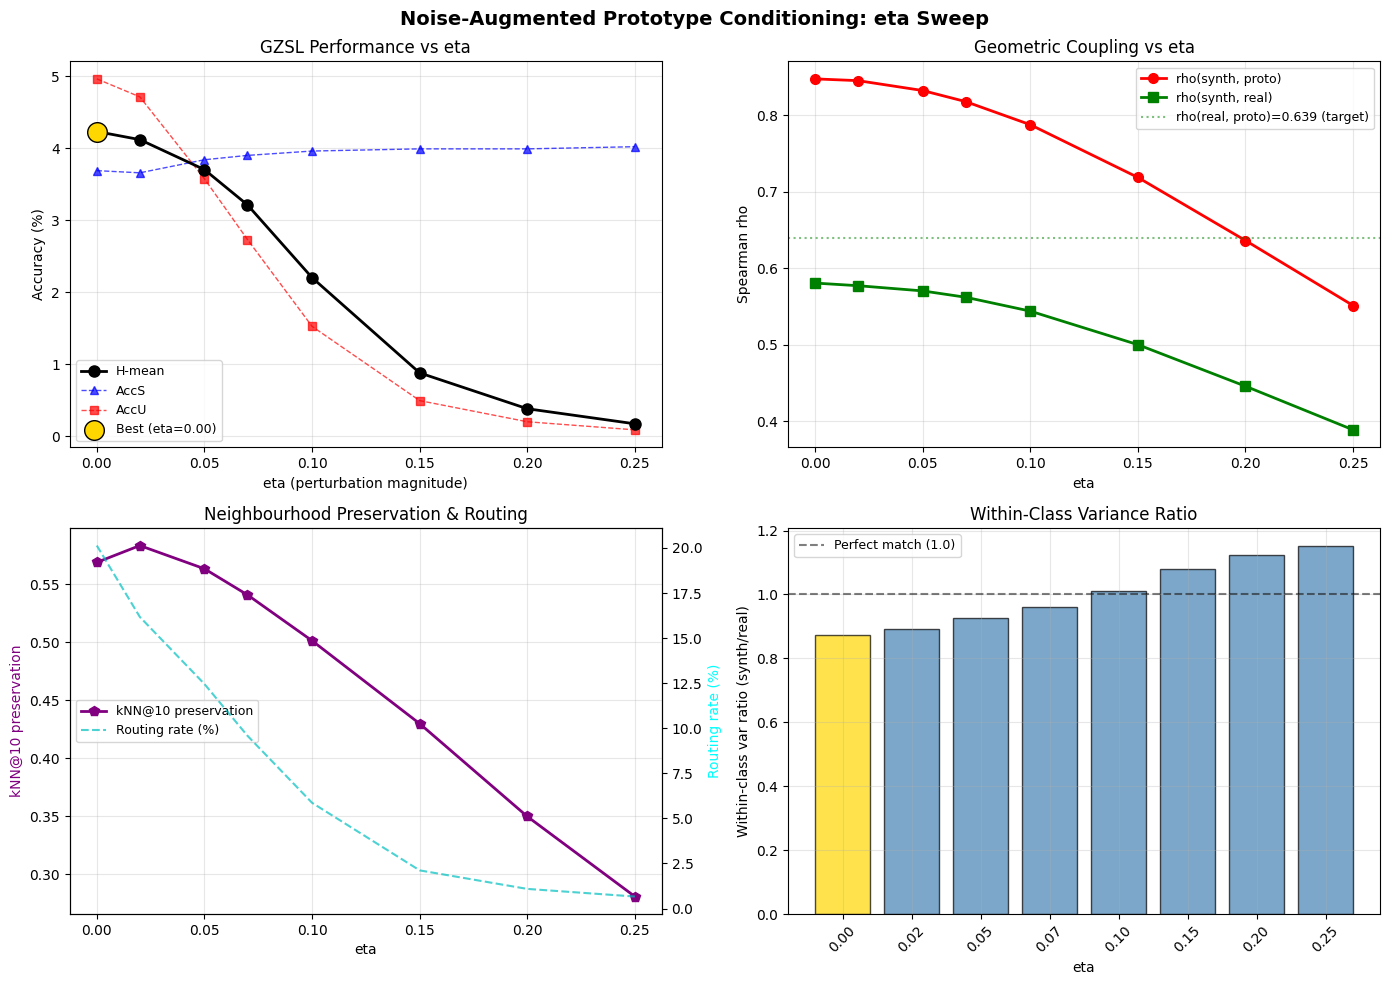

Saved: figures/eta_sweep_results.png

SWEEP SUMMARY

   eta        H     AccS     AccU   Route   rho_sp   rho_sr   kNN10    VarR
──────────────────────────────────────────────────────────────────────
  0.00    4.23%    3.69%    4.96%   20.1%   0.8476   0.5805  0.5690  0.874 <-- BEST
  0.02    4.12%    3.66%    4.71%   16.2%   0.8453   0.5771  0.5835  0.891
  0.05    3.70%    3.84%    3.57%   12.5%   0.8324   0.5703  0.5635  0.927
  0.07    3.21%    3.90%    2.73%    9.6%   0.8179   0.5620  0.5410  0.960
  0.10    2.20%    3.96%    1.52%    5.9%   0.7877   0.5438  0.5015  1.010
  0.15    0.88%    3.99%    0.49%    2.1%   0.7187   0.4999  0.4300  1.078
  0.20    0.38%    3.99%    0.20%    1.1%   0.6362   0.4455  0.3500  1.123
  0.25    0.17%    4.02%    0.09%    0.7%   0.5511   0.3885  0.2810  1.150

Verdict: Perturbation had negligible effect on H-mean (+0.00pp).
  The structural mismatch may not be the dominant bottleneck, or
  synthesis-only perturbation may be insufficient — consider

In [ ]:
# =============================================================================
# ANALYSIS + FIGURES
# =============================================================================

import matplotlib.pyplot as plt
import os
os.makedirs('figures', exist_ok=True)

etas = [r['eta'] for r in sweep_results]
Hs = [r['H'] * 100 for r in sweep_results]
AccSs = [r['acc_seen'] * 100 for r in sweep_results]
AccUs = [r['acc_unseen'] * 100 for r in sweep_results]
rho_sps = [r['rho_synth_proto'] for r in sweep_results]
rho_srs = [r['rho_synth_real'] for r in sweep_results]
knn10s = [r['knn_10'] for r in sweep_results]
var_ratios = [r['var_ratio'] for r in sweep_results]
routing = [r['routing_rate'] * 100 for r in sweep_results]

# Reference: real unseen rho to proto (from diagnostic 3)
rho_real_proto = sweep_results[0]['rho_real_proto']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Panel 1: H-mean, AccS, AccU vs eta
ax = axes[0, 0]
ax.plot(etas, Hs, 'ko-', linewidth=2, markersize=8, label='H-mean', zorder=3)
ax.plot(etas, AccSs, 'b^--', linewidth=1, markersize=6, alpha=0.7, label='AccS')
ax.plot(etas, AccUs, 'rs--', linewidth=1, markersize=6, alpha=0.7, label='AccU')
best_idx = Hs.index(max(Hs))
ax.scatter([etas[best_idx]], [Hs[best_idx]], s=200, c='gold', edgecolors='k',
           zorder=4, label=f'Best (eta={etas[best_idx]:.2f})')
ax.set_xlabel('eta (perturbation magnitude)')
ax.set_ylabel('Accuracy (%)')
ax.set_title('GZSL Performance vs eta')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# Panel 2: rho vs eta
ax = axes[0, 1]
ax.plot(etas, rho_sps, 'ro-', linewidth=2, markersize=7, label='rho(synth, proto)')
ax.plot(etas, rho_srs, 'gs-', linewidth=2, markersize=7, label='rho(synth, real)')
ax.axhline(y=rho_real_proto, color='green', linestyle=':', alpha=0.5,
           label=f'rho(real, proto)={rho_real_proto:.3f} (target)')
ax.set_xlabel('eta')
ax.set_ylabel('Spearman rho')
ax.set_title('Geometric Coupling vs eta')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# Panel 3: kNN preservation + routing rate
ax = axes[1, 0]
ax.plot(etas, knn10s, 'p-', color='purple', linewidth=2, markersize=7, label='kNN@10 preservation')
ax2 = ax.twinx()
ax2.plot(etas, routing, 'c--', linewidth=1.5, markersize=5, alpha=0.7, label='Routing rate (%)')
ax.set_xlabel('eta')
ax.set_ylabel('kNN@10 preservation', color='purple')
ax2.set_ylabel('Routing rate (%)', color='cyan')
ax.set_title('Neighbourhood Preservation & Routing')
lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines1 + lines2, labels1 + labels2, fontsize=9, loc='center left')
ax.grid(True, alpha=0.3)

# Panel 4: Within-class variance ratio
ax = axes[1, 1]
ax.bar(range(len(etas)), var_ratios, color=['steelblue' if e != best_eta else 'gold' for e in etas],
       alpha=0.7, edgecolor='k')
ax.axhline(y=1.0, color='k', linestyle='--', alpha=0.5, label='Perfect match (1.0)')
ax.set_xticks(range(len(etas)))
ax.set_xticklabels([f'{e:.2f}' for e in etas], rotation=45)
ax.set_xlabel('eta')
ax.set_ylabel('Within-class var ratio (synth/real)')
ax.set_title('Within-Class Variance Ratio')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

plt.suptitle('Noise-Augmented Prototype Conditioning: eta Sweep', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('figures/eta_sweep_results.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: figures/eta_sweep_results.png")

# ---- Print comprehensive summary ----
print("\n" + "=" * 70)
print("SWEEP SUMMARY")
print("=" * 70)
print(f"\n{'eta':>6s}  {'H':>7s}  {'AccS':>7s}  {'AccU':>7s}  {'Route':>6s}  "
      f"{'rho_sp':>7s}  {'rho_sr':>7s}  {'kNN10':>6s}  {'VarR':>6s}")
print(f"{'─'*70}")
for r in sweep_results:
    marker = " <-- BEST" if r['eta'] == best_eta else ""
    print(f"{r['eta']:6.2f}  {r['H']*100:6.2f}%  {r['acc_seen']*100:6.2f}%  "
          f"{r['acc_unseen']*100:6.2f}%  {r['routing_rate']*100:5.1f}%  "
          f"{r['rho_synth_proto']:7.4f}  {r['rho_synth_real']:7.4f}  "
          f"{r['knn_10']:6.4f}  {r['var_ratio']:5.3f}{marker}")
print(f"{'='*70}")

delta_H = (best_result['H'] - baseline_result['H']) * 100
if delta_H > 0.1:
    print(f"\nVerdict: Perturbation at eta={best_eta:.2f} improved H-mean by {delta_H:+.2f}pp")
elif delta_H < -0.1:
    print(f"\nVerdict: Perturbation degraded H-mean. Best eta=0 (no perturbation).")
else:
    print(f"\nVerdict: Perturbation had negligible effect on H-mean ({delta_H:+.2f}pp).")
    print("  The structural mismatch may not be the dominant bottleneck, or")
    print("  synthesis-only perturbation may be insufficient — consider training-time perturbation.")

In [ ]:
# =============================================================================
# CACHE BEST-ETA RESULTS
# =============================================================================

os.makedirs('cached_arrays', exist_ok=True)

# Regenerate best-eta synthetics for caching
E_synth_best, y_synth_best = synthesise_with_eta(
    generator_opt, unseen_classes_opt, S_unseen_opt,
    OPT_WGAN_CONFIG['n_synth_per_class'], OPT_WGAN_CONFIG['z_dim'],
    best_eta, device)

# Cache
np.save('cached_arrays/E_synth_unseen_eta.npy', E_synth_best)
np.save('cached_arrays/y_synth_unseen_eta.npy', y_synth_best)
np.save('cached_arrays/E_train_opt.npy', E_train_opt)
np.save('cached_arrays/E_test_opt.npy', E_test_opt)
np.save('cached_arrays/E_unseen_opt.npy', E_unseen_opt)

print(f"Cached best-eta (eta={best_eta:.2f}) arrays:")
print(f"  E_synth_unseen_eta: {E_synth_best.shape}")
print(f"  y_synth_unseen_eta: {y_synth_best.shape}")
print(f"  E_train_opt: {E_train_opt.shape}")
print(f"  E_test_opt: {E_test_opt.shape}")
print(f"  E_unseen_opt: {E_unseen_opt.shape}")

print(f"\nFinal config:")
print(f"  Encoder: embed_dim={OPT_ENCODER_CONFIG['embed_dim']}, tau={OPT_ENCODER_CONFIG['tau']}, "
      f"epochs={OPT_ENCODER_CONFIG['epochs']}, lr={OPT_ENCODER_CONFIG['lr']}")
print(f"  WGAN-GP: z_dim={OPT_WGAN_CONFIG['z_dim']}, steps={OPT_WGAN_CONFIG['n_steps']}")
print(f"  Perturbation: eta={best_eta:.2f}")
print(f"  Best H-mean: {best_result['H']*100:.2f}% "
      f"(AccS={best_result['acc_seen']*100:.2f}%, AccU={best_result['acc_unseen']*100:.2f}%)")

Cached best-eta (eta=0.00) arrays:
  E_synth_unseen_eta: (4000, 64)
  y_synth_unseen_eta: (4000,)
  E_train_opt: (13232, 64)
  E_test_opt: (3308, 64)
  E_unseen_opt: (16000, 64)

Final config:
  Encoder: embed_dim=64, tau=0.05, epochs=75, lr=0.002
  WGAN-GP: z_dim=100, steps=10000
  Perturbation: eta=0.00
  Best H-mean: 4.23% (AccS=3.69%, AccU=4.96%)


---

# Variance Regularisation (L_var): Training-Time WGAN-GP Modification

**Diagnosis**: WGAN-GP synthesis diagnostics (cells 67-70) revealed two pathologies:
1. **Structural overcoupling**: synthetic centroids track prototypes too faithfully
   (rho_sp=0.857 vs real 0.668)
2. **Variance deficit**: synthetic per-dimension variance is 12.8% below real
   (VarR=0.872)

**Failed intervention**: Noise-augmented prototype conditioning (eta sweep, cells 71-76)
showed monotonic degradation — H-mean dropped from 4.77% to 0.29%. Post-hoc perturbation
adds variance in the wrong directions (column space of J_G, not brain variability).

**This intervention**: Modify the generator's training objective to include a variance
regularisation term that penalises per-class variance deficit:
```
L_G = L_wasserstein + alpha * L_var
L_var = mean_c [ sum_d ( (var_synth_{c,d} - var_target_d)^2 ) ]
```

This reshapes the generator's Jacobian J_G through weight updates, changing *what* the
generator learns rather than perturbing inputs through a fixed J_G.

**Strategy**: Calibrate alpha via gradient-norm matching, then sweep 7 values spanning
2 orders of magnitude. Each alpha retrains the WGAN-GP (encoder is frozen and reused).

**Mathematical spec**: `context/variance_regularisation_implementation_directive.md`
**Critical assessment**: `context/variance_regularisation_debrief.md`

In [ ]:
# =============================================================================
# VARIANCE REGULARISATION: CONFIG + FUNCTION DEFINITIONS
# =============================================================================

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
import time
import gc

SEED = 42

# ---- Variance regularisation config ----
VAR_REG_CONFIG = {
    'K_gen': 20,           # samples per class in generator structured batch
    'C_batch': 16,         # classes per generator batch (gen batch = K*C = 320)
    'monitor_interval': 500,   # steps between detailed monitoring
    'alpha_sweep_multipliers': [0.01, 0.1, 0.5, 1.0, 2.0, 5.0, 10.0],
}

print("=" * 60)
print("VARIANCE REGULARISATION CONFIG")
print("=" * 60)
for k, v in VAR_REG_CONFIG.items():
    print(f"  {k}: {v}")
print(f"\n  Generator batch size: {VAR_REG_CONFIG['K_gen'] * VAR_REG_CONFIG['C_batch']}")
print(f"  Critic batch size: {OPT_WGAN_CONFIG['batch_size']} (unchanged)")
print("=" * 60)


# ---- L_var loss function ----
def compute_L_var(fake_embeddings, class_labels, var_target):
    """
    Variance regularisation loss.

    L_var = (1/|C_batch|) * sum_c [ sum_d ( (var_synth_{c,d} - var_target_d)^2 ) ]

    Args:
        fake_embeddings: (batch_size, d) generated embeddings on S^{d-1}, WITH grad
        class_labels:    (batch_size,) integer class label for each sample
        var_target:      (d,) precomputed target variance vector (detached)

    Returns:
        Scalar loss with requires_grad=True (connected to generator graph)

    Note: uses absolute L2 distance. If high-variance dimensions dominate while
    low-variance ones are ignored, consider relative alternative:
        sum_d ( (var_synth_d / var_target_d - 1)^2 )
    """
    unique_classes = torch.unique(class_labels)
    loss = torch.tensor(0.0, device=fake_embeddings.device)
    for c in unique_classes:
        mask = (class_labels == c)
        samples_c = fake_embeddings[mask]          # (K, d)
        mu_c = samples_c.mean(dim=0)               # (d,)
        var_c = ((samples_c - mu_c) ** 2).mean(dim=0)  # (d,)
        loss = loss + ((var_c - var_target) ** 2).sum()
    loss = loss / len(unique_classes)
    return loss


# ---- Modified WGAN-GP training function ----
def train_wgan_with_lvar(alpha, var_target, E_train, y_train, S_seen_protos,
                          seen_classes, wgan_config, var_reg_config, device):
    """
    Train WGAN-GP with variance regularisation: L_G = L_wasserstein + alpha * L_var.

    Critic step: UNCHANGED (random batching from DataLoader).
    Generator step: MODIFIED (structured batching for L_var).

    Args:
        alpha: weight for L_var term
        var_target: (d,) target variance vector (tensor on device)
        E_train: (N, d) real training embeddings (numpy)
        y_train: (N,) training labels (numpy)
        S_seen_protos: dict {class_id: prototype_vector} (numpy)
        seen_classes: sorted list of seen class IDs
        wgan_config: OPT_WGAN_CONFIG dict
        var_reg_config: VAR_REG_CONFIG dict
        device: torch device

    Returns:
        generator: trained Generator model
        history: dict with per-step and per-monitor-interval logs
    """
    np.random.seed(SEED)
    torch.manual_seed(SEED)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(SEED)

    d = wgan_config['embed_dim']
    z_dim = wgan_config['z_dim']
    n_steps = wgan_config['n_steps']
    n_critic = wgan_config['n_critic']
    K = var_reg_config['K_gen']
    C = var_reg_config['C_batch']
    monitor_interval = var_reg_config['monitor_interval']

    seen_classes_arr = np.array(seen_classes)

    # ---- Instantiate fresh models ----
    gen = Generator(z_dim=z_dim, embed_dim=d).to(device)
    crit = Critic(embed_dim=d).to(device)

    g_optim = torch.optim.Adam(gen.parameters(), lr=wgan_config['lr'],
                                betas=wgan_config['betas'])
    c_optim = torch.optim.Adam(crit.parameters(), lr=wgan_config['lr'],
                                betas=wgan_config['betas'])

    # ---- Critic DataLoader (random batching, unchanged) ----
    E_train_t = torch.FloatTensor(E_train)
    S_train_cond = torch.FloatTensor(get_prototype_for_labels(y_train, S_seen_protos))
    wgan_ds = TensorDataset(E_train_t, S_train_cond)
    wgan_dl = DataLoader(wgan_ds, batch_size=wgan_config['batch_size'],
                          shuffle=True, drop_last=True)
    data_iter = iter(wgan_dl)

    # ---- Prototype lookup for structured batching ----
    proto_array = {c: S_seen_protos[c] for c in seen_classes}

    # ---- History ----
    hist = {
        'L_wasserstein': [], 'L_var': [], 'L_G': [], 'L_D': [],
        'monitor_steps': [],
        'grad_norm_w': [], 'grad_norm_v': [], 'grad_cos_sim': [],
        'VarR': [],
    }

    rng = np.random.RandomState(SEED)
    t0 = time.time()
    g_step = 0

    while g_step < n_steps:
        # -----------------------------------------------------------------
        # Critic update (n_critic times) — UNCHANGED
        # -----------------------------------------------------------------
        for _ in range(n_critic):
            try:
                e_real, s_c = next(data_iter)
            except StopIteration:
                data_iter = iter(wgan_dl)
                e_real, s_c = next(data_iter)
            e_real, s_c = e_real.to(device), s_c.to(device)
            bs = e_real.size(0)

            z = torch.randn(bs, z_dim, device=device)
            e_fake = gen(z, s_c)
            d_real = crit(e_real, s_c)
            d_fake = crit(e_fake.detach(), s_c)
            gp = compute_gradient_penalty(crit, e_real, e_fake.detach(), s_c, device)
            c_loss = -d_real.mean() + d_fake.mean() + wgan_config['lambda_gp'] * gp

            c_optim.zero_grad()
            c_loss.backward()
            c_optim.step()

        # -----------------------------------------------------------------
        # Generator update — MODIFIED (structured batching + L_var)
        # -----------------------------------------------------------------
        # Sample C classes, K samples each
        batch_classes = rng.choice(seen_classes_arr, size=C, replace=False)
        s_c_list = []
        labels_list = []
        for c_id in batch_classes:
            proto = proto_array[c_id]
            s_c_list.append(np.tile(proto, (K, 1)))
            labels_list.append(np.full(K, c_id, dtype=np.int64))
        s_c_gen = torch.FloatTensor(np.vstack(s_c_list)).to(device)
        class_labels = torch.LongTensor(np.concatenate(labels_list)).to(device)

        z = torch.randn(C * K, z_dim, device=device)
        e_fake = gen(z, s_c_gen)

        # Wasserstein loss
        L_w = -crit(e_fake, s_c_gen).mean()

        # Variance regularisation loss
        L_v = compute_L_var(e_fake, class_labels, var_target)

        # Combined generator loss
        L_G_total = L_w + alpha * L_v

        # -----------------------------------------------------------------
        # Monitoring (before backward, using retain_graph)
        # -----------------------------------------------------------------
        do_monitor = (g_step % monitor_interval == 0) or (g_step == n_steps - 1)

        if do_monitor:
            # Separate gradient norms (Concern 6: gradient alignment)
            grad_w = torch.autograd.grad(L_w, gen.parameters(),
                                          retain_graph=True, create_graph=False)
            grad_v = torch.autograd.grad(L_v, gen.parameters(),
                                          retain_graph=True, create_graph=False)

            norm_w = torch.sqrt(sum(g.pow(2).sum() for g in grad_w)).item()
            norm_v = torch.sqrt(sum(g.pow(2).sum() for g in grad_v)).item()

            # Cosine similarity
            flat_w = torch.cat([g.flatten() for g in grad_w])
            flat_v = torch.cat([g.flatten() for g in grad_v])
            cos_sim = F.cosine_similarity(flat_w.unsqueeze(0),
                                           flat_v.unsqueeze(0)).item()

            # VarR: sample classes, generate, measure variance
            gen.eval()
            with torch.no_grad():
                mon_classes = rng.choice(seen_classes_arr,
                                         size=min(50, len(seen_classes_arr)),
                                         replace=False)
                mon_vars = []
                for mc in mon_classes:
                    s_m = torch.FloatTensor(proto_array[mc]).unsqueeze(0).repeat(K, 1).to(device)
                    z_m = torch.randn(K, z_dim, device=device)
                    e_m = gen(z_m, s_m)
                    var_m = ((e_m - e_m.mean(dim=0)) ** 2).mean(dim=0)
                    mon_vars.append(var_m)
                mean_synth_var = torch.stack(mon_vars).mean(dim=0)
                var_ratio = mean_synth_var.sum().item() / var_target.sum().item()
            gen.train()

            hist['monitor_steps'].append(g_step)
            hist['grad_norm_w'].append(norm_w)
            hist['grad_norm_v'].append(norm_v)
            hist['grad_cos_sim'].append(cos_sim)
            hist['VarR'].append(var_ratio)

        # -----------------------------------------------------------------
        # Backward + step
        # -----------------------------------------------------------------
        g_optim.zero_grad()
        L_G_total.backward()
        g_optim.step()

        # Log
        hist['L_wasserstein'].append(L_w.item())
        hist['L_var'].append(L_v.item())
        hist['L_G'].append(L_G_total.item())
        hist['L_D'].append(c_loss.item())

        g_step += 1

        if g_step % 2500 == 0 or g_step == 1:
            vr_str = f", VarR={hist['VarR'][-1]:.3f}" if hist['VarR'] else ""
            print(f"  Step {g_step:5d}/{n_steps}: "
                  f"L_w={L_w.item():.4f}, L_var={L_v.item():.6f}, "
                  f"L_D={c_loss.item():.4f}{vr_str}")

    elapsed = time.time() - t0

    # ---- End-of-training check (Concern 5: may need extending) ----
    L_var_arr = np.array(hist['L_var'])
    if len(L_var_arr) > 4000:
        mid_avg = L_var_arr[4000:6000].mean()
        end_avg = L_var_arr[-2000:].mean()
        if mid_avg > 0 and end_avg < 0.8 * mid_avg:
            print(f"  WARNING: L_var still decreasing significantly "
                  f"(mid={mid_avg:.6f} -> end={end_avg:.6f}, "
                  f"-{100*(1-end_avg/mid_avg):.0f}%). "
                  f"Consider extending training beyond {n_steps} steps.")

    print(f"  Training complete in {elapsed:.0f}s. "
          f"L_w={hist['L_wasserstein'][-1]:.4f}, "
          f"L_var={hist['L_var'][-1]:.6f}, "
          f"VarR={hist['VarR'][-1]:.3f}")

    return gen, hist


# ---- Alpha calibration function ----
def calibrate_alpha(var_target, S_seen_protos, seen_classes, wgan_config,
                     var_reg_config, device):
    """
    Determine alpha_0 by matching gradient norms of L_wasserstein and L_var.

    Instantiates a fresh Generator + Critic, runs one structured generator step,
    measures ||grad L_w|| and ||grad L_var|| separately.

    Returns:
        alpha_0: float, ||grad L_w|| / ||grad L_var||
        info: dict with norms, losses, cosine similarity
    """
    np.random.seed(SEED)
    torch.manual_seed(SEED)

    d = wgan_config['embed_dim']
    z_dim = wgan_config['z_dim']
    K = var_reg_config['K_gen']
    C = var_reg_config['C_batch']

    gen = Generator(z_dim=z_dim, embed_dim=d).to(device)
    crit = Critic(embed_dim=d).to(device)

    seen_classes_arr = np.array(seen_classes)
    rng = np.random.RandomState(SEED)

    # Structured batch
    batch_classes = rng.choice(seen_classes_arr, size=C, replace=False)
    s_c_list, labels_list = [], []
    for c_id in batch_classes:
        proto = S_seen_protos[c_id]
        s_c_list.append(np.tile(proto, (K, 1)))
        labels_list.append(np.full(K, c_id, dtype=np.int64))
    s_c = torch.FloatTensor(np.vstack(s_c_list)).to(device)
    class_labels = torch.LongTensor(np.concatenate(labels_list)).to(device)

    z = torch.randn(C * K, z_dim, device=device)
    e_fake = gen(z, s_c)

    # Wasserstein term
    L_w = -crit(e_fake, s_c).mean()
    grad_w = torch.autograd.grad(L_w, gen.parameters(), retain_graph=True)
    norm_w = torch.sqrt(sum(g.pow(2).sum() for g in grad_w)).item()

    # L_var term
    L_v = compute_L_var(e_fake, class_labels, var_target)
    grad_v = torch.autograd.grad(L_v, gen.parameters())
    norm_v = torch.sqrt(sum(g.pow(2).sum() for g in grad_v)).item()

    # Cosine similarity
    flat_w = torch.cat([g.flatten() for g in grad_w])
    flat_v = torch.cat([g.flatten() for g in grad_v])
    cos_sim = F.cosine_similarity(flat_w.unsqueeze(0), flat_v.unsqueeze(0)).item()

    alpha_0 = norm_w / (norm_v + 1e-10)

    info = {
        'norm_w': norm_w, 'norm_v': norm_v,
        'L_w': L_w.item(), 'L_v': L_v.item(),
        'cos_sim': cos_sim,
    }

    del gen, crit
    torch.cuda.empty_cache() if torch.cuda.is_available() else None
    gc.collect()

    return alpha_0, info


print("Functions defined: compute_L_var, train_wgan_with_lvar, calibrate_alpha")

VARIANCE REGULARISATION CONFIG
  K_gen: 20
  C_batch: 16
  monitor_interval: 500
  alpha_sweep_multipliers: [0.01, 0.1, 0.5, 1.0, 2.0, 5.0, 10.0]

  Generator batch size: 320
  Critic batch size: 256 (unchanged)
Functions defined: compute_L_var, train_wgan_with_lvar, calibrate_alpha


In [ ]:
# =============================================================================
# COMPUTE var_target + CORRECTNESS VERIFICATION
# =============================================================================
# var_target: average per-class per-dimension variance of SEEN training embeddings.
# Computed from E_train_opt (L2-normalised encoder output on S^63, from cell 73).
# This is a fixed 64-D vector used as the regularisation target.

d = OPT_ENCODER_CONFIG['embed_dim']

# ---- Step 1: Compute var_target ----
print("Computing var_target from training seen embeddings...")
var_target_list = []
class_sample_counts = []
for c in seen_classes_opt:
    mask = (y_train_opt == c)
    emb_c = E_train_opt[mask]  # (n_c, 64)
    n_c = emb_c.shape[0]
    class_sample_counts.append(n_c)
    mu_c = emb_c.mean(axis=0)                        # (64,)
    var_c = ((emb_c - mu_c) ** 2).mean(axis=0)       # (64,)
    var_target_list.append(var_c)

var_target_np = np.stack(var_target_list).mean(axis=0)   # (64,)
var_target = torch.FloatTensor(var_target_np).to(device)

print(f"\nvar_target statistics:")
print(f"  Shape: {var_target.shape}")
print(f"  All positive: {(var_target > 0).all().item()}")
print(f"  Mean:  {var_target.mean().item():.6f}")
print(f"  Std:   {var_target.std().item():.6f}")
print(f"  Min:   {var_target.min().item():.6f}")
print(f"  Max:   {var_target.max().item():.6f}")
print(f"  Sum:   {var_target.sum().item():.6f} (L2-norm budget: should be < 1.0)")
print(f"  Classes: {len(var_target_list)}")
print(f"  Samples/class: min={min(class_sample_counts)}, "
      f"max={max(class_sample_counts)}, "
      f"median={int(np.median(class_sample_counts))}")

# ---- Step 2: Correctness verification (directive Section 7 checklist) ----
print("\n" + "=" * 60)
print("CORRECTNESS VERIFICATION")
print("=" * 60)

all_pass = True

# Check 1: var_target shape and positivity
check1 = var_target.shape == (d,) and (var_target > 0).all().item()
print(f"  [{'PASS' if check1 else 'FAIL'}] Check 1: var_target shape ({d},) and all positive")
all_pass &= check1

# Check 2: compute_L_var returns scalar with requires_grad
torch.manual_seed(SEED)
test_gen = Generator(z_dim=OPT_WGAN_CONFIG['z_dim'], embed_dim=d).to(device)
test_z = torch.randn(32, OPT_WGAN_CONFIG['z_dim'], device=device)
test_s = torch.randn(32, d, device=device)
test_s = F.normalize(test_s, p=2, dim=-1)
test_labels = torch.LongTensor([0]*16 + [1]*16).to(device)
test_fake = test_gen(test_z, test_s)
test_loss = compute_L_var(test_fake, test_labels, var_target)
check2 = test_loss.dim() == 0 and test_loss.requires_grad
print(f"  [{'PASS' if check2 else 'FAIL'}] Check 2: compute_L_var returns scalar "
      f"(dim={test_loss.dim()}) with requires_grad={test_loss.requires_grad}")
all_pass &= check2

# Check 3: L_var = 0 when variance matches target exactly
# Craft input: for each class, samples whose variance equals var_target
torch.manual_seed(SEED)
n_test_classes = 3
K_test = 20
crafted_embeddings = []
crafted_labels = []
for ci in range(n_test_classes):
    # Create samples centred at origin with variance = var_target
    # x_k = sqrt(var_target) * u_k where u_k are unit-variance samples centred at 0
    # Use: x_k,d = mu_d + sqrt(var_target_d) * (standard normal centred)
    raw = torch.randn(K_test, d, device=device)
    raw = raw - raw.mean(dim=0)  # centre exactly
    # Scale to match target variance: var(raw) per dim, then rescale
    raw_var = ((raw ** 2).mean(dim=0)).sqrt()
    raw_var = raw_var.clamp(min=1e-8)
    target_std = var_target.sqrt()
    scaled = raw * (target_std / raw_var)
    # Verify: scaled has var = var_target per dim (up to numerical precision)
    crafted_embeddings.append(scaled)
    crafted_labels.extend([ci] * K_test)
crafted_emb = torch.cat(crafted_embeddings, dim=0)
crafted_lab = torch.LongTensor(crafted_labels).to(device)
# Need requires_grad for the function to work in autograd context
crafted_emb.requires_grad_(True)
L_var_zero = compute_L_var(crafted_emb, crafted_lab, var_target)
check3 = L_var_zero.item() < 1e-8
print(f"  [{'PASS' if check3 else 'FAIL'}] Check 3: L_var=0 when variance matches target "
      f"(L_var={L_var_zero.item():.2e})")
all_pass &= check3

# Check 4: Gradient verification — autograd vs analytical formula
# Analytical: dL_var/de_{c,k} = (4/K) * Delta_c * (e_{c,k} - mu_hat_c)
# where Delta_c = var_synth_c - var_target
torch.manual_seed(42)
K_gv = 10
C_gv = 3
gv_embeddings = torch.randn(K_gv * C_gv, d, device=device, requires_grad=True)
gv_labels = torch.LongTensor(sum([[ci]*K_gv for ci in range(C_gv)], [])).to(device)
gv_loss = compute_L_var(gv_embeddings, gv_labels, var_target)
gv_loss.backward()
autograd_grad = gv_embeddings.grad.clone()

# Analytical gradient
with torch.no_grad():
    analytical_grad = torch.zeros_like(gv_embeddings)
    for ci in range(C_gv):
        mask = (gv_labels == ci)
        samples_c = gv_embeddings[mask]  # (K_gv, d)
        mu_c = samples_c.mean(dim=0)
        var_c = ((samples_c - mu_c) ** 2).mean(dim=0)
        delta_c = var_c - var_target
        # dL_var/de_{c,k} = (4/K) * delta * (e - mu)
        # But also divided by C_gv (the mean over classes)
        for k_idx, global_idx in enumerate(torch.where(mask)[0]):
            analytical_grad[global_idx] = (4.0 / K_gv) * delta_c * (samples_c[k_idx] - mu_c) / C_gv

max_diff = (autograd_grad - analytical_grad).abs().max().item()
check4 = max_diff < 1e-4
print(f"  [{'PASS' if check4 else 'FAIL'}] Check 4: Gradient verification "
      f"(max |autograd - analytical| = {max_diff:.2e}, threshold=1e-4)")
all_pass &= check4

# Check 5: Generator outputs on S^{d-1} (unit sphere)
torch.manual_seed(SEED)
check_gen = Generator(z_dim=OPT_WGAN_CONFIG['z_dim'], embed_dim=d).to(device)
check_z = torch.randn(100, OPT_WGAN_CONFIG['z_dim'], device=device)
check_s = F.normalize(torch.randn(100, d, device=device), p=2, dim=-1)
with torch.no_grad():
    check_out = check_gen(check_z, check_s)
    norms = check_out.norm(p=2, dim=-1)
check5 = (norms - 1.0).abs().max().item() < 1e-5
print(f"  [{'PASS' if check5 else 'FAIL'}] Check 5: Generator outputs on S^{d-1} "
      f"(max |norm - 1| = {(norms - 1.0).abs().max().item():.2e})")
all_pass &= check5

# Cleanup
del test_gen, check_gen, test_fake, crafted_emb, gv_embeddings
torch.cuda.empty_cache() if torch.cuda.is_available() else None
gc.collect()

print("=" * 60)
if all_pass:
    print("ALL CHECKS PASSED. Ready to proceed with alpha calibration.")
else:
    print("SOME CHECKS FAILED. Investigate before proceeding.")
print("=" * 60)

Computing var_target from training seen embeddings...

var_target statistics:
  Shape: torch.Size([64])
  All positive: True
  Mean:  0.010926
  Std:   0.001865
  Min:   0.005930
  Max:   0.015431
  Sum:   0.699247 (L2-norm budget: should be < 1.0)
  Classes: 1654
  Samples/class: min=8, max=8, median=8

CORRECTNESS VERIFICATION
  [PASS] Check 1: var_target shape (64,) and all positive
  [PASS] Check 2: compute_L_var returns scalar (dim=0) with requires_grad=True
  [PASS] Check 3: L_var=0 when variance matches target (L_var=9.90e-17)
  [PASS] Check 4: Gradient verification (max |autograd - analytical| = 5.96e-08, threshold=1e-4)
  [PASS] Check 5: Generator outputs on S^63 (max |norm - 1| = 1.19e-07)
ALL CHECKS PASSED. Ready to proceed with alpha calibration.


In [ ]:
# =============================================================================
# ALPHA CALIBRATION (GRADIENT-NORM MATCHING)
# =============================================================================
# Determine alpha_0 such that ||grad L_wasserstein|| ~ ||alpha * grad L_var||
# i.e. alpha_0 = ||grad L_w|| / ||grad L_var||
# Then sweep alpha in {0.01*alpha_0, ..., 10*alpha_0}

print("Running alpha calibration...")
alpha_0, cal_info = calibrate_alpha(
    var_target=var_target,
    S_seen_protos=S_seen_opt,
    seen_classes=seen_classes_opt,
    wgan_config=OPT_WGAN_CONFIG,
    var_reg_config=VAR_REG_CONFIG,
    device=device,
)

print(f"\n{'=' * 60}")
print("ALPHA CALIBRATION RESULTS")
print(f"{'=' * 60}")
print(f"  ||grad L_wasserstein||: {cal_info['norm_w']:.6f}")
print(f"  ||grad L_var||:         {cal_info['norm_v']:.6f}")
print(f"  alpha_0 (norm ratio):   {alpha_0:.6f}")
print(f"  L_wasserstein:          {cal_info['L_w']:.4f}")
print(f"  L_var:                  {cal_info['L_v']:.6f}")
print(f"  cos(grad_w, grad_v):    {cal_info['cos_sim']:.4f}")

# Sanity check
if alpha_0 < 1e-6 or alpha_0 > 1e6:
    print(f"\n  WARNING: alpha_0 = {alpha_0:.2e} is extreme. "
          f"Gradient norms differ by >6 OOM. Inspect L_var scale.")

# Compute sweep values
alpha_sweep_values = [m * alpha_0 for m in VAR_REG_CONFIG['alpha_sweep_multipliers']]
print(f"\nAlpha sweep values (7 points, 2 OOM range):")
for m, a in zip(VAR_REG_CONFIG['alpha_sweep_multipliers'], alpha_sweep_values):
    label = " <-- alpha_0" if m == 1.0 else ""
    print(f"  {m:5.2f} x alpha_0 = {a:.6f}{label}")
print(f"{'=' * 60}")

Running alpha calibration...

ALPHA CALIBRATION RESULTS
  ||grad L_wasserstein||: 0.181351
  ||grad L_var||:         0.009135
  alpha_0 (norm ratio):   19.852067
  L_wasserstein:          0.0669
  L_var:                  0.001272
  cos(grad_w, grad_v):    -0.1497

Alpha sweep values (7 points, 2 OOM range):
   0.01 x alpha_0 = 0.198521
   0.10 x alpha_0 = 1.985207
   0.50 x alpha_0 = 9.926033
   1.00 x alpha_0 = 19.852067 <-- alpha_0
   2.00 x alpha_0 = 39.704133
   5.00 x alpha_0 = 99.260334
  10.00 x alpha_0 = 198.520667


In [ ]:
# =============================================================================
# ALPHA SWEEP: TRAIN MODIFIED WGAN-GP FOR EACH ALPHA
# =============================================================================
# Each alpha: fresh WGAN-GP training (10,000 steps) -> synthesise -> evaluate.
# Encoder is reused from cell 73 (frozen).

print("=" * 60)
print(f"ALPHA SWEEP: {len(alpha_sweep_values)} values")
print("=" * 60)
print(f"  WGAN-GP steps per alpha: {OPT_WGAN_CONFIG['n_steps']}")
print(f"  Structured batch: K={VAR_REG_CONFIG['K_gen']} x C={VAR_REG_CONFIG['C_batch']} "
      f"= {VAR_REG_CONFIG['K_gen'] * VAR_REG_CONFIG['C_batch']}")
print(f"  Baseline to beat: H=4.77%, AccS=4.11%, AccU=5.69%, VarR=0.872, rho_sp=0.857")
print()

sweep_results = []
sweep_histories = []
t_sweep_start = time.time()

for i, alpha_val in enumerate(alpha_sweep_values):
    mult = VAR_REG_CONFIG['alpha_sweep_multipliers'][i]
    print(f"\n{'─' * 60}")
    print(f"[{i+1}/{len(alpha_sweep_values)}] alpha = {alpha_val:.6f} ({mult:.2f} x alpha_0)")
    print(f"{'─' * 60}")

    # Train modified WGAN-GP
    gen_a, hist_a = train_wgan_with_lvar(
        alpha=alpha_val,
        var_target=var_target,
        E_train=E_train_opt,
        y_train=y_train_opt,
        S_seen_protos=S_seen_opt,
        seen_classes=seen_classes_opt,
        wgan_config=OPT_WGAN_CONFIG,
        var_reg_config=VAR_REG_CONFIG,
        device=device,
    )

    # Evaluate full pipeline (reuse evaluate_eta with eta=0)
    result = evaluate_eta(
        eta=0.0,
        generator=gen_a,
        E_train=E_train_opt, y_train=y_train_opt,
        E_test=E_test_opt, y_test=y_test_opt,
        E_unseen=E_unseen_opt, y_unseen=y_unseen_opt,
        S_unseen_protos=S_unseen_opt, S_unseen_array=S_unseen_arr_opt,
        unseen_classes=unseen_classes_opt,
        seen_labels_set=seen_labels_set_opt,
        unseen_labels_set=unseen_labels_set_opt,
        median_per_class=median_per_class_opt,
        device=device,
    )

    result['alpha'] = alpha_val
    result['alpha_mult'] = mult
    result['final_L_var'] = hist_a['L_var'][-1]
    result['final_L_w'] = hist_a['L_wasserstein'][-1]
    result['final_VarR'] = hist_a['VarR'][-1] if hist_a['VarR'] else None
    result['final_cos_sim'] = hist_a['grad_cos_sim'][-1] if hist_a['grad_cos_sim'] else None

    sweep_results.append(result)
    sweep_histories.append(hist_a)

    # Progressive results table
    print(f"\n  Results: H={result['H']*100:.2f}%, "
          f"AccS={result['acc_seen']*100:.2f}%, AccU={result['acc_unseen']*100:.2f}%, "
          f"Route={result['routing_rate']*100:.1f}%, "
          f"VarR={result['var_ratio']:.3f}, rho_sp={result['rho_synth_proto']:.3f}")

    # Cleanup
    del gen_a
    torch.cuda.empty_cache() if torch.cuda.is_available() else None
    gc.collect()

t_sweep = time.time() - t_sweep_start
print(f"\n{'=' * 60}")
print(f"SWEEP COMPLETE ({t_sweep:.0f}s total)")
print(f"{'=' * 60}")

# Summary table
print(f"\n{'alpha':>10s} {'mult':>6s} {'H%':>7s} {'AccS%':>7s} {'AccU%':>7s} "
      f"{'Route%':>7s} {'VarR':>6s} {'rho_sp':>7s} {'rho_sr':>7s} {'kNN10':>6s}")
print("-" * 85)
for r in sweep_results:
    print(f"{r['alpha']:10.6f} {r['alpha_mult']:6.2f} "
          f"{r['H']*100:7.2f} {r['acc_seen']*100:7.2f} {r['acc_unseen']*100:7.2f} "
          f"{r['routing_rate']*100:7.1f} {r['var_ratio']:6.3f} "
          f"{r['rho_synth_proto']:7.4f} {r['rho_synth_real']:7.4f} {r['knn_10']:6.3f}")
print("-" * 85)
print(f"{'BASELINE':>10s} {'---':>6s} "
      f"{'4.77':>7s} {'4.11':>7s} {'5.69':>7s} "
      f"{'20.0':>7s} {'0.872':>6s} {'0.8572':>7s} {'0.5875':>7s} {'0.611':>6s}")

# Identify best
best_idx = max(range(len(sweep_results)), key=lambda i: sweep_results[i]['H'])
best = sweep_results[best_idx]
print(f"\nBest alpha: {best['alpha']:.6f} ({best['alpha_mult']:.2f}x alpha_0)")
print(f"  H={best['H']*100:.2f}% (baseline: 4.77%, delta: {(best['H']-0.0477)*100:+.2f}pp)")

ALPHA SWEEP: 7 values
  WGAN-GP steps per alpha: 10000
  Structured batch: K=20 x C=16 = 320
  Baseline to beat: H=4.77%, AccS=4.11%, AccU=5.69%, VarR=0.872, rho_sp=0.857


────────────────────────────────────────────────────────────
[1/7] alpha = 0.198521 (0.01 x alpha_0)
────────────────────────────────────────────────────────────
  Step     1/10000: L_w=0.0661, L_var=0.001266, L_D=8.2193, VarR=0.710
  Step  2500/10000: L_w=-1.1821, L_var=0.000808, L_D=-0.0148, VarR=0.918
  Step  5000/10000: L_w=-1.5157, L_var=0.000786, L_D=-0.0482, VarR=0.968
  Step  7500/10000: L_w=-1.5440, L_var=0.000869, L_D=-0.0552, VarR=0.976
  Step 10000/10000: L_w=-1.5090, L_var=0.000775, L_D=-0.0629, VarR=0.981
  Training complete in 447s. L_w=-1.5090, L_var=0.000775, VarR=0.981


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(



  Results: H=4.48%, AccS=3.75%, AccU=5.58%, Route=18.3%, VarR=0.883, rho_sp=0.873

────────────────────────────────────────────────────────────
[2/7] alpha = 1.985207 (0.10 x alpha_0)
────────────────────────────────────────────────────────────
  Step     1/10000: L_w=0.0661, L_var=0.001266, L_D=8.2193, VarR=0.710
  Step  2500/10000: L_w=-1.1382, L_var=0.000738, L_D=-0.0169, VarR=0.952
  Step  5000/10000: L_w=-1.5921, L_var=0.000814, L_D=-0.0432, VarR=0.967
  Step  7500/10000: L_w=-1.5373, L_var=0.000813, L_D=-0.0547, VarR=0.982
  Step 10000/10000: L_w=-1.4615, L_var=0.000836, L_D=-0.0442, VarR=0.964
  Training complete in 447s. L_w=-1.4615, L_var=0.000836, VarR=0.964


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(



  Results: H=4.39%, AccS=3.78%, AccU=5.22%, Route=15.4%, VarR=0.890, rho_sp=0.873

────────────────────────────────────────────────────────────
[3/7] alpha = 9.926033 (0.50 x alpha_0)
────────────────────────────────────────────────────────────
  Step     1/10000: L_w=0.0661, L_var=0.001266, L_D=8.2193, VarR=0.710
  Step  2500/10000: L_w=-0.7893, L_var=0.000818, L_D=-0.0018, VarR=0.918
  Step  5000/10000: L_w=-1.0856, L_var=0.000757, L_D=-0.0330, VarR=0.966
  Step  7500/10000: L_w=-1.0701, L_var=0.000721, L_D=-0.0610, VarR=0.972
  Step 10000/10000: L_w=-0.7991, L_var=0.000771, L_D=-0.0480, VarR=0.974
  Training complete in 449s. L_w=-0.7991, L_var=0.000771, VarR=0.974


...


  Results: H=4.38%, AccS=3.81%, AccU=5.16%, Route=17.5%, VarR=0.882, rho_sp=0.870

────────────────────────────────────────────────────────────
[6/7] alpha = 99.260334 (5.00 x alpha_0)
────────────────────────────────────────────────────────────
  Step     1/10000: L_w=0.0661, L_var=0.001266, L_D=8.2193, VarR=0.710
  Step  2500/10000: L_w=0.0347, L_var=0.000777, L_D=-0.0188, VarR=0.920
  Step  5000/10000: L_w=-0.2607, L_var=0.000605, L_D=-0.0373, VarR=0.969
  Step  7500/10000: L_w=-0.4162, L_var=0.000793, L_D=-0.0579, VarR=0.961
  Step 10000/10000: L_w=-0.6596, L_var=0.000785, L_D=-0.0631, VarR=0.967
  Training complete in 448s. L_w=-0.6596, L_var=0.000785, VarR=0.967


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(



  Results: H=4.42%, AccS=3.81%, AccU=5.27%, Route=18.0%, VarR=0.879, rho_sp=0.879

────────────────────────────────────────────────────────────
[7/7] alpha = 198.520667 (10.00 x alpha_0)
────────────────────────────────────────────────────────────
  Step     1/10000: L_w=0.0661, L_var=0.001266, L_D=8.2193, VarR=0.710
  Step  2500/10000: L_w=0.2236, L_var=0.000771, L_D=-0.0255, VarR=0.928
  Step  5000/10000: L_w=0.2074, L_var=0.000720, L_D=-0.0310, VarR=0.964
  Step  7500/10000: L_w=0.0876, L_var=0.000796, L_D=-0.0572, VarR=0.969
  Step 10000/10000: L_w=0.1678, L_var=0.000778, L_D=-0.0694, VarR=0.973
  Training complete in 450s. L_w=0.1678, L_var=0.000778, VarR=0.973


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(



  Results: H=4.58%, AccS=3.81%, AccU=5.76%, Route=17.8%, VarR=0.875, rho_sp=0.880

SWEEP COMPLETE (3189s total)

     alpha   mult      H%   AccS%   AccU%  Route%   VarR  rho_sp  rho_sr  kNN10
-------------------------------------------------------------------------------------
  0.198521   0.01    4.48    3.75    5.58    18.3  0.883  0.8729  0.5814  0.617
  1.985207   0.10    4.39    3.78    5.22    15.4  0.890  0.8731  0.5813  0.601
  9.926033   0.50    4.42    3.72    5.46    18.1  0.882  0.8741  0.5969  0.601
 19.852067   1.00    4.24    3.72    4.92    18.6  0.886  0.8723  0.5787  0.602
 39.704133   2.00    4.38    3.81    5.16    17.5  0.882  0.8698  0.5761  0.600
 99.260334   5.00    4.42    3.81    5.27    18.0  0.879  0.8785  0.5792  0.614
198.520667  10.00    4.58    3.81    5.76    17.8  0.875  0.8798  0.5847  0.606
-------------------------------------------------------------------------------------
  BASELINE    ---    4.77    4.11    5.69    20.0  0.872  0.8572  0.5875  

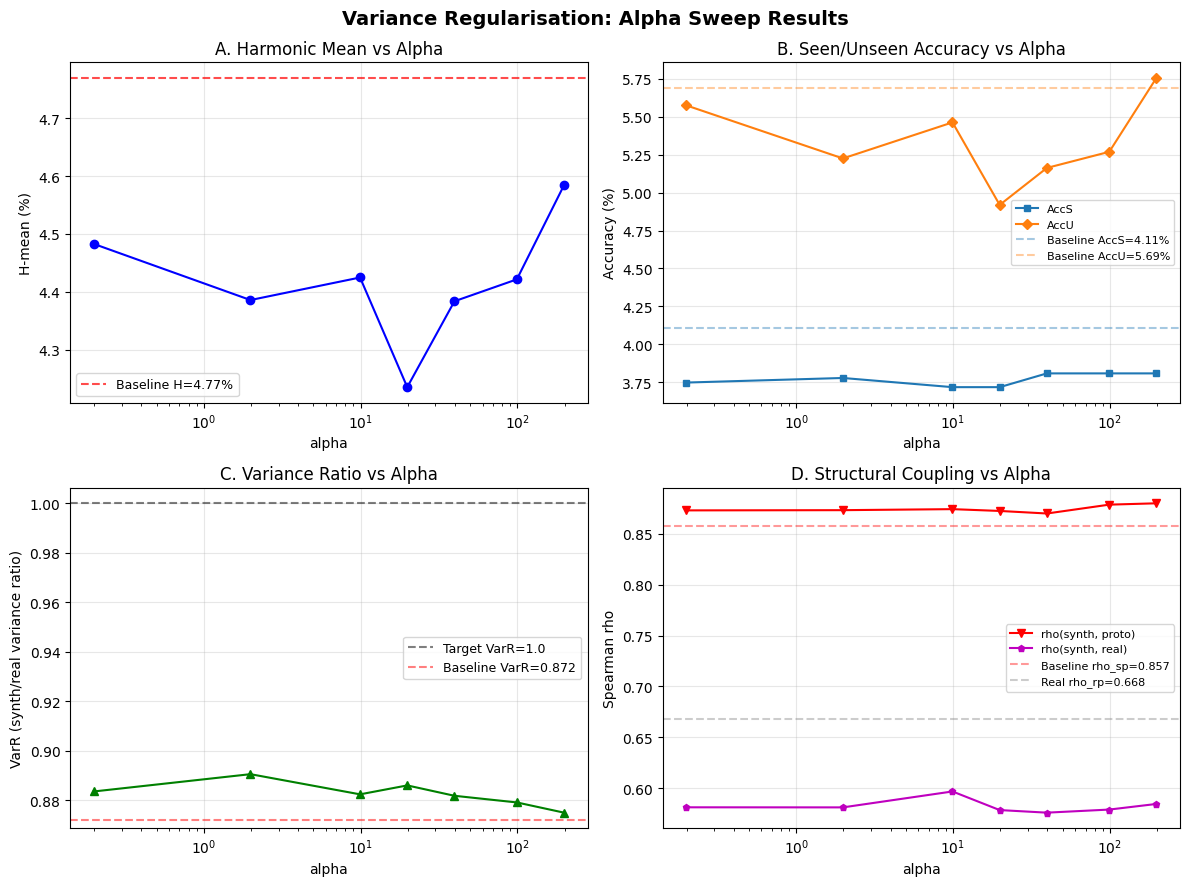

Saved: figures/var_reg_alpha_sweep.png


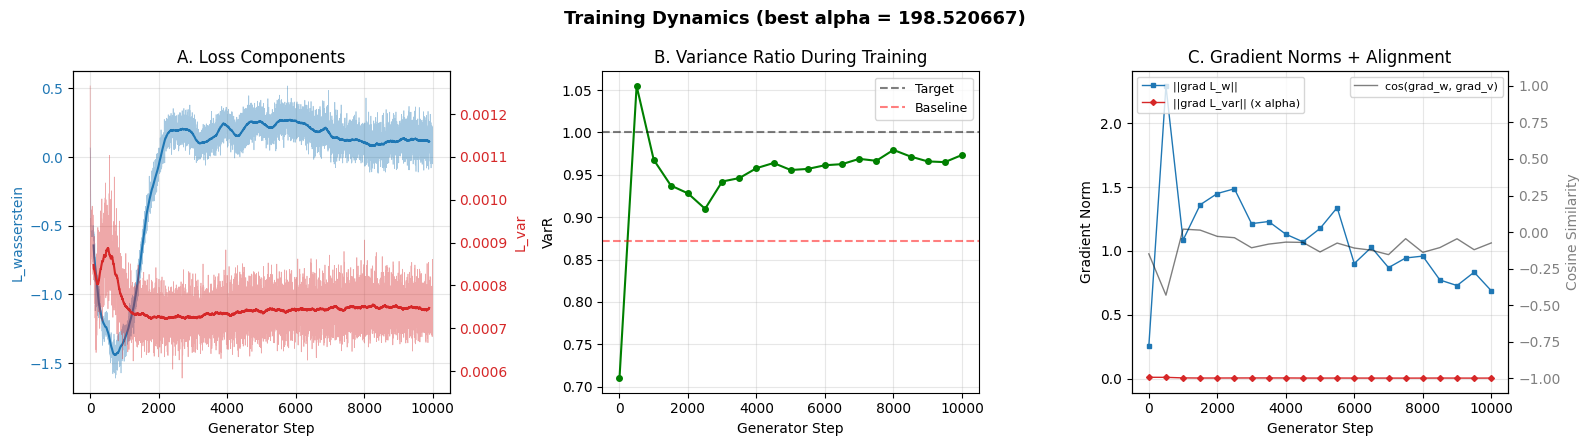

Saved: figures/var_reg_training_dynamics.png

COMPARISON WITH BASELINE
              Metric   Baseline Best alpha      Delta
-------------------------------------------------------
          H-mean (%)       4.77       4.58      -0.19
            AccS (%)       4.11       3.81      -0.30
            AccU (%)       5.69       5.76      +0.07
         Routing (%)       20.0       17.8       -2.2
                VarR      0.872      0.875     +0.003
              rho_sp     0.8572     0.8798    +0.0226
              rho_sr     0.5875     0.5847    -0.0028
              kNN@10      0.611      0.606     -0.005
               alpha        --- 198.520667
          alpha_mult        ---      10.00
-------------------------------------------------------

rho_sp did NOT decrease — L_var addressed variance but not overcoupling.
Next intervention if needed: L_struct (inter-class structure loss).


In [ ]:
# =============================================================================
# ANALYSIS + FIGURES
# =============================================================================

import os
os.makedirs('figures', exist_ok=True)

alphas = [r['alpha'] for r in sweep_results]
mults = [r['alpha_mult'] for r in sweep_results]
Hs = [r['H'] * 100 for r in sweep_results]
AccSs = [r['acc_seen'] * 100 for r in sweep_results]
AccUs = [r['acc_unseen'] * 100 for r in sweep_results]
VarRs = [r['var_ratio'] for r in sweep_results]
rho_sps = [r['rho_synth_proto'] for r in sweep_results]
rho_srs = [r['rho_synth_real'] for r in sweep_results]

# ---- Figure 1: Alpha sweep results (4-panel) ----
fig, axes = plt.subplots(2, 2, figsize=(12, 9))
fig.suptitle('Variance Regularisation: Alpha Sweep Results', fontsize=14, fontweight='bold')

# Panel A: H-mean vs alpha
ax = axes[0, 0]
ax.semilogx(alphas, Hs, 'bo-', markersize=6, linewidth=1.5)
ax.axhline(y=4.77, color='r', linestyle='--', alpha=0.7, label='Baseline H=4.77%')
ax.set_xlabel('alpha')
ax.set_ylabel('H-mean (%)')
ax.set_title('A. Harmonic Mean vs Alpha')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# Panel B: AccS and AccU vs alpha
ax = axes[0, 1]
ax.semilogx(alphas, AccSs, 's-', color='tab:blue', markersize=5, label='AccS', linewidth=1.5)
ax.semilogx(alphas, AccUs, 'D-', color='tab:orange', markersize=5, label='AccU', linewidth=1.5)
ax.axhline(y=4.11, color='tab:blue', linestyle='--', alpha=0.4, label='Baseline AccS=4.11%')
ax.axhline(y=5.69, color='tab:orange', linestyle='--', alpha=0.4, label='Baseline AccU=5.69%')
ax.set_xlabel('alpha')
ax.set_ylabel('Accuracy (%)')
ax.set_title('B. Seen/Unseen Accuracy vs Alpha')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# Panel C: VarR vs alpha
ax = axes[1, 0]
ax.semilogx(alphas, VarRs, 'g^-', markersize=6, linewidth=1.5)
ax.axhline(y=1.0, color='k', linestyle='--', alpha=0.5, label='Target VarR=1.0')
ax.axhline(y=0.872, color='r', linestyle='--', alpha=0.5, label='Baseline VarR=0.872')
ax.set_xlabel('alpha')
ax.set_ylabel('VarR (synth/real variance ratio)')
ax.set_title('C. Variance Ratio vs Alpha')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# Panel D: rho_sp vs alpha
ax = axes[1, 1]
ax.semilogx(alphas, rho_sps, 'rv-', markersize=6, linewidth=1.5, label='rho(synth, proto)')
ax.semilogx(alphas, rho_srs, 'mp-', markersize=5, linewidth=1.5, label='rho(synth, real)')
ax.axhline(y=0.8572, color='r', linestyle='--', alpha=0.4, label='Baseline rho_sp=0.857')
ax.axhline(y=0.668, color='gray', linestyle='--', alpha=0.4, label='Real rho_rp=0.668')
ax.set_xlabel('alpha')
ax.set_ylabel('Spearman rho')
ax.set_title('D. Structural Coupling vs Alpha')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('figures/var_reg_alpha_sweep.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: figures/var_reg_alpha_sweep.png")

# ---- Figure 2: Training dynamics for best alpha (3-panel) ----
best_hist = sweep_histories[best_idx]

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
fig.suptitle(f'Training Dynamics (best alpha = {sweep_results[best_idx]["alpha"]:.6f})',
             fontsize=13, fontweight='bold')

# Panel A: L_wasserstein and L_var over steps
ax1 = axes[0]
steps = np.arange(len(best_hist['L_wasserstein']))
color1 = 'tab:blue'
ax1.plot(steps, best_hist['L_wasserstein'], color=color1, alpha=0.4, linewidth=0.5)
# Smoothed
window = 200
if len(best_hist['L_wasserstein']) > window:
    L_w_smooth = np.convolve(best_hist['L_wasserstein'],
                              np.ones(window)/window, mode='valid')
    ax1.plot(np.arange(len(L_w_smooth)) + window//2, L_w_smooth,
             color=color1, linewidth=1.5, label='L_wasserstein (smoothed)')
ax1.set_xlabel('Generator Step')
ax1.set_ylabel('L_wasserstein', color=color1)
ax1.tick_params(axis='y', labelcolor=color1)

ax2 = ax1.twinx()
color2 = 'tab:red'
ax2.plot(steps, best_hist['L_var'], color=color2, alpha=0.4, linewidth=0.5)
if len(best_hist['L_var']) > window:
    L_v_smooth = np.convolve(best_hist['L_var'],
                              np.ones(window)/window, mode='valid')
    ax2.plot(np.arange(len(L_v_smooth)) + window//2, L_v_smooth,
             color=color2, linewidth=1.5, label='L_var (smoothed)')
ax2.set_ylabel('L_var', color=color2)
ax2.tick_params(axis='y', labelcolor=color2)
ax1.set_title('A. Loss Components')
ax1.grid(True, alpha=0.3)

# Panel B: VarR over steps
ax = axes[1]
mon_steps = best_hist['monitor_steps']
ax.plot(mon_steps, best_hist['VarR'], 'go-', markersize=4, linewidth=1.5)
ax.axhline(y=1.0, color='k', linestyle='--', alpha=0.5, label='Target')
ax.axhline(y=0.872, color='r', linestyle='--', alpha=0.5, label='Baseline')
ax.set_xlabel('Generator Step')
ax.set_ylabel('VarR')
ax.set_title('B. Variance Ratio During Training')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# Panel C: Gradient norms + cosine similarity
ax = axes[2]
ax.plot(mon_steps, best_hist['grad_norm_w'], 's-', color='tab:blue',
        markersize=3, linewidth=1, label='||grad L_w||')
ax.plot(mon_steps, best_hist['grad_norm_v'], 'D-', color='tab:red',
        markersize=3, linewidth=1, label='||grad L_var|| (x alpha)')
ax.set_xlabel('Generator Step')
ax.set_ylabel('Gradient Norm')
ax.legend(loc='upper left', fontsize=8)

ax3 = ax.twinx()
ax3.plot(mon_steps, best_hist['grad_cos_sim'], 'k-', alpha=0.5, linewidth=1,
         label='cos(grad_w, grad_v)')
ax3.set_ylabel('Cosine Similarity', color='gray')
ax3.tick_params(axis='y', labelcolor='gray')
ax3.set_ylim(-1.1, 1.1)
ax3.legend(loc='upper right', fontsize=8)
ax.set_title('C. Gradient Norms + Alignment')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('figures/var_reg_training_dynamics.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: figures/var_reg_training_dynamics.png")

# ---- Summary table ----
print(f"\n{'=' * 60}")
print("COMPARISON WITH BASELINE")
print(f"{'=' * 60}")
print(f"{'Metric':>20s} {'Baseline':>10s} {'Best alpha':>10s} {'Delta':>10s}")
print("-" * 55)
print(f"{'H-mean (%)':>20s} {'4.77':>10s} {best['H']*100:>10.2f} "
      f"{(best['H']-0.0477)*100:>+10.2f}")
print(f"{'AccS (%)':>20s} {'4.11':>10s} {best['acc_seen']*100:>10.2f} "
      f"{(best['acc_seen']-0.0411)*100:>+10.2f}")
print(f"{'AccU (%)':>20s} {'5.69':>10s} {best['acc_unseen']*100:>10.2f} "
      f"{(best['acc_unseen']-0.0569)*100:>+10.2f}")
print(f"{'Routing (%)':>20s} {'20.0':>10s} {best['routing_rate']*100:>10.1f} "
      f"{(best['routing_rate']-0.200)*100:>+10.1f}")
print(f"{'VarR':>20s} {'0.872':>10s} {best['var_ratio']:>10.3f} "
      f"{best['var_ratio']-0.872:>+10.3f}")
print(f"{'rho_sp':>20s} {'0.8572':>10s} {best['rho_synth_proto']:>10.4f} "
      f"{best['rho_synth_proto']-0.8572:>+10.4f}")
print(f"{'rho_sr':>20s} {'0.5875':>10s} {best['rho_synth_real']:>10.4f} "
      f"{best['rho_synth_real']-0.5875:>+10.4f}")
print(f"{'kNN@10':>20s} {'0.611':>10s} {best['knn_10']:>10.3f} "
      f"{best['knn_10']-0.611:>+10.3f}")
print(f"{'alpha':>20s} {'---':>10s} {best['alpha']:>10.6f}")
print(f"{'alpha_mult':>20s} {'---':>10s} {best['alpha_mult']:>10.2f}")
print("-" * 55)

# Concern 1 check: did rho_sp decrease?
if best['rho_synth_proto'] < 0.857:
    print("\nrho_sp DECREASED — L_var indirectly reduced structural overcoupling.")
else:
    print("\nrho_sp did NOT decrease — L_var addressed variance but not overcoupling.")
    print("Next intervention if needed: L_struct (inter-class structure loss).")

In [ ]:
# =============================================================================
# CACHE BEST-ALPHA RESULTS
# =============================================================================

import os
os.makedirs('figures', exist_ok=True)

best_alpha = sweep_results[best_idx]['alpha']
best_mult = sweep_results[best_idx]['alpha_mult']

print(f"Best alpha: {best_alpha:.6f} ({best_mult:.2f}x alpha_0)")
print(f"H-mean: {best['H']*100:.2f}%")
print()

# Retrain best config for caching (or reuse if we stored the generator)
# Since generators were deleted during sweep, retrain the best one
print("Retraining best-alpha WGAN-GP for caching...")
gen_best, hist_best = train_wgan_with_lvar(
    alpha=best_alpha,
    var_target=var_target,
    E_train=E_train_opt,
    y_train=y_train_opt,
    S_seen_protos=S_seen_opt,
    seen_classes=seen_classes_opt,
    wgan_config=OPT_WGAN_CONFIG,
    var_reg_config=VAR_REG_CONFIG,
    device=device,
)

# Generate synthetic embeddings
print("\nGenerating synthetic unseen embeddings...")
E_synth_vareg, y_synth_vareg = synthesise_with_eta(
    generator=gen_best,
    unseen_classes=unseen_classes_opt,
    S_unseen_protos=S_unseen_opt,
    n_synth=OPT_WGAN_CONFIG['n_synth_per_class'],
    z_dim=OPT_WGAN_CONFIG['z_dim'],
    eta=0.0,
    device=device,
)
print(f"E_synth_vareg: {E_synth_vareg.shape}")
print(f"y_synth_vareg: {y_synth_vareg.shape}")

# Cache arrays
np.save('E_synth_vareg.npy', E_synth_vareg)
np.save('y_synth_vareg.npy', y_synth_vareg)
print("\nCached: E_synth_vareg.npy, y_synth_vareg.npy")

# Cache generator state dict
torch.save(gen_best.state_dict(), 'generator_vareg_best.pt')
print("Cached: generator_vareg_best.pt")

# Cache sweep results
import json as json_lib
sweep_results_serialisable = []
for r in sweep_results:
    sr = {k: (float(v) if isinstance(v, (np.floating, float)) else v)
          for k, v in r.items()}
    sweep_results_serialisable.append(sr)

with open('var_reg_sweep_results.json', 'w') as f:
    json_lib.dump({
        'alpha_0': alpha_0,
        'calibration': cal_info,
        'sweep_results': sweep_results_serialisable,
        'best_idx': best_idx,
        'baseline': {
            'H': 0.0477, 'AccS': 0.0411, 'AccU': 0.0569,
            'VarR': 0.872, 'rho_sp': 0.8572, 'rho_sr': 0.5875,
        }
    }, f, indent=2)
print("Cached: var_reg_sweep_results.json")

print(f"\n{'=' * 60}")
print("VARIANCE REGULARISATION EXPERIMENT COMPLETE")
print(f"{'=' * 60}")
print(f"  Best alpha: {best_alpha:.6f} ({best_mult:.2f}x alpha_0)")
print(f"  H-mean:     {best['H']*100:.2f}% (baseline: 4.77%, "
      f"delta: {(best['H']-0.0477)*100:+.2f}pp)")
print(f"  VarR:       {best['var_ratio']:.3f} (baseline: 0.872, "
      f"delta: {best['var_ratio']-0.872:+.3f})")
print(f"  rho_sp:     {best['rho_synth_proto']:.4f} (baseline: 0.8572, "
      f"delta: {best['rho_synth_proto']-0.8572:+.4f})")
print(f"{'=' * 60}")

Best alpha: 198.520667 (10.00x alpha_0)
H-mean: 4.58%

Retraining best-alpha WGAN-GP for caching...
  Step     1/10000: L_w=0.0661, L_var=0.001266, L_D=8.2193, VarR=0.710
  Step  2500/10000: L_w=0.2236, L_var=0.000771, L_D=-0.0255, VarR=0.928
  Step  5000/10000: L_w=0.2074, L_var=0.000720, L_D=-0.0310, VarR=0.964
  Step  7500/10000: L_w=0.0876, L_var=0.000796, L_D=-0.0572, VarR=0.969
  Step 10000/10000: L_w=0.1678, L_var=0.000778, L_D=-0.0694, VarR=0.973
  Training complete in 456s. L_w=0.1678, L_var=0.000778, VarR=0.973

Generating synthetic unseen embeddings...
E_synth_vareg: (4000, 64)
y_synth_vareg: (4000,)

Cached: E_synth_vareg.npy, y_synth_vareg.npy
Cached: generator_vareg_best.pt
Cached: var_reg_sweep_results.json

VARIANCE REGULARISATION EXPERIMENT COMPLETE
  Best alpha: 198.520667 (10.00x alpha_0)
  H-mean:     4.58% (baseline: 4.77%, delta: -0.19pp)
  VarR:       0.875 (baseline: 0.872, delta: +0.003)
  rho_sp:     0.8798 (baseline: 0.8572, delta: +0.0226)
